<a href="https://colab.research.google.com/github/Marilyn-hub/Proyecto-data/blob/main/Predicci%C3%B3n_de_Enfermedades_Card%C3%ADacas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

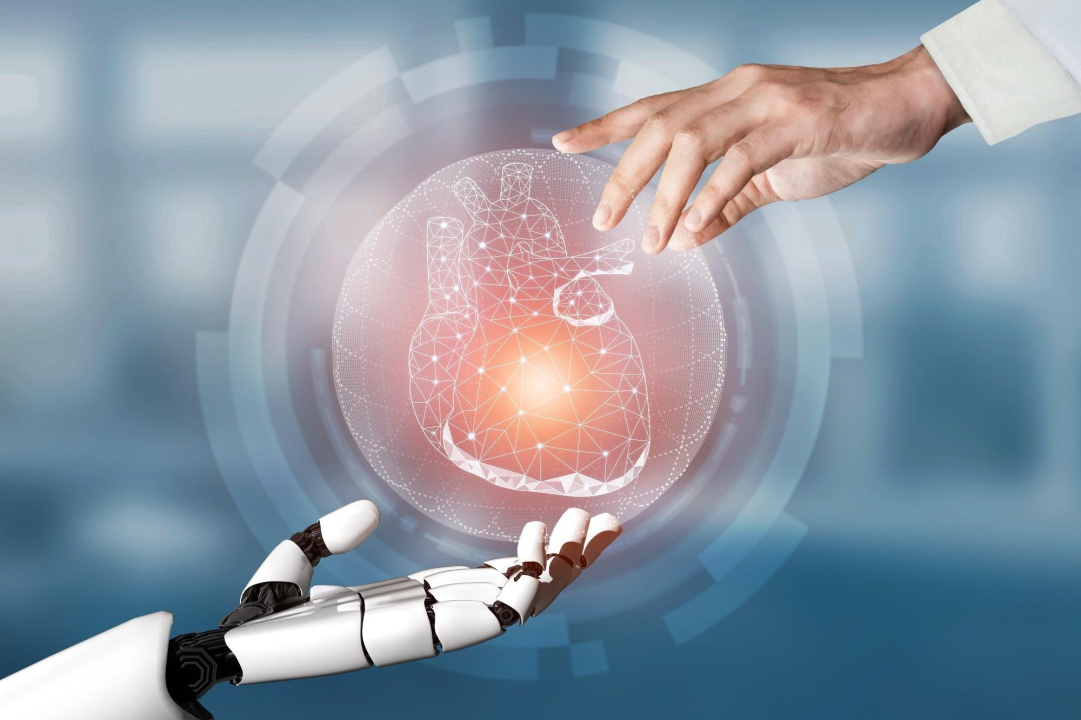

Data Scientist:
 - SUAREZ BONAHORA FLAVIA

# 🤖 Predicción de Enfermedades Cardíacas


###Descripción del Problema

 ### Dominio del Problema

 Las enfermedades cardiovasculares son la principal causa de muerte a nivel mundial, representando aproximadamente el 31% de todas las muertes globales según la OMS. La detección temprana de factores de riesgo cardiovascular es crucial para la prevención y el tratamiento oportuno.


 En este trabajo, asumo en el rol de un científico de datos trabajando para un centro de investigación médica que busca desarrollar un sistema de apoyo a la decisión
 clínica. El objetivo es analizar datos clínicos de pacientes para:

  1. Predecir la presencia de enfermedad cardíaca

 2. Predecir el nivel de colesterol

Contexto


 El hospital cuenta con registros históricos de pacientes que incluyen variables como edad, sexo, tipo de dolor torácico, presión arterial, niveles de colesterol, electrocardiogramas, y el diagnóstico final de presencia o ausencia de enfermedad cardíaca.


 Se aplicará el proceso completo de Knowledge Discovery in Databases (KDD) para extraer conocimiento útil de estos datos y construir modelos predictivos
 que puedan asistir a los profesionales de la salud.

 Objetivos del Trabajo

  1. Aplicar el proceso KDD completo
 2. Implementar y comparar modelos de regresión para predecir valores de colesterol
 3. Implementar y comparar modelos de clasificación para detectar enfermedades cardíacas
 4. Evaluar modelos usando múltiples métricas de calidad
 5. Seleccionar y justificar el mejor modelo para cada tarea

Dataset


 Utilizarás el Heart Disease UCI Dataset, disponible públicamente en:


 - Kaggle:https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset


 - UCIMLRepository: https://archive.ics.uci.edu/ml/datasets/heart+disease

Variables del Dataset

| Variable   | Descripción                                                                 | Tipo       |
|------------|------------------------------------------------------------------------------|------------|
| age        | Edad del paciente                                                           | Numérica   |
| sex        | Sexo (1 = masculino; 0 = femenino)                                           | Categórica |
| cp         | Tipo de dolor torácico (0-3)                                                 | Categórica |
| trestbps   | Presión arterial en reposo (mm Hg)                                           | Numérica   |
| chol       | Colesterol sérico (mg/dl)                                                    | Numérica   |
| fbs        | Azúcar en sangre > 120 mg/dl (1 = verdadero; 0 = falso)                      | Categórica |
| restecg    | Resultados electrocardiográficos en reposo (0-2)                             | Categórica |
| thalach    | Frecuencia cardíaca máxima alcanzada                                         | Numérica   |
| exang      | Angina inducida por ejercicio (1 = sí; 0 = no)                               | Categórica |
| oldpeak    | Depresión del ST inducida por ejercicio                                      | Numérica   |
| slope      | Pendiente del segmento ST de ejercicio máximo                                | Categórica |
| ca         | Número de vasos principales coloreados por fluoroscopia (0-3)               | Numérica   |
| thal       | 1 = normal; 2 = defecto fijo; 3 = defecto reversible                         | Categórica |
| target     | Presencia de enfermedad cardíaca (1 = sí; 0 = no)                            | Categórica |



Estructura del Notebook:

- Título y Descripción
- Importación de Librerías
- Carga de Datos
- Análisis Exploratorio (EDA)
- Preprocesamiento y Transformación
- Modelado de Regresión
- Modelado de Clasificación
- Comparación de Modelos
- Conclusiones
- Formato de Entrega

Recursos Adicionales

- Documentación de Scikit-learn:

 https://scikit-learn.org/

Proceso KDD: Fayyad, U., et al. (1996). "From Data Mining to Knowledge Discovery in Databases"

Métricas de evaluación: https://scikit-learn.org/stable/modules/model_evaluation.html


##Parte 1: Proceso KDD Completo

1.1 Selección de la Fuente de Datos

In [ ]:
# Bloque 1: Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


Cargamos el dataset

In [ ]:
# Bloque 2: Carga del dataset

import pandas as pd

# URL del dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Cargar el dataset directamente desde la URL
df = pd.read_csv(url, header=None)

# Asignar nombres a las columnas
df.columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]


print("✅ Dataset cargado correctamente")

✅ Dataset cargado correctamente


Analisis exploratorio inicial

In [ ]:
# Bloque 3: Análisis exploratorio inicial
print("=== DIMENSIONES DEL DATASET ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

print("\n=== TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== PRIMERAS OBSERVACIONES ===")
print(df.head())

print("\n=== INFORMACIÓN GENERAL ===")
df.info()

print("\n=== ESTADÍSTICAS DESCRIPTIVAS ===")
print(df.describe())

=== DIMENSIONES DEL DATASET ===
Filas: 303, Columnas: 14

=== TIPOS DE DATOS ===
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca           object
thal         object
target        int64
dtype: object

=== PRIMERAS OBSERVACIONES ===
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0 

Documentación de variables para cada tarea

In [ ]:
# Bloque 4: Documentación de variables para cada tarea
print("=== VARIABLES PARA CADA TAREA ===")

print("\n🔹 TAREA DE REGRESIÓN (Predecir colesterol - 'chol')")
print("Variables predictoras:")
regression_features = ['age', 'sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
print(regression_features)
print("Variable objetivo: 'chol'")

print("\n🔹 TAREA DE CLASIFICACIÓN (Predecir enfermedad cardíaca - 'target')")
print("Variables predictoras:")
classification_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
print(classification_features)
print("Variable objetivo: 'target'")

=== VARIABLES PARA CADA TAREA ===

🔹 TAREA DE REGRESIÓN (Predecir colesterol - 'chol')
Variables predictoras:
['age', 'sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Variable objetivo: 'chol'

🔹 TAREA DE CLASIFICACIÓN (Predecir enfermedad cardíaca - 'target')
Variables predictoras:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Variable objetivo: 'target'


Verificamos las columnas reales del dataset

In [ ]:
# Bloque 4.1: Verificar las columnas reales del dataset
print("=== COLUMNAS REALES DEL DATASET ===")
print("Columnas disponibles:")
print(df.columns.tolist())

print("\n=== PRIMERAS FILAS DEL DATASET ===")
print(df.head())

print("\n=== INFORMACIÓN DETALLADA ===")
print(df.info())

=== COLUMNAS REALES DEL DATASET ===
Columnas disponibles:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

=== PRIMERAS FILAS DEL DATASET ===
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca thal  target  
0    3.0  0.0  6.0       0  
1    2.0  3.0  3.0       2  
2    2.0  2.0  7.0       1  
3    3.0  0.0  3.0       0  
4    1.0  0.0  3.0       0  

=== INFORMACIÓN DETALLADA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Colum

Identificamos la variable objetivo

In [ ]:
# Bloque 4.2: Identificar la variable objetivo automáticamente
print("=== IDENTIFICANDO VARIABLE OBJETIVO ===")

# Posibles nombres para la variable objetivo (enfermedad cardíaca)
possible_target_names = ['target', 'disease', 'heart_disease', 'class', 'diagnosis', 'condition', 'num']

target_column = None
for possible_name in possible_target_names:
    if possible_name in df.columns:
        target_column = possible_name
        break

if target_column:
    print(f"✅ Variable objetivo identificada: '{target_column}'")
    # Renombrar a 'target' para consistencia
    if target_column != 'target':
        df = df.rename(columns={target_column: 'target'})
        print(f"✅ Columna renombrada de '{target_column}' a 'target'")
else:
    # Si no encontramos, usar la última columna (común en datasets UCI)
    target_column = df.columns[-1]
    df = df.rename(columns={target_column: 'target'})
    print(f"⚠️  Usando la última columna como objetivo: '{target_column}' renombrada a 'target'")

print(f"\nValores únicos en 'target': {sorted(df['target'].unique())}")

=== IDENTIFICANDO VARIABLE OBJETIVO ===
✅ Variable objetivo identificada: 'target'

Valores únicos en 'target': [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


Verificamos y mapeamos los valores de target

In [ ]:
# Bloque 4.3: Verificar y mapear valores de target si es necesario
print("=== VERIFICANDO VALORES DE TARGET ===")

# Ver los valores actuales
target_values = df['target'].value_counts().sort_index()
print("Distribución actual de target:")
print(target_values)

# En algunos datasets, 0 = sin enfermedad, 1-4 = con enfermedad (diferentes niveles)
# Normalizamos a: 0 = sin enfermedad, 1 = con enfermedad
if set(df['target'].unique()) != {0, 1}:
    print("\n⚠️  Valores de target diferentes de {0, 1}. Normalizando...")

    # Estrategia común: 0 = sin enfermedad, >0 = con enfermedad
    df['target_original'] = df['target'].copy()  # Guardar valores originales

    # Convertir a binario: 0 si es 0, 1 si es >0
    df['target'] = (df['target'] > 0).astype(int)

    print("✅ Target normalizado a valores binarios:")
    print(f"Valores originales: {sorted(df['target_original'].unique())}")
    print(f"Valores normalizados: {sorted(df['target'].unique())}")

print("\nDistribución final de target:")
print(df['target'].value_counts().sort_index())

=== VERIFICANDO VALORES DE TARGET ===
Distribución actual de target:
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

⚠️  Valores de target diferentes de {0, 1}. Normalizando...
✅ Target normalizado a valores binarios:
Valores originales: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Valores normalizados: [np.int64(0), np.int64(1)]

Distribución final de target:
target
0    164
1    139
Name: count, dtype: int64


Documentación de variables actualizada

In [ ]:
# Bloque 4.4: Documentación de variables actualizada
print("=== VARIABLES PARA CADA TAREA ===")

# Verificar que todas las variables existen
available_columns = df.columns.tolist()
print(f"Columnas disponibles: {available_columns}")

# Definir variables basadas en lo que realmente existe
regression_features = [col for col in ['age', 'sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'] if col in df.columns and col != 'chol']
classification_features = [col for col in ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal'] if col in df.columns and col != 'target']

print("\n🔹 TAREA DE REGRESIÓN (Predecir colesterol - 'chol')")
print("Variables predictoras:", regression_features)
print("Variable objetivo: 'chol'")

print("\n🔹 TAREA DE CLASIFICACIÓN (Predecir enfermedad cardíaca - 'target')")
print("Variables predictoras:", classification_features)
print("Variable objetivo: 'target'")

=== VARIABLES PARA CADA TAREA ===
Columnas disponibles: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target', 'target_original']

🔹 TAREA DE REGRESIÓN (Predecir colesterol - 'chol')
Variables predictoras: ['age', 'sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Variable objetivo: 'chol'

🔹 TAREA DE CLASIFICACIÓN (Predecir enfermedad cardíaca - 'target')
Variables predictoras: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Variable objetivo: 'target'


1.2 Preprocesamiento - Limpieza

- Manejo de valores faltantes

In [ ]:
# Bloque 5: Manejo de valores faltantes
print("=== VALORES FALTANTES ===")
print(df.isnull().sum())

# Si hay valores faltantes, podemos manejarlos así:
if df.isnull().sum().any():
    # Para variables numéricas
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

    # Para variables categóricas
    categorical_cols = df.select_dtypes(include=['object']).columns
    df[categorical_cols] = df[categorical_cols].fillna(df[categorical_cols].mode().iloc[0])

    print("✅ Valores faltantes manejados")
else:
    print("✅ No hay valores faltantes")

=== VALORES FALTANTES ===
age                0
sex                0
cp                 0
trestbps           0
chol               0
fbs                0
restecg            0
thalach            0
exang              0
oldpeak            0
slope              0
ca                 0
thal               0
target             0
target_original    0
dtype: int64
✅ No hay valores faltantes


 Manejo específico de valores '?' en el dataset

In [ ]:
# Bloque 5.1: Manejo específico de valores '?' en el dataset
print("=== MANEJO DE VALORES '?' (FALTANTES) ===")

# Primero, identificar qué columnas tienen valores '?'
print("Buscando valores '?' en el dataset...")
columns_with_questions = []
for column in df.columns:
    if df[column].dtype == 'object':  # Solo buscar en columnas de tipo objeto
        has_questions = (df[column] == '?').any()
        if has_questions:
            columns_with_questions.append(column)
            question_count = (df[column] == '?').sum()
            print(f"Columna '{column}': {question_count} valores '?'")

if not columns_with_questions:
    print("✅ No se encontraron valores '?' en el dataset")
else:
    print(f"\n🔄 Procesando {len(columns_with_questions)} columnas con valores '?'")

=== MANEJO DE VALORES '?' (FALTANTES) ===
Buscando valores '?' en el dataset...
Columna 'ca': 4 valores '?'
Columna 'thal': 2 valores '?'

🔄 Procesando 2 columnas con valores '?'


Convertir columnas numéricas y manejar valores '?'

In [ ]:
# Bloque 5.2: Convertir columnas numéricas y manejar valores '?'
print("=== CONVERSIÓN DE TIPOS DE DATOS ===")

# Definir qué columnas deberían ser numéricas basado en la descripción del dataset
numeric_columns = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

# Crear una copia para trabajar
df_clean = df.copy()

# Convertir columnas que deberían ser numéricas
for col in numeric_columns:
    if col in df_clean.columns:
        print(f"Convirtiendo columna '{col}' a numérica...")
        # Reemplazar '?' por NaN y luego convertir a numérico
        df_clean[col] = pd.to_numeric(df_clean[col].replace('?', np.nan), errors='coerce')

        # Mostrar estadísticas después de la conversión
        missing_count = df_clean[col].isna().sum()
        if missing_count > 0:
            print(f"  - {missing_count} valores faltantes después de la conversión")

print("\n✅ Conversión de tipos de datos completada")

=== CONVERSIÓN DE TIPOS DE DATOS ===
Convirtiendo columna 'age' a numérica...
Convirtiendo columna 'trestbps' a numérica...
Convirtiendo columna 'chol' a numérica...
Convirtiendo columna 'thalach' a numérica...
Convirtiendo columna 'oldpeak' a numérica...
Convirtiendo columna 'ca' a numérica...
  - 4 valores faltantes después de la conversión

✅ Conversión de tipos de datos completada


Manejo especifico de columnas problematicas

In [ ]:
# Bloque 5.3 CORREGIDO: Manejo específico de columnas 'ca' y 'thal'
print("=== MANEJO ESPECÍFICO DE COLUMNAS PROBLEMÁTICAS ===")

# Crear una copia para trabajar
df_clean = df.copy()

# Manejar columna 'ca' - tiene valores '?'
print("Procesando columna 'ca'...")
print(f"Valores únicos en 'ca' antes: {df_clean['ca'].unique()}")

# Reemplazar '?' por NaN y luego convertir a numérico
df_clean['ca'] = pd.to_numeric(df_clean['ca'].replace('?', np.nan), errors='coerce')

# Imputar con la mediana (ya que es numérica)
ca_median = df_clean['ca'].median()
df_clean['ca'].fillna(ca_median, inplace=True)
df_clean['ca'] = df_clean['ca'].astype(int)  # Convertir a entero

print(f"Valores únicos en 'ca' después: {sorted(df_clean['ca'].unique())}")

# Manejar columna 'thal' - tiene valores '?'
print("\nProcesando columna 'thal'...")
print(f"Valores únicos en 'thal' antes: {df_clean['thal'].unique()}")

# Reemplazar '?' por NaN y luego convertir a numérico
df_clean['thal'] = pd.to_numeric(df_clean['thal'].replace('?', np.nan), errors='coerce')

# Imputar con la moda (ya que es categórica)
thal_mode = df_clean['thal'].mode()[0]
df_clean['thal'].fillna(thal_mode, inplace=True)
df_clean['thal'] = df_clean['thal'].astype(int)  # Convertir a entero

print(f"Valores únicos en 'thal' después: {sorted(df_clean['thal'].unique())}")

print("\n✅ Columnas problemáticas procesadas correctamente")

=== MANEJO ESPECÍFICO DE COLUMNAS PROBLEMÁTICAS ===
Procesando columna 'ca'...
Valores únicos en 'ca' antes: ['0.0' '3.0' '2.0' '1.0' '?']
Valores únicos en 'ca' después: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]

Procesando columna 'thal'...
Valores únicos en 'thal' antes: ['6.0' '3.0' '7.0' '?']
Valores únicos en 'thal' después: [np.int64(3), np.int64(6), np.int64(7)]

✅ Columnas problemáticas procesadas correctamente


Verificamos una vez más los tipos de datos

In [ ]:
# Bloque 5.4 CORREGIDO: Verificación final sin conversión forzada
print("=== VERIFICACIÓN FINAL DE TIPOS DE DATOS ===")

# Solo necesitamos asegurar que las columnas categóricas sean enteras
# Pero ya las convertimos en el paso anterior, así que solo verificamos
categorical_columns = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

print("Tipos de datos finales:")
for col in df_clean.columns:
    print(f"  - {col}: {df_clean[col].dtype}")

print("\nValores únicos por columna categórica:")
for col in categorical_columns:
    if col in df_clean.columns:
        print(f"  - {col}: {sorted(df_clean[col].unique())}")

print("\nEstadísticas descriptivas:")
print(df_clean.describe())

# Verificar que no hay valores faltantes
print(f"\nValores faltantes totales: {df_clean.isnull().sum().sum()}")

# Reemplazar el dataframe original con el limpio
df = df_clean
print("\n✅ Dataset completamente limpio y listo para análisis")

=== VERIFICACIÓN FINAL DE TIPOS DE DATOS ===
Tipos de datos finales:
  - age: float64
  - sex: float64
  - cp: float64
  - trestbps: float64
  - chol: float64
  - fbs: float64
  - restecg: float64
  - thalach: float64
  - exang: float64
  - oldpeak: float64
  - slope: float64
  - ca: int64
  - thal: int64
  - target: int64
  - target_original: int64

Valores únicos por columna categórica:
  - sex: [np.float64(0.0), np.float64(1.0)]
  - cp: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
  - fbs: [np.float64(0.0), np.float64(1.0)]
  - restecg: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
  - exang: [np.float64(0.0), np.float64(1.0)]
  - slope: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  - thal: [np.int64(3), np.int64(6), np.int64(7)]
  - target: [np.int64(0), np.int64(1)]

Estadísticas descriptivas:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.

Verificación de duplicados

In [ ]:
# Bloque 6: Verificación de duplicados
print("=== DUPLICADOS ===")
duplicados = df.duplicated().sum()
print(f"Número de duplicados: {duplicados}")

if duplicados > 0:
    df = df.drop_duplicates()
    print("✅ Duplicados eliminados")
else:
    print("✅ No hay duplicados")

=== DUPLICADOS ===
Número de duplicados: 0
✅ No hay duplicados


Análisis de balanceo de clases para clasificación

=== BALANCEO DE CLASES (Target) ===
Distribución de clases:
target
0    164
1    139
Name: count, dtype: int64


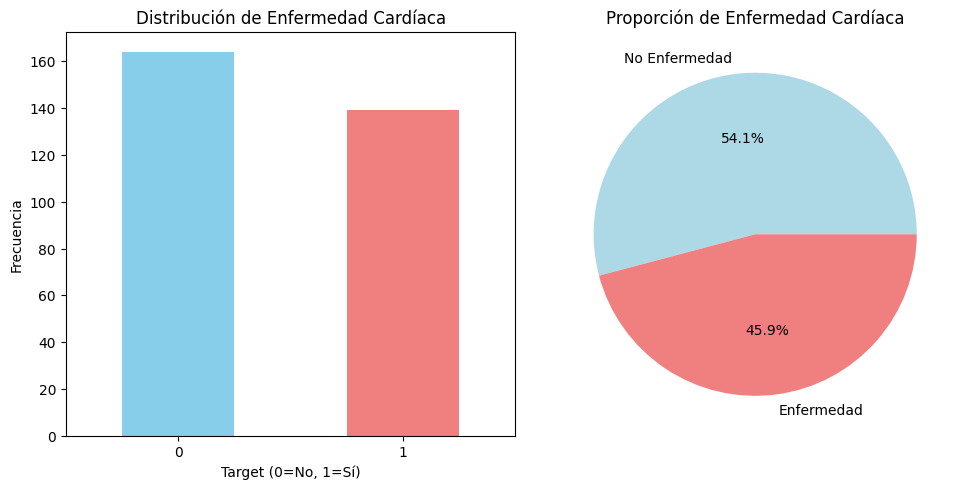


Proporción Clase 0 (No enfermedad): 0.541
Proporción Clase 1 (Enfermedad): 0.459
✅ El dataset está razonablemente balanceado


In [ ]:
# Bloque 7 CORREGIDO: Análisis de balanceo de clases para clasificación
print("=== BALANCEO DE CLASES (Target) ===")

# Verificar que 'target' existe
if 'target' not in df.columns:
    print("❌ Error: Columna 'target' no encontrada después de la búsqueda")
    print("Columnas disponibles:", df.columns.tolist())
else:
    class_distribution = df['target'].value_counts()
    print("Distribución de clases:")
    print(class_distribution)

    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    class_distribution.plot(kind='bar', color=['skyblue', 'lightcoral'])
    plt.title('Distribución de Enfermedad Cardíaca')
    plt.xlabel('Target (0=No, 1=Sí)')
    plt.ylabel('Frecuencia')
    plt.xticks(rotation=0)

    plt.subplot(1, 2, 2)
    labels = ['No Enfermedad', 'Enfermedad'] if len(class_distribution) == 2 else ['Clase 0', 'Clase 1']
    plt.pie(class_distribution, labels=labels, autopct='%1.1f%%', colors=['lightblue', 'lightcoral'])
    plt.title('Proporción de Enfermedad Cardíaca')

    plt.tight_layout()
    plt.show()

    # Verificar si está balanceado
    total = len(df)
    prop_clase_0 = class_distribution.iloc[0] / total if 0 in class_distribution.index else 0
    prop_clase_1 = class_distribution.iloc[1] / total if 1 in class_distribution.index else class_distribution.iloc[0] / total

    print(f"\nProporción Clase 0 (No enfermedad): {prop_clase_0:.3f}")
    print(f"Proporción Clase 1 (Enfermedad): {prop_clase_1:.3f}")

    if abs(prop_clase_0 - prop_clase_1) < 0.2:
        print("✅ El dataset está razonablemente balanceado")
    else:
        print("⚠️ El dataset podría estar desbalanceado")

1.3 Transformación

- Codificacion de variables categóricas

In [ ]:
# Bloque 8: Codificación de variables categóricas
print("=== VARIABLES CATEGÓRICAS ===")
categorical_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']

print("Valores únicos por variable categórica:")
for var in categorical_vars:
    if var in df.columns:
        print(f"{var}: {sorted(df[var].unique())}")

# Para la tarea de clasificación, target ya está codificado (0,1)
# Para la tarea de regresión, las variables predictoras categóricas ya están codificadas

print("\n✅ Variables categóricas ya están codificadas apropiadamente")

=== VARIABLES CATEGÓRICAS ===
Valores únicos por variable categórica:
sex: [np.float64(0.0), np.float64(1.0)]
cp: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)]
fbs: [np.float64(0.0), np.float64(1.0)]
restecg: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
exang: [np.float64(0.0), np.float64(1.0)]
slope: [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
thal: [np.int64(3), np.int64(6), np.int64(7)]
target: [np.int64(0), np.int64(1)]

✅ Variables categóricas ya están codificadas apropiadamente


Normalizacion/Estandarizacion

In [ ]:
# Bloque 9: Normalización/Estandarización
print("=== NORMALIZACIÓN DE VARIABLES NUMÉRICAS ===")

# Identificar variables numéricas para normalizar
numeric_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
print(f"Variables numéricas a normalizar: {numeric_vars}")

# Crear copias para diferentes tareas
df_regression = df.copy()  # Para regresión
df_classification = df.copy()  # Para clasificación

# Estandarizar variables numéricas para regresión
scaler_reg = StandardScaler()
df_regression[numeric_vars] = scaler_reg.fit_transform(df_regression[numeric_vars])

# Estandarizar variables numéricas para clasificación (excluyendo target)
scaler_clf = StandardScaler()
classification_numeric_vars = [var for var in numeric_vars if var != 'chol']
df_classification[classification_numeric_vars] = scaler_clf.fit_transform(df_classification[classification_numeric_vars])

print("✅ Variables numéricas normalizadas para ambas tareas")
print("\nEstadísticas después de normalización (Regresión):")
print(df_regression[numeric_vars].describe())

=== NORMALIZACIÓN DE VARIABLES NUMÉRICAS ===
Variables numéricas a normalizar: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
✅ Variables numéricas normalizadas para ambas tareas

Estadísticas después de normalización (Regresión):
                age      trestbps          chol       thalach       oldpeak
count  3.030000e+02  3.030000e+02  3.030000e+02  3.030000e+02  3.030000e+02
mean  -1.465641e-18  4.426236e-16  2.345026e-16 -1.172513e-16  2.345026e-17
std    1.001654e+00  1.001654e+00  1.001654e+00  1.001654e+00  1.001654e+00
min   -2.819115e+00 -2.145037e+00 -2.334877e+00 -3.442067e+00 -8.968617e-01
25%   -7.135564e-01 -6.652997e-01 -6.905030e-01 -7.053073e-01 -8.968617e-01
50%    1.729945e-01 -9.616980e-02 -1.101357e-01  1.485618e-01 -2.067053e-01
75%    7.270888e-01  4.729601e-01  5.476139e-01  7.178079e-01  4.834512e-01
max    2.500191e+00  3.887739e+00  6.138485e+00  2.294182e+00  4.451851e+00


Análisis de correlación con dataset limpio

=== MATRIZ DE CORRELACIÓN ===
🔹 CORRELACIONES CON COLESTEROL:
  chol: 1.000
  age: 0.209
  restecg: 0.171
  trestbps: 0.130
  ca: 0.124
  target: 0.085
  cp: 0.072
  target_original: 0.071
  exang: 0.061
  oldpeak: 0.047
  thal: 0.018
  fbs: 0.010
  thalach: -0.003
  slope: -0.004
  sex: -0.200

🔹 CORRELACIONES CON ENFERMEDAD CARDÍACA:
  target: 1.000
  target_original: 0.830
  thal: 0.522
  ca: 0.460
  exang: 0.432
  oldpeak: 0.425
  cp: 0.414
  slope: 0.339
  sex: 0.277
  age: 0.223
  restecg: 0.169
  trestbps: 0.151
  chol: 0.085
  fbs: 0.025
  thalach: -0.417


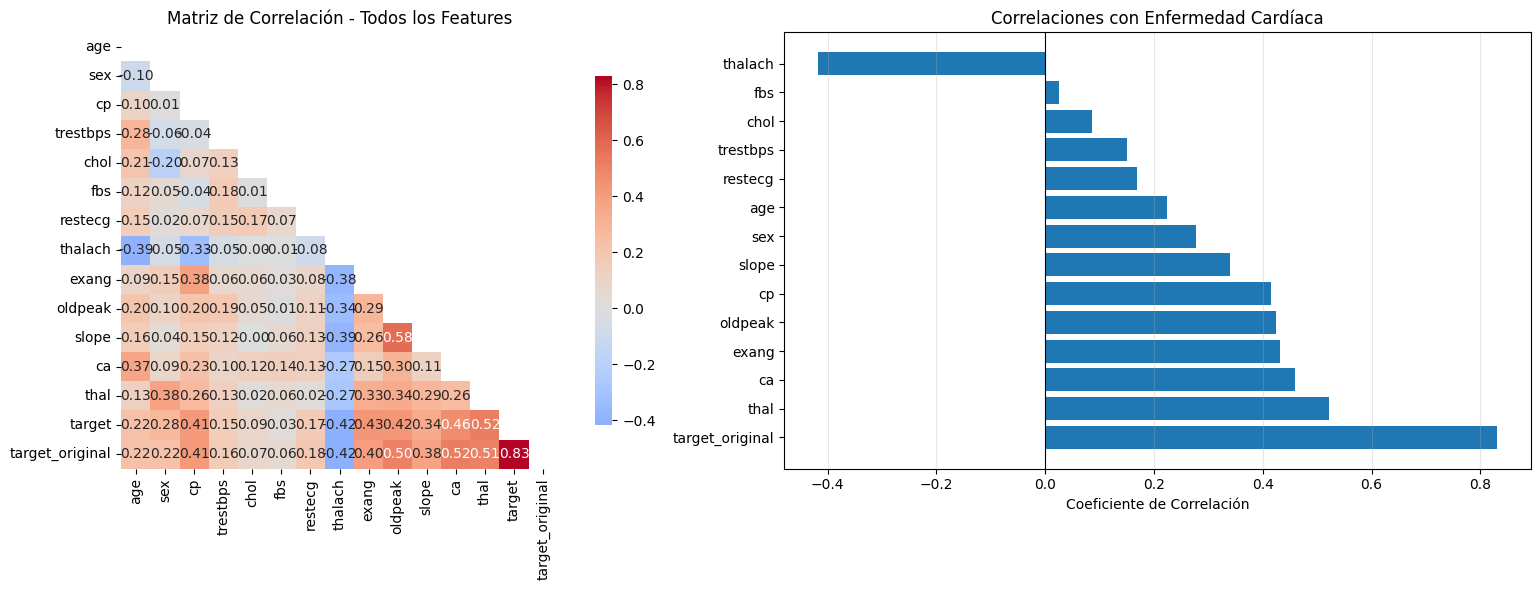

In [ ]:
# Bloque 10 CORREGIDO: Análisis de correlación (con dataset limpio)
print("=== MATRIZ DE CORRELACIÓN ===")

plt.figure(figsize=(16, 6))

# Calcular correlación con todas las columnas numéricas
correlation_matrix = df.corr()

# Para regresión (correlación con colesterol)
if 'chol' in df.columns:
    plt.subplot(1, 2, 1)

    chol_correlations = correlation_matrix['chol'].sort_values(ascending=False)
    print("🔹 CORRELACIONES CON COLESTEROL:")
    for var, corr in chol_correlations.items():
        print(f"  {var}: {corr:.3f}")

    # Crear heatmap
    mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
    sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
               fmt='.2f', center=0, square=True, cbar_kws={"shrink": .8})
    plt.title('Matriz de Correlación - Todos los Features')
    plt.tight_layout()

# Para clasificación (correlación con target)
if 'target' in df.columns:
    plt.subplot(1, 2, 2)

    target_correlations = correlation_matrix['target'].sort_values(ascending=False)
    print("\n🔹 CORRELACIONES CON ENFERMEDAD CARDÍACA:")
    for var, corr in target_correlations.items():
        print(f"  {var}: {corr:.3f}")

    # Crear heatmap específico para target
    target_corr_series = correlation_matrix['target'].drop('target')
    target_corr_sorted = target_corr_series.sort_values(ascending=False)

    plt.barh(range(len(target_corr_sorted)), target_corr_sorted.values)
    plt.yticks(range(len(target_corr_sorted)), target_corr_sorted.index)
    plt.xlabel('Coeficiente de Correlación')
    plt.title('Correlaciones con Enfermedad Cardíaca')
    plt.grid(axis='x', alpha=0.3)
    plt.axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

Analisis detallado de correlaciones

In [ ]:
# Bloque 10.1 CORREGIDO: Análisis detallado de correlaciones
print("=== ANÁLISIS DETALLADO DE CORRELACIONES ===")

if 'chol' in correlation_matrix.columns:
    print("\n🔹 TOP CORRELACIONES CON COLESTEROL:")
    chol_correlations_abs = correlation_matrix['chol'].abs().sort_values(ascending=False)
    # Convertir a lista para poder hacer slicing
    chol_items = list(chol_correlations_abs.items())[:8]
    for i, (var, corr_abs) in enumerate(chol_items, 1):
        if var != 'chol':  # Excluir correlación consigo mismo
            corr_actual = correlation_matrix.loc[var, 'chol']
            direction = "positiva" if corr_actual > 0 else "negativa"
            print(f"  {i}. {var}: {corr_actual:.3f} ({direction})")

if 'target' in correlation_matrix.columns:
    print("\n🔹 TOP CORRELACIONES CON ENFERMEDAD CARDÍACA:")
    target_correlations_abs = correlation_matrix['target'].abs().sort_values(ascending=False)
    # Convertir a lista para poder hacer slicing
    target_items = list(target_correlations_abs.items())[:8]
    for i, (var, corr_abs) in enumerate(target_items, 1):
        if var != 'target':  # Excluir correlación consigo mismo
            corr_actual = correlation_matrix.loc[var, 'target']
            direction = "positiva" if corr_actual > 0 else "negativa"
            print(f"  {i}. {var}: {corr_actual:.3f} ({direction})")

=== ANÁLISIS DETALLADO DE CORRELACIONES ===

🔹 TOP CORRELACIONES CON COLESTEROL:
  2. age: 0.209 (positiva)
  3. sex: -0.200 (negativa)
  4. restecg: 0.171 (positiva)
  5. trestbps: 0.130 (positiva)
  6. ca: 0.124 (positiva)
  7. target: 0.085 (positiva)
  8. cp: 0.072 (positiva)

🔹 TOP CORRELACIONES CON ENFERMEDAD CARDÍACA:
  2. target_original: 0.830 (positiva)
  3. thal: 0.522 (positiva)
  4. ca: 0.460 (positiva)
  5. exang: 0.432 (positiva)
  6. oldpeak: 0.425 (positiva)
  7. thalach: -0.417 (negativa)
  8. cp: 0.414 (positiva)


Visualizamos las relaciones clave

=== VISUALIZACIÓN DE RELACIONES CLAVE ===


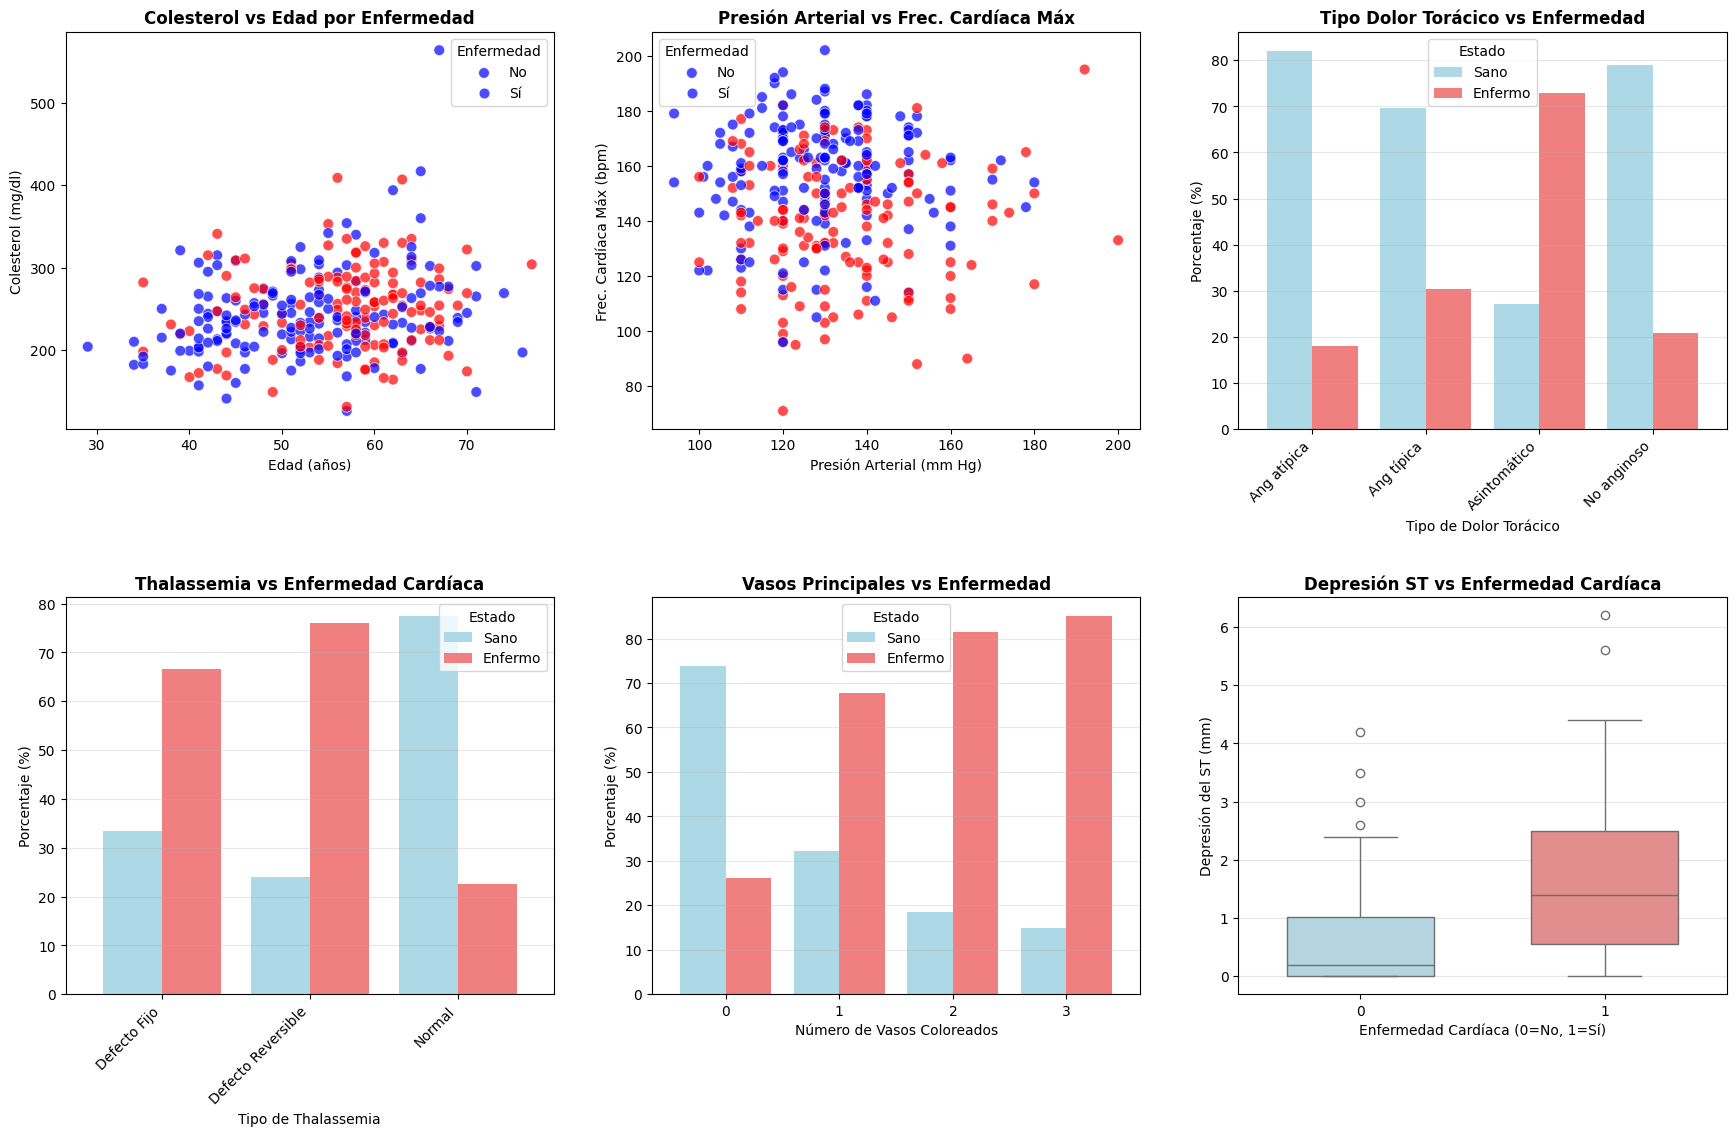

In [ ]:
# Bloque 10.2 CORREGIDO: Visualización de relaciones clave (ERROR SOLUCIONADO)
print("=== VISUALIZACIÓN DE RELACIONES CLAVE ===")

# Crear figuras separadas para mejor organización
plt.figure(figsize=(18, 12))

# Relación 1: Colesterol vs Edad por enfermedad cardíaca
plt.subplot(2, 3, 1)
# Convertir target a string para el mapeo de colores
df_temp = df.copy()
df_temp['target_str'] = df_temp['target'].astype(str)
scatter1 = sns.scatterplot(data=df_temp, x='age', y='chol', hue='target_str',
                          palette={'0': 'blue', '1': 'red'}, alpha=0.7, s=60)
plt.title('Colesterol vs Edad por Enfermedad', fontsize=12, fontweight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Colesterol (mg/dl)')
plt.legend(title='Enfermedad', labels=['No', 'Sí'])

# Relación 2: Presión arterial vs Frecuencia cardíaca
plt.subplot(2, 3, 2)
scatter2 = sns.scatterplot(data=df_temp, x='trestbps', y='thalach', hue='target_str',
                          palette={'0': 'blue', '1': 'red'}, alpha=0.7, s=60)
plt.title('Presión Arterial vs Frec. Cardíaca Máx', fontsize=12, fontweight='bold')
plt.xlabel('Presión Arterial (mm Hg)')
plt.ylabel('Frec. Cardíaca Máx (bpm)')
plt.legend(title='Enfermedad', labels=['No', 'Sí'])

# Relación 3: Tipo de dolor torácico vs Enfermedad
plt.subplot(2, 3, 3)
cp_mapping = {1.0: 'Ang típica', 2.0: 'Ang atípica', 3.0: 'No anginoso', 4.0: 'Asintomático'}
df_cp = df.copy()
df_cp['cp_label'] = df_cp['cp'].map(cp_mapping)
cp_target = pd.crosstab(df_cp['cp_label'], df_cp['target'])
cp_target_percentage = cp_target.div(cp_target.sum(axis=1), axis=0) * 100

bars = cp_target_percentage.plot(kind='bar', color=['lightblue', 'lightcoral'],
                                ax=plt.gca(), width=0.8)
plt.title('Tipo Dolor Torácico vs Enfermedad', fontsize=12, fontweight='bold')
plt.xlabel('Tipo de Dolor Torácico')
plt.ylabel('Porcentaje (%)')
plt.legend(['Sano', 'Enfermo'], title='Estado')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Relación 4: Thalassemia vs Enfermedad
plt.subplot(2, 3, 4)
thal_mapping = {3: 'Normal', 6: 'Defecto Fijo', 7: 'Defecto Reversible'}
df_thal = df.copy()
df_thal['thal_label'] = df_thal['thal'].map(thal_mapping)
thal_target = pd.crosstab(df_thal['thal_label'], df_thal['target'])
thal_target_percentage = thal_target.div(thal_target.sum(axis=1), axis=0) * 100

thal_target_percentage.plot(kind='bar', color=['lightblue', 'lightcoral'],
                           ax=plt.gca(), width=0.8)
plt.title('Thalassemia vs Enfermedad Cardíaca', fontsize=12, fontweight='bold')
plt.xlabel('Tipo de Thalassemia')
plt.ylabel('Porcentaje (%)')
plt.legend(['Sano', 'Enfermo'], title='Estado')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Relación 5: Vasos principales coloreados vs Enfermedad
plt.subplot(2, 3, 5)
ca_target = pd.crosstab(df['ca'], df['target'])
ca_target_percentage = ca_target.div(ca_target.sum(axis=1), axis=0) * 100

ca_target_percentage.plot(kind='bar', color=['lightblue', 'lightcoral'],
                         ax=plt.gca(), width=0.8)
plt.title('Vasos Principales vs Enfermedad', fontsize=12, fontweight='bold')
plt.xlabel('Número de Vasos Coloreados')
plt.ylabel('Porcentaje (%)')
plt.legend(['Sano', 'Enfermo'], title='Estado')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Relación 6: Depresión ST vs Enfermedad - CORREGIDO
plt.subplot(2, 3, 6)
# Usar target como string para el palette
boxplot = sns.boxplot(data=df_temp, x='target_str', y='oldpeak',
                     palette={'0': 'lightblue', '1': 'lightcoral'}, width=0.6)
plt.title('Depresión ST vs Enfermedad Cardíaca', fontsize=12, fontweight='bold')
plt.xlabel('Enfermedad Cardíaca (0=No, 1=Sí)')
plt.ylabel('Depresión del ST (mm)')
plt.grid(axis='y', alpha=0.3)

# Ajustar layout
plt.tight_layout(pad=3.0)
plt.show()

# Limpiar variable temporal
del df_temp

Visualizaciones adicionales para thalach

=== VISUALIZACIONES ESPECIALES PARA thalach ===


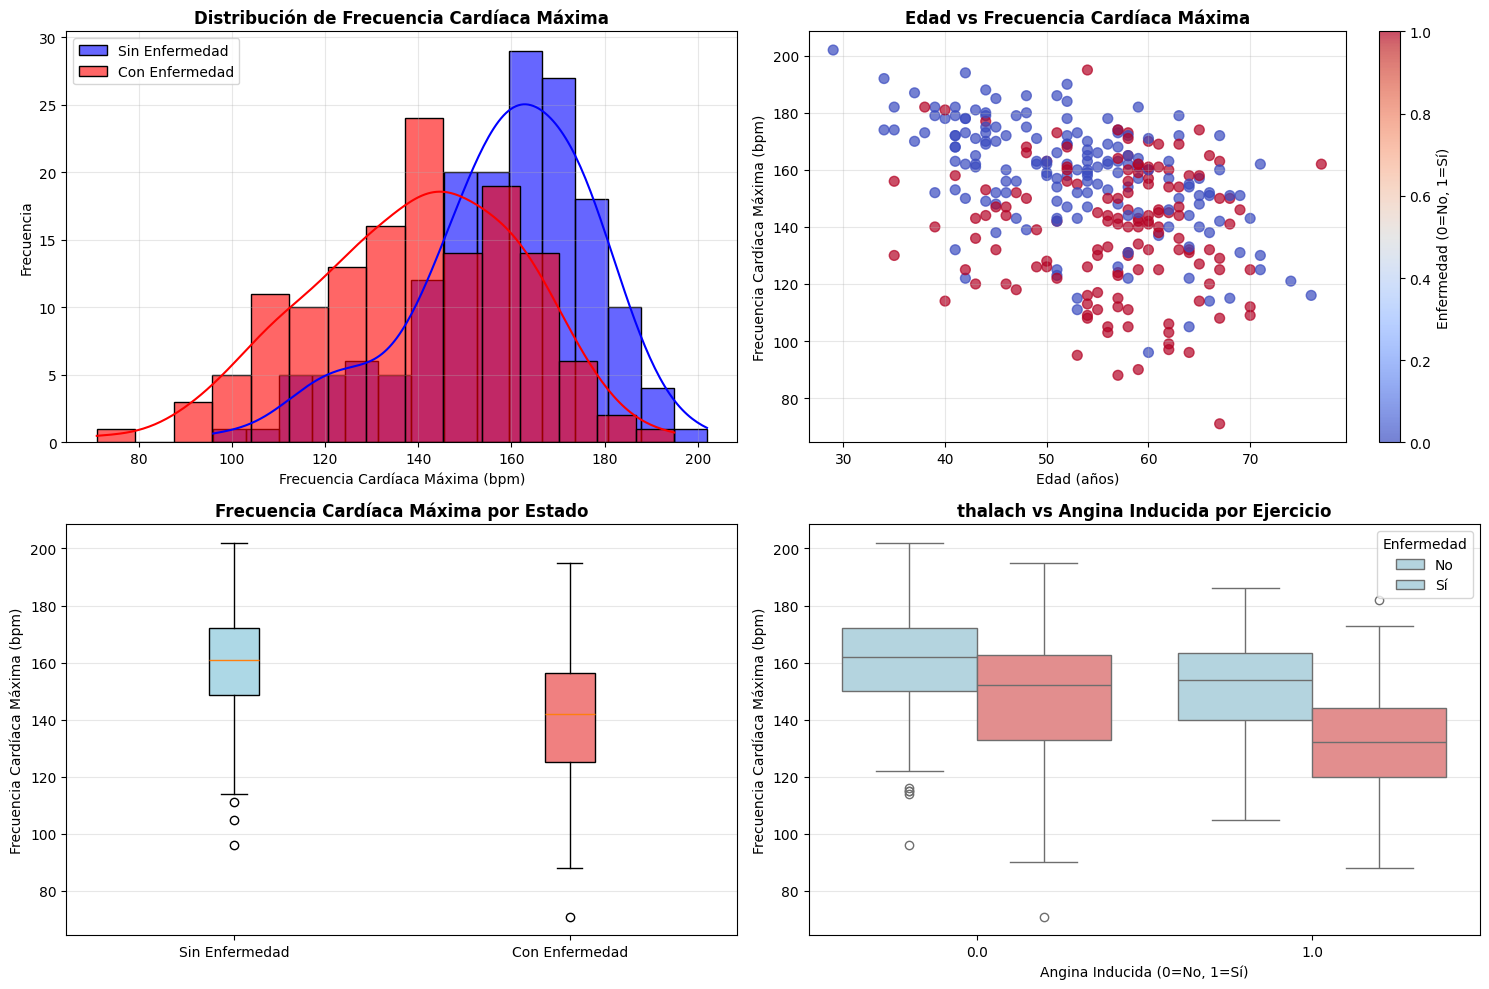

In [ ]:
# Bloque 10.2b CORREGIDO: Visualizaciones adicionales para thalach
print("=== VISUALIZACIONES ESPECIALES PARA thalach ===")

plt.figure(figsize=(15, 10))

# Gráfico 1: Distribución comparativa de thalach
plt.subplot(2, 2, 1)
sns.histplot(data=df[df['target']==0], x='thalach', color='blue',
             label='Sin Enfermedad', alpha=0.6, kde=True, bins=15)
sns.histplot(data=df[df['target']==1], x='thalach', color='red',
             label='Con Enfermedad', alpha=0.6, kde=True, bins=15)
plt.title('Distribución de Frecuencia Cardíaca Máxima', fontweight='bold')
plt.xlabel('Frecuencia Cardíaca Máxima (bpm)')
plt.ylabel('Frecuencia')
plt.legend()
plt.grid(alpha=0.3)

# Gráfico 2: thalach vs Edad
plt.subplot(2, 2, 2)
scatter = plt.scatter(df['age'], df['thalach'], c=df['target'],
                     cmap='coolwarm', alpha=0.7, s=50)
plt.colorbar(scatter, label='Enfermedad (0=No, 1=Sí)')
plt.title('Edad vs Frecuencia Cardíaca Máxima', fontweight='bold')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia Cardíaca Máxima (bpm)')
plt.grid(alpha=0.3)

# Gráfico 3: thalach por categorías de enfermedad
plt.subplot(2, 2, 3)
thalach_by_target = df.groupby('target')['thalach'].apply(list)
box_data = [thalach_by_target[0], thalach_by_target[1]]
box = plt.boxplot(box_data, labels=['Sin Enfermedad', 'Con Enfermedad'],
                 patch_artist=True)
# Colorear las cajas
colors = ['lightblue', 'lightcoral']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Frecuencia Cardíaca Máxima por Estado', fontweight='bold')
plt.ylabel('Frecuencia Cardíaca Máxima (bpm)')
plt.grid(axis='y', alpha=0.3)

# Gráfico 4: thalach vs Angina inducida - CORREGIDO
plt.subplot(2, 2, 4)
df_temp2 = df.copy()
df_temp2['target_str'] = df_temp2['target'].astype(str)
df_temp2['exang_str'] = df_temp2['exang'].astype(str)
sns.boxplot(data=df_temp2, x='exang_str', y='thalach', hue='target_str',
           palette={'0': 'lightblue', '1': 'lightcoral'})
plt.title('thalach vs Angina Inducida por Ejercicio', fontweight='bold')
plt.xlabel('Angina Inducida (0=No, 1=Sí)')
plt.ylabel('Frecuencia Cardíaca Máxima (bpm)')
plt.legend(title='Enfermedad', labels=['No', 'Sí'])
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Limpiar variable temporal
del df_temp2

Matriz de correlacion

=== MATRIZ DE CORRELACIÓN MEJORADA ===


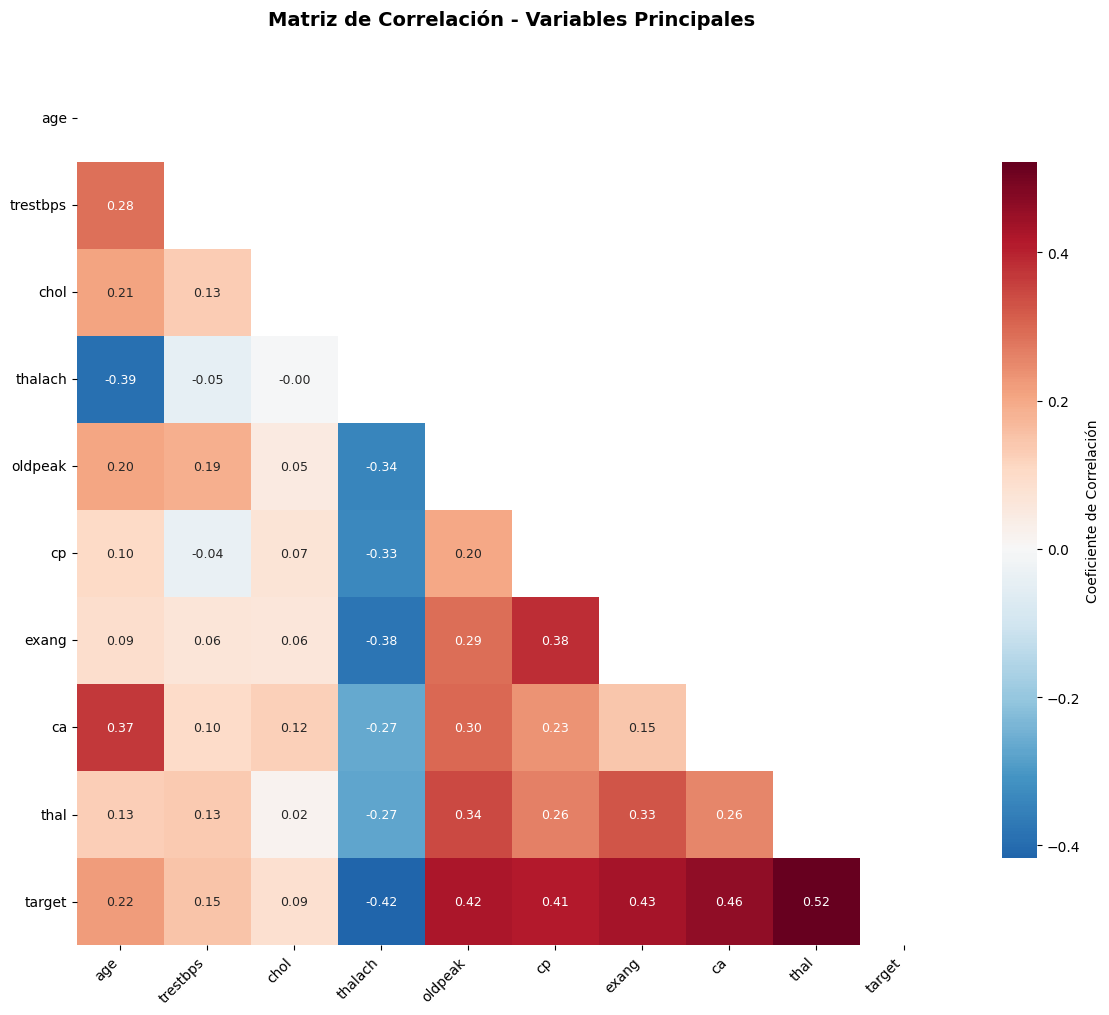

In [ ]:
# Bloque 10.2c: Heatmap de correlaciones mejorado (SIN ERRORES)
print("=== MATRIZ DE CORRELACIÓN MEJORADA ===")

plt.figure(figsize=(12, 10))

# Seleccionar solo las variables más relevantes para evitar sobrecarga
important_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak',
                 'cp', 'exang', 'ca', 'thal', 'target']
corr_subset = df[important_vars].corr()

# Crear máscara para el triángulo superior
mask = np.triu(np.ones_like(corr_subset, dtype=bool))

# Heatmap mejorado
sns.heatmap(corr_subset, mask=mask, annot=True, cmap='RdBu_r',
           fmt='.2f', center=0, square=True,
           cbar_kws={"shrink": .8, "label": "Coeficiente de Correlación"},
           annot_kws={"size": 9})

plt.title('Matriz de Correlación - Variables Principales\n',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Realizamos el analisis de relaciones multiples y graficamos

=== ANÁLISIS DE RELACIONES MÚLTIPLES ===


<Figure size 1200x1000 with 0 Axes>

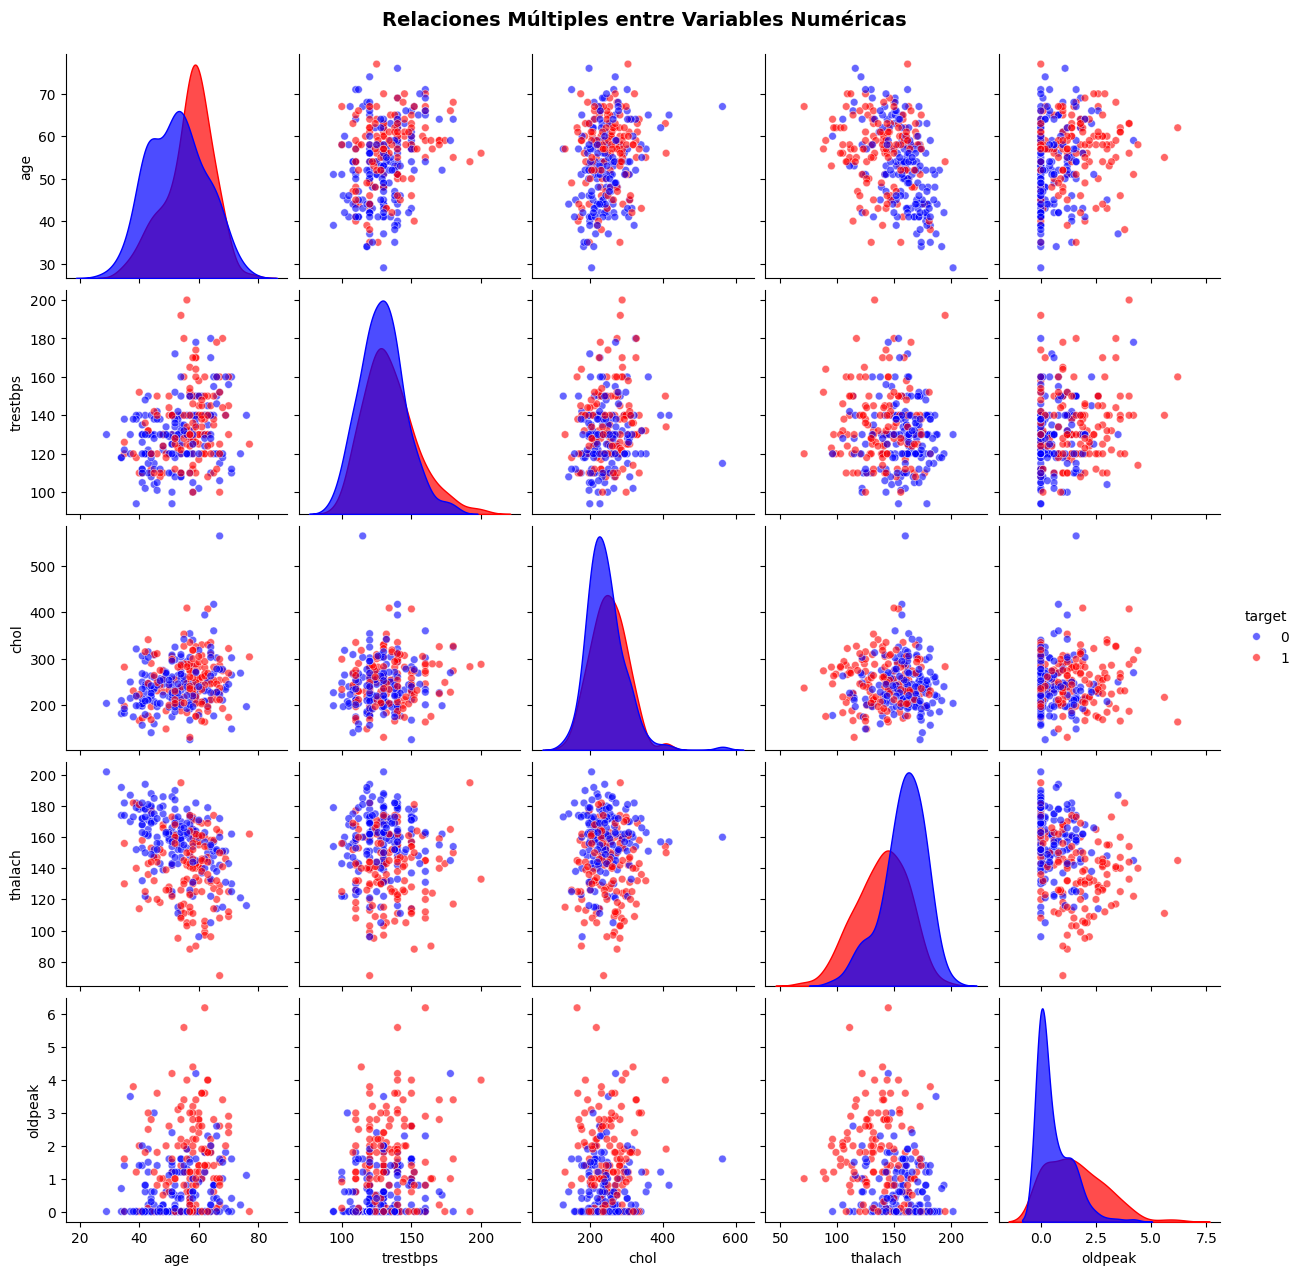

In [ ]:
# Bloque 10.2d: Gráficos de pairplot para relaciones múltiples (CORREGIDO)
print("=== ANÁLISIS DE RELACIONES MÚLTIPLES ===")

# Seleccionar variables clave para pairplot
pairplot_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'target']

# Crear copia con target como string para pairplot
df_pairplot = df[pairplot_vars].copy()
df_pairplot['target'] = df_pairplot['target'].astype(str)

plt.figure(figsize=(12, 10))
pairplot = sns.pairplot(df_pairplot, hue='target',
             palette={'0': 'blue', '1': 'red'},
             plot_kws={'alpha': 0.6, 's': 30},
             diag_kws={'alpha': 0.7})
plt.suptitle('Relaciones Múltiples entre Variables Numéricas\n',
             y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Limpiar
del df_pairplot

Mostramos los graficos finales que resumen los factores clave

=== RESUMEN GRÁFICO DE FACTORES CLAVE ===


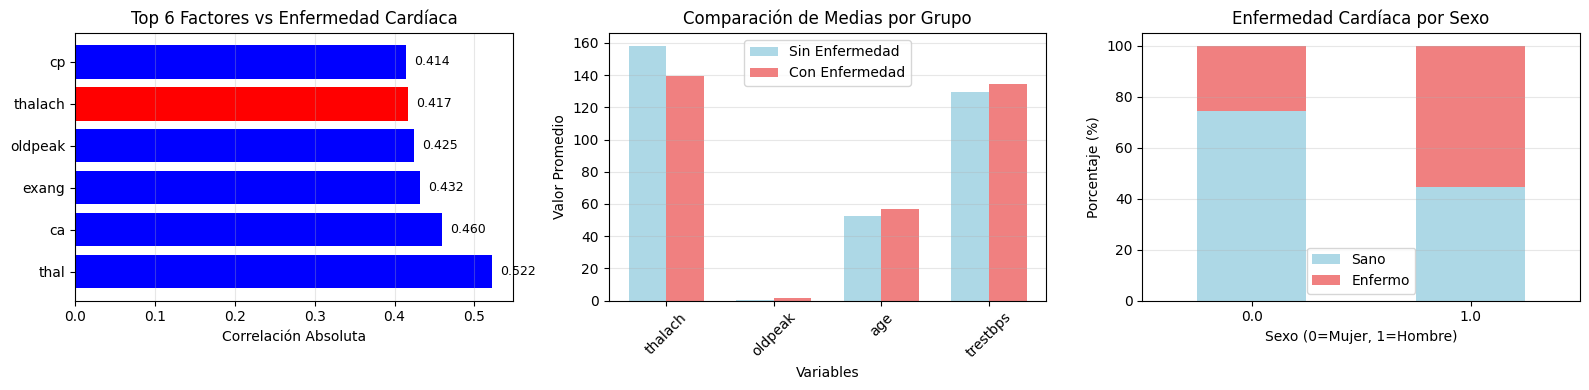

In [ ]:
# Bloque 10.2e: Gráficos finales de resumen
print("=== RESUMEN GRÁFICO DE FACTORES CLAVE ===")

plt.figure(figsize=(16, 4))

# Gráfico 1: Top 6 correlaciones con enfermedad cardíaca
plt.subplot(1, 3, 1)
if 'target' in correlation_matrix.columns:
    top_correlations = correlation_matrix['target'].drop(['target', 'target_original']).abs().nlargest(6)
    colors = ['red' if correlation_matrix.loc[var, 'target'] < 0 else 'blue' for var in top_correlations.index]
    plt.barh(range(len(top_correlations)), top_correlations.values, color=colors)
    plt.yticks(range(len(top_correlations)), top_correlations.index)
    plt.xlabel('Correlación Absoluta')
    plt.title('Top 6 Factores vs Enfermedad Cardíaca')
    plt.grid(axis='x', alpha=0.3)
    # Agregar valores en las barras
    for i, v in enumerate(top_correlations.values):
        plt.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Gráfico 2: Comparación de medias entre grupos
plt.subplot(1, 3, 2)
comparison_vars = ['thalach', 'oldpeak', 'age', 'trestbps']
means_0 = [df[df['target']==0][var].mean() for var in comparison_vars]
means_1 = [df[df['target']==1][var].mean() for var in comparison_vars]
x = np.arange(len(comparison_vars))
width = 0.35
plt.bar(x - width/2, means_0, width, label='Sin Enfermedad', color='lightblue')
plt.bar(x + width/2, means_1, width, label='Con Enfermedad', color='lightcoral')
plt.xlabel('Variables')
plt.ylabel('Valor Promedio')
plt.title('Comparación de Medias por Grupo')
plt.xticks(x, comparison_vars, rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Gráfico 3: Proporción de enfermedad por sexo
plt.subplot(1, 3, 3)
sex_target = pd.crosstab(df['sex'], df['target'], normalize='index') * 100
sex_target.plot(kind='bar', stacked=True, color=['lightblue', 'lightcoral'], ax=plt.gca())
plt.title('Enfermedad Cardíaca por Sexo')
plt.xlabel('Sexo (0=Mujer, 1=Hombre)')
plt.ylabel('Porcentaje (%)')
plt.legend(['Sano', 'Enfermo'])
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Mostramos los insights del analisis exploratorio

In [ ]:
# Bloque 10.3: Resumen de insights del análisis exploratorio
print("=== INSIGHTS DEL ANÁLISIS EXPLORATORIO ===")

print("\n🔍 OBSERVACIONES CLAVE:")

# 1. Sobre el target
print("1. DISTRIBUCIÓN DE ENFERMEDAD:")
print(f"   - Pacientes sin enfermedad: {len(df[df['target']==0])} ({len(df[df['target']==0])/len(df)*100:.1f}%)")
print(f"   - Pacientes con enfermedad: {len(df[df['target']==1])} ({len(df[df['target']==1])/len(df)*100:.1f}%)")
print("   → Dataset razonablemente balanceado")

# 2. Correlaciones fuertes con enfermedad cardíaca
if 'target' in correlation_matrix.columns:
    strong_corrs = correlation_matrix['target'].abs().nlargest(6)
    strong_corrs = strong_corrs[strong_corrs.index != 'target']
    print(f"\n2. FACTORES MÁS RELACIONADOS CON ENFERMEDAD:")
    for var in strong_corrs.index[:3]:
        corr = correlation_matrix.loc[var, 'target']
        print(f"   - {var}: {corr:.3f}")

# 3. Correlaciones con colesterol
if 'chol' in correlation_matrix.columns:
    chol_strong = correlation_matrix['chol'].abs().nlargest(4)
    chol_strong = chol_strong[chol_strong.index != 'chol']
    print(f"\n3. FACTORES RELACIONADOS CON COLESTEROL:")
    for var in chol_strong.index[:2]:
        corr = correlation_matrix.loc[var, 'chol']
        print(f"   - {var}: {corr:.3f}")

print("\n✅ Análisis exploratorio completado exitosamente")

=== INSIGHTS DEL ANÁLISIS EXPLORATORIO ===

🔍 OBSERVACIONES CLAVE:
1. DISTRIBUCIÓN DE ENFERMEDAD:
   - Pacientes sin enfermedad: 164 (54.1%)
   - Pacientes con enfermedad: 139 (45.9%)
   → Dataset razonablemente balanceado

2. FACTORES MÁS RELACIONADOS CON ENFERMEDAD:
   - target_original: 0.830
   - thal: 0.522
   - ca: 0.460

3. FACTORES RELACIONADOS CON COLESTEROL:
   - age: 0.209
   - sex: -0.200

✅ Análisis exploratorio completado exitosamente


Visualizaciones - Distribuciones de variables clave

=== DISTRIBUCIONES DE VARIABLES CLAVE ===


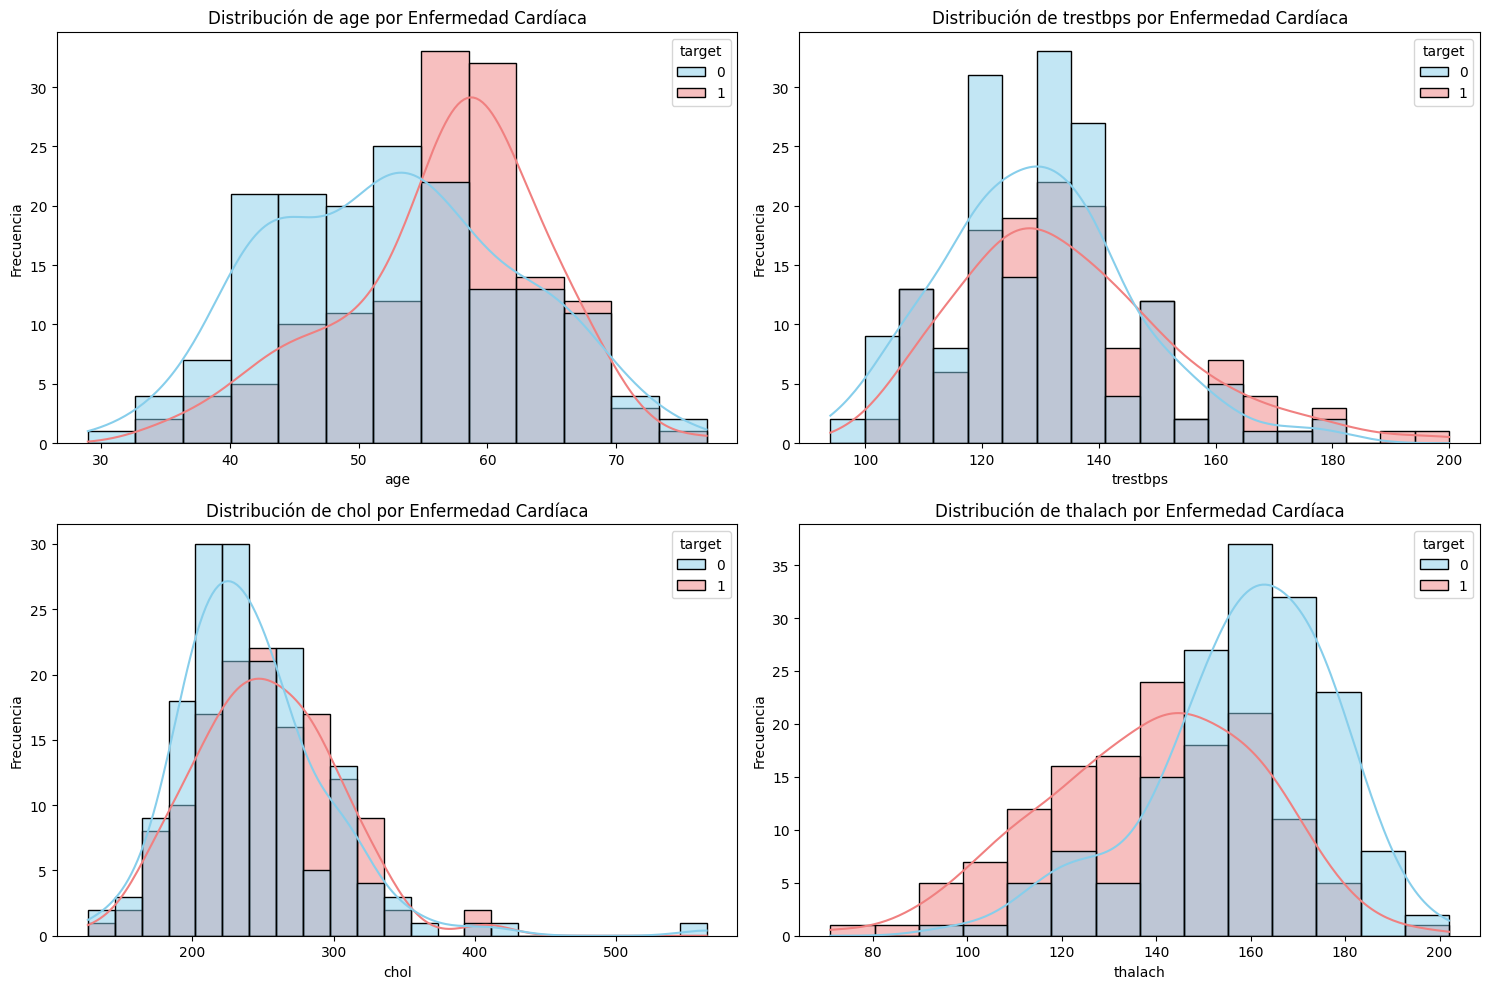

In [ ]:
# Bloque 11: Visualizaciones - Distribuciones de variables clave
print("=== DISTRIBUCIONES DE VARIABLES CLAVE ===")

# Variables numéricas clave
key_numeric_vars = ['age', 'trestbps', 'chol', 'thalach']

plt.figure(figsize=(15, 10))

for i, var in enumerate(key_numeric_vars, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=var, hue='target', kde=True, palette=['skyblue', 'lightcoral'])
    plt.title(f'Distribución de {var} por Enfermedad Cardíaca')
    plt.xlabel(var)
    plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

Visualizaciones sobre las relaciones entre las variables y targets

=== RELACIONES ENTRE VARIABLES Y TARGETS ===


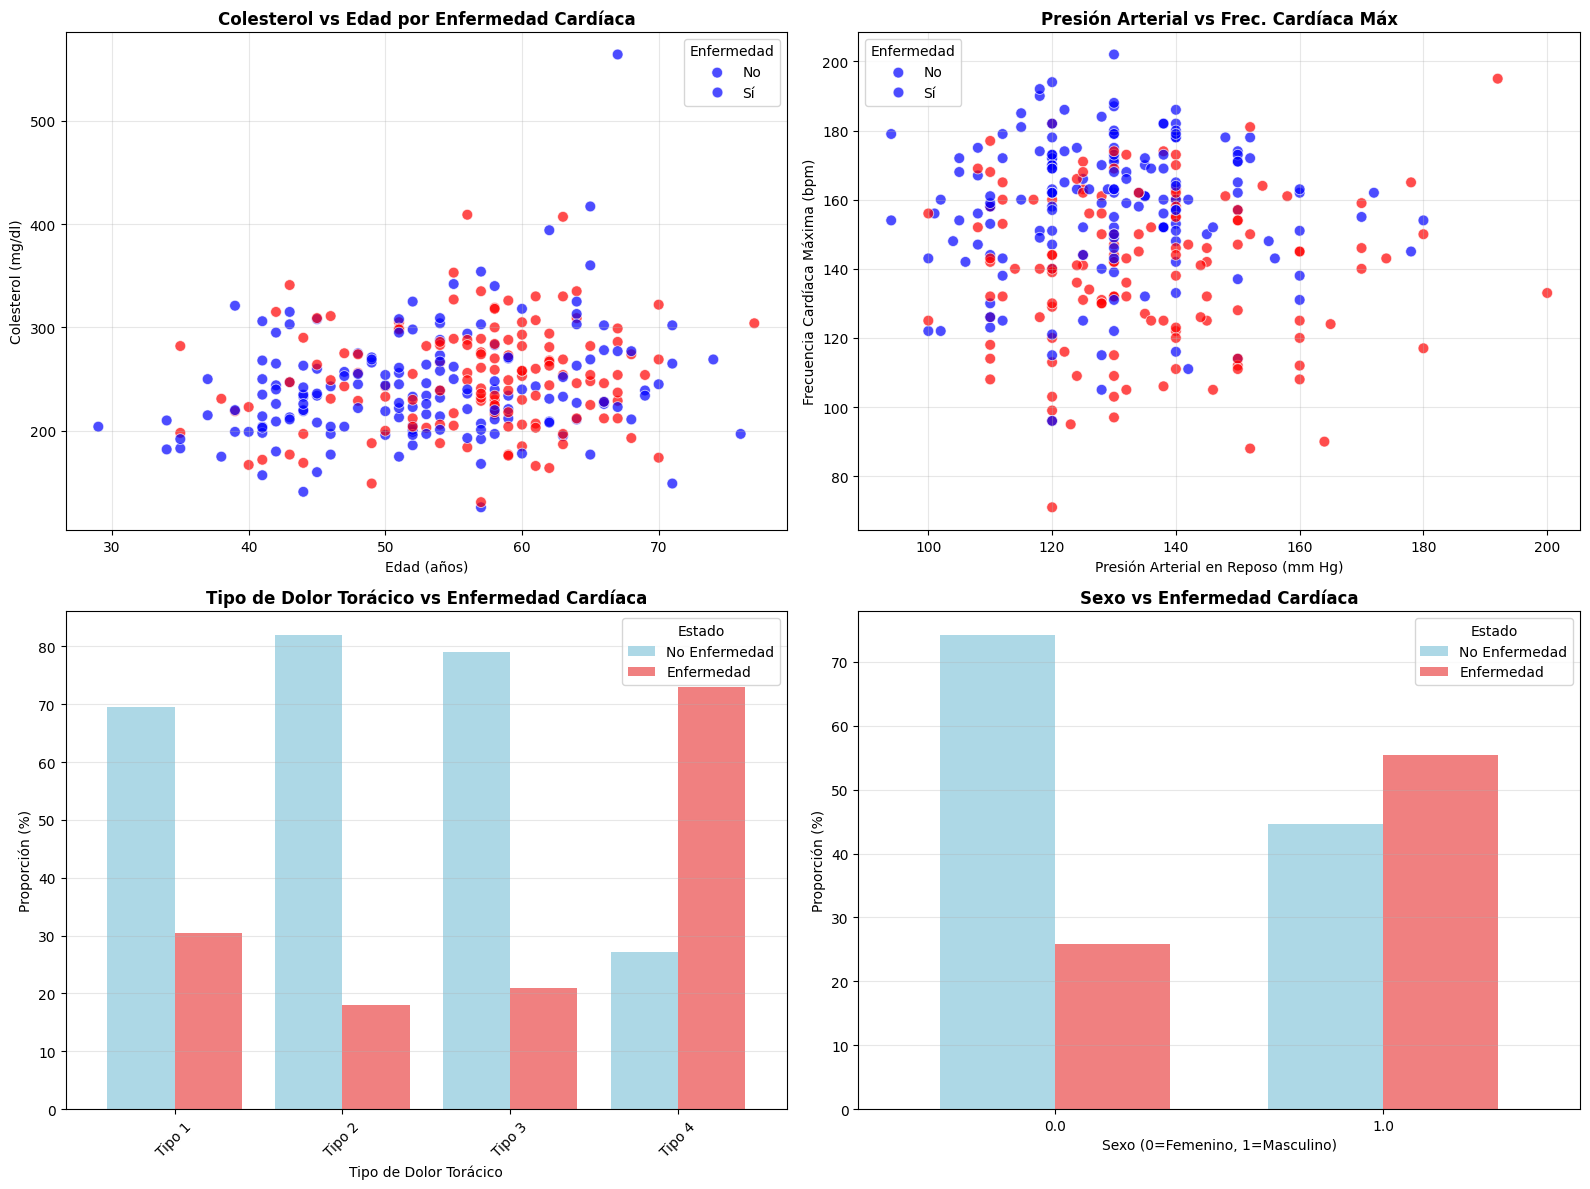

In [ ]:
# Bloque 12 CORREGIDO: Visualizaciones - Relaciones entre variables y targets
print("=== RELACIONES ENTRE VARIABLES Y TARGETS ===")

# Crear una figura principal con subplots bien organizados
fig = plt.figure(figsize=(16, 12))

# Gráfico 1: Colesterol vs Edad por enfermedad cardíaca
ax1 = plt.subplot(2, 2, 1)
df_temp = df.copy()
df_temp['target_str'] = df_temp['target'].astype(str)
scatter1 = sns.scatterplot(data=df_temp, x='age', y='chol', hue='target_str',
                          palette={'0': 'blue', '1': 'red'}, alpha=0.7, s=60, ax=ax1)
ax1.set_title('Colesterol vs Edad por Enfermedad Cardíaca', fontweight='bold')
ax1.set_xlabel('Edad (años)')
ax1.set_ylabel('Colesterol (mg/dl)')
ax1.legend(title='Enfermedad', labels=['No', 'Sí'])
ax1.grid(alpha=0.3)

# Gráfico 2: Presión arterial vs Frecuencia cardíaca máxima
ax2 = plt.subplot(2, 2, 2)
scatter2 = sns.scatterplot(data=df_temp, x='trestbps', y='thalach', hue='target_str',
                          palette={'0': 'blue', '1': 'red'}, alpha=0.7, s=60, ax=ax2)
ax2.set_title('Presión Arterial vs Frec. Cardíaca Máx', fontweight='bold')
ax2.set_xlabel('Presión Arterial en Reposo (mm Hg)')
ax2.set_ylabel('Frecuencia Cardíaca Máxima (bpm)')
ax2.legend(title='Enfermedad', labels=['No', 'Sí'])
ax2.grid(alpha=0.3)

# Gráfico 3: Tipo de dolor torácico vs Enfermedad cardíaca
ax3 = plt.subplot(2, 2, 3)
cp_mapping = {1.0: 'Tipo 1', 2.0: 'Tipo 2', 3.0: 'Tipo 3', 4.0: 'Tipo 4'}
df_cp = df.copy()
df_cp['cp_label'] = df_cp['cp'].map(cp_mapping)
cp_target = pd.crosstab(df_cp['cp_label'], df_cp['target'])
cp_target_percentage = cp_target.div(cp_target.sum(axis=1), axis=0) * 100

bars = cp_target_percentage.plot(kind='bar', color=['lightblue', 'lightcoral'],
                                ax=ax3, width=0.8)
ax3.set_title('Tipo de Dolor Torácico vs Enfermedad Cardíaca', fontweight='bold')
ax3.set_xlabel('Tipo de Dolor Torácico')
ax3.set_ylabel('Proporción (%)')
ax3.legend(['No Enfermedad', 'Enfermedad'], title='Estado')
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)

# Gráfico 4: Sexo vs Enfermedad cardíaca
ax4 = plt.subplot(2, 2, 4)
sex_target = pd.crosstab(df['sex'], df['target'])
sex_target_percentage = sex_target.div(sex_target.sum(axis=1), axis=0) * 100

bars = sex_target_percentage.plot(kind='bar', color=['lightblue', 'lightcoral'],
                                 ax=ax4, width=0.7)
ax4.set_title('Sexo vs Enfermedad Cardíaca', fontweight='bold')
ax4.set_xlabel('Sexo (0=Femenino, 1=Masculino)')
ax4.set_ylabel('Proporción (%)')
ax4.legend(['No Enfermedad', 'Enfermedad'], title='Estado')
ax4.tick_params(axis='x', rotation=0)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Limpiar variables temporales
del df_temp, df_cp

Mostramos las relaciones adicionales entre las variables

=== RELACIONES ADICIONALES ENTRE VARIABLES CLAVE ===


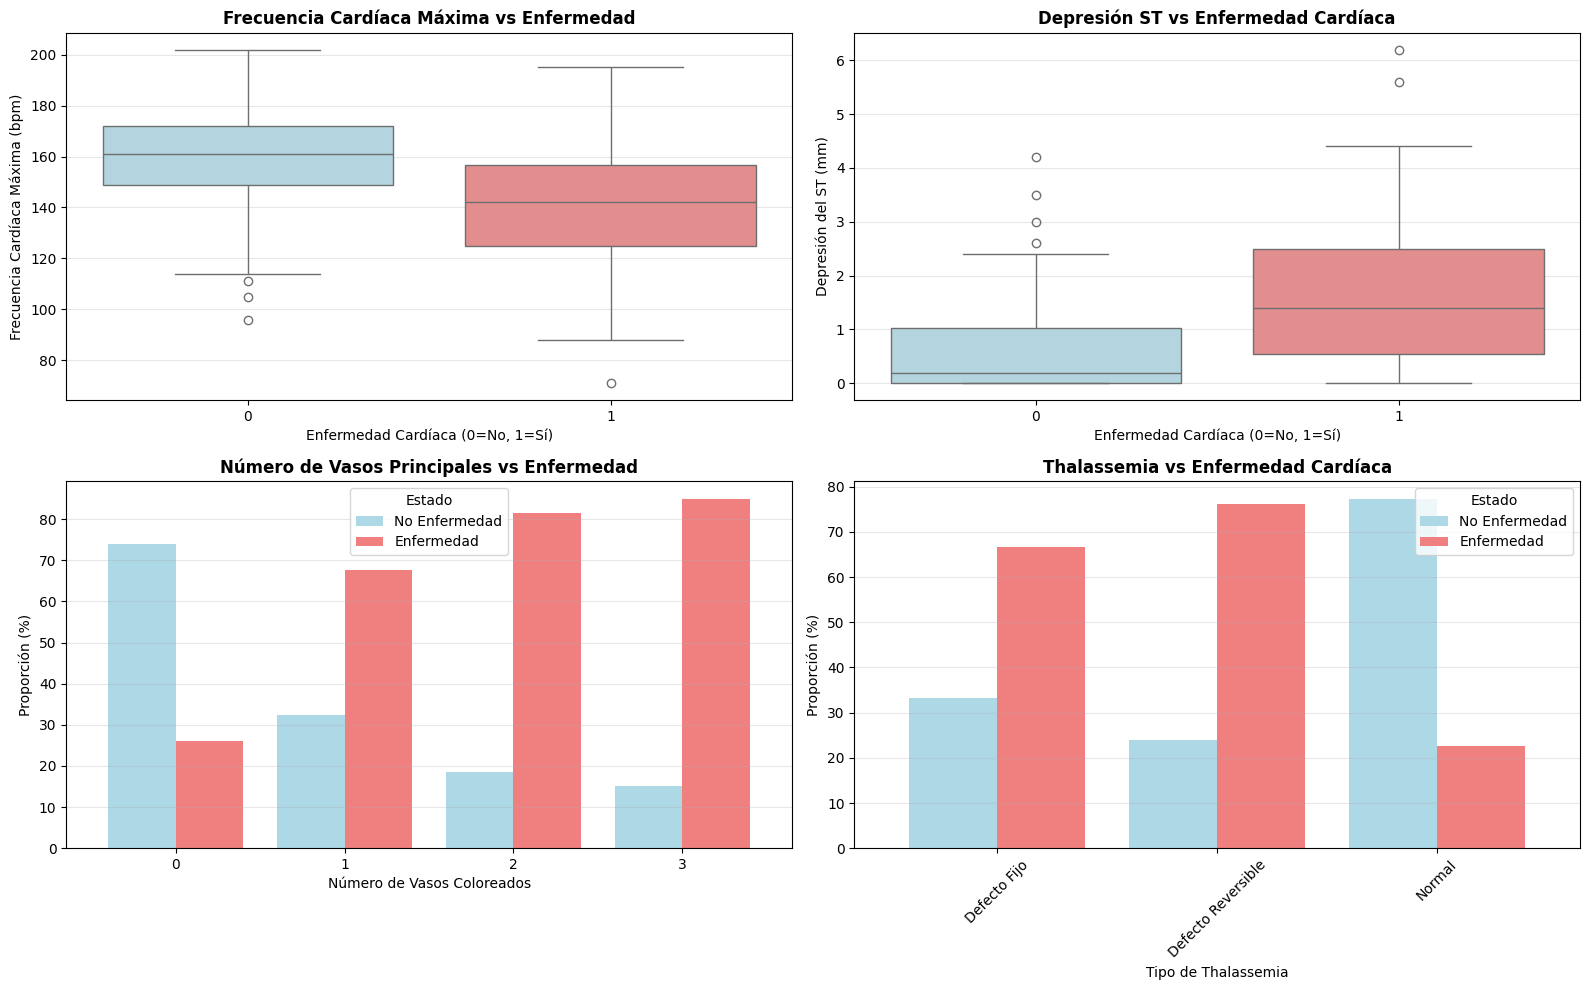

In [ ]:
# Bloque 12b: Visualizaciones adicionales de relaciones
print("=== RELACIONES ADICIONALES ENTRE VARIABLES CLAVE ===")

# Crear una segunda figura para más visualizaciones
fig = plt.figure(figsize=(16, 10))

# Gráfico 1: thalach (frecuencia cardíaca máxima) por enfermedad
ax1 = plt.subplot(2, 2, 1)
df_temp2 = df.copy()
df_temp2['target_str'] = df_temp2['target'].astype(str)
sns.boxplot(data=df_temp2, x='target_str', y='thalach',
           palette={'0': 'lightblue', '1': 'lightcoral'}, ax=ax1)
ax1.set_title('Frecuencia Cardíaca Máxima vs Enfermedad', fontweight='bold')
ax1.set_xlabel('Enfermedad Cardíaca (0=No, 1=Sí)')
ax1.set_ylabel('Frecuencia Cardíaca Máxima (bpm)')
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: oldpeak (depresión ST) por enfermedad
ax2 = plt.subplot(2, 2, 2)
sns.boxplot(data=df_temp2, x='target_str', y='oldpeak',
           palette={'0': 'lightblue', '1': 'lightcoral'}, ax=ax2)
ax2.set_title('Depresión ST vs Enfermedad Cardíaca', fontweight='bold')
ax2.set_xlabel('Enfermedad Cardíaca (0=No, 1=Sí)')
ax2.set_ylabel('Depresión del ST (mm)')
ax2.grid(axis='y', alpha=0.3)

# Gráfico 3: Número de vasos principales (ca) vs enfermedad
ax3 = plt.subplot(2, 2, 3)
ca_target = pd.crosstab(df['ca'], df['target'])
ca_target_percentage = ca_target.div(ca_target.sum(axis=1), axis=0) * 100

bars = ca_target_percentage.plot(kind='bar', color=['lightblue', 'lightcoral'],
                                ax=ax3, width=0.8)
ax3.set_title('Número de Vasos Principales vs Enfermedad', fontweight='bold')
ax3.set_xlabel('Número de Vasos Coloreados')
ax3.set_ylabel('Proporción (%)')
ax3.legend(['No Enfermedad', 'Enfermedad'], title='Estado')
ax3.tick_params(axis='x', rotation=0)
ax3.grid(axis='y', alpha=0.3)

# Gráfico 4: Thalassemia vs enfermedad
ax4 = plt.subplot(2, 2, 4)
thal_mapping = {3: 'Normal', 6: 'Defecto Fijo', 7: 'Defecto Reversible'}
df_thal = df.copy()
df_thal['thal_label'] = df_thal['thal'].map(thal_mapping)
thal_target = pd.crosstab(df_thal['thal_label'], df_thal['target'])
thal_target_percentage = thal_target.div(thal_target.sum(axis=1), axis=0) * 100

bars = thal_target_percentage.plot(kind='bar', color=['lightblue', 'lightcoral'],
                                  ax=ax4, width=0.8)
ax4.set_title('Thalassemia vs Enfermedad Cardíaca', fontweight='bold')
ax4.set_xlabel('Tipo de Thalassemia')
ax4.set_ylabel('Proporción (%)')
ax4.legend(['No Enfermedad', 'Enfermedad'], title='Estado')
ax4.tick_params(axis='x', rotation=45)
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Limpiar variables temporales
del df_temp2, df_thal

Visualizamos la distribucion por enfermedad

=== DISTRIBUCIONES POR ESTADO DE ENFERMEDAD ===


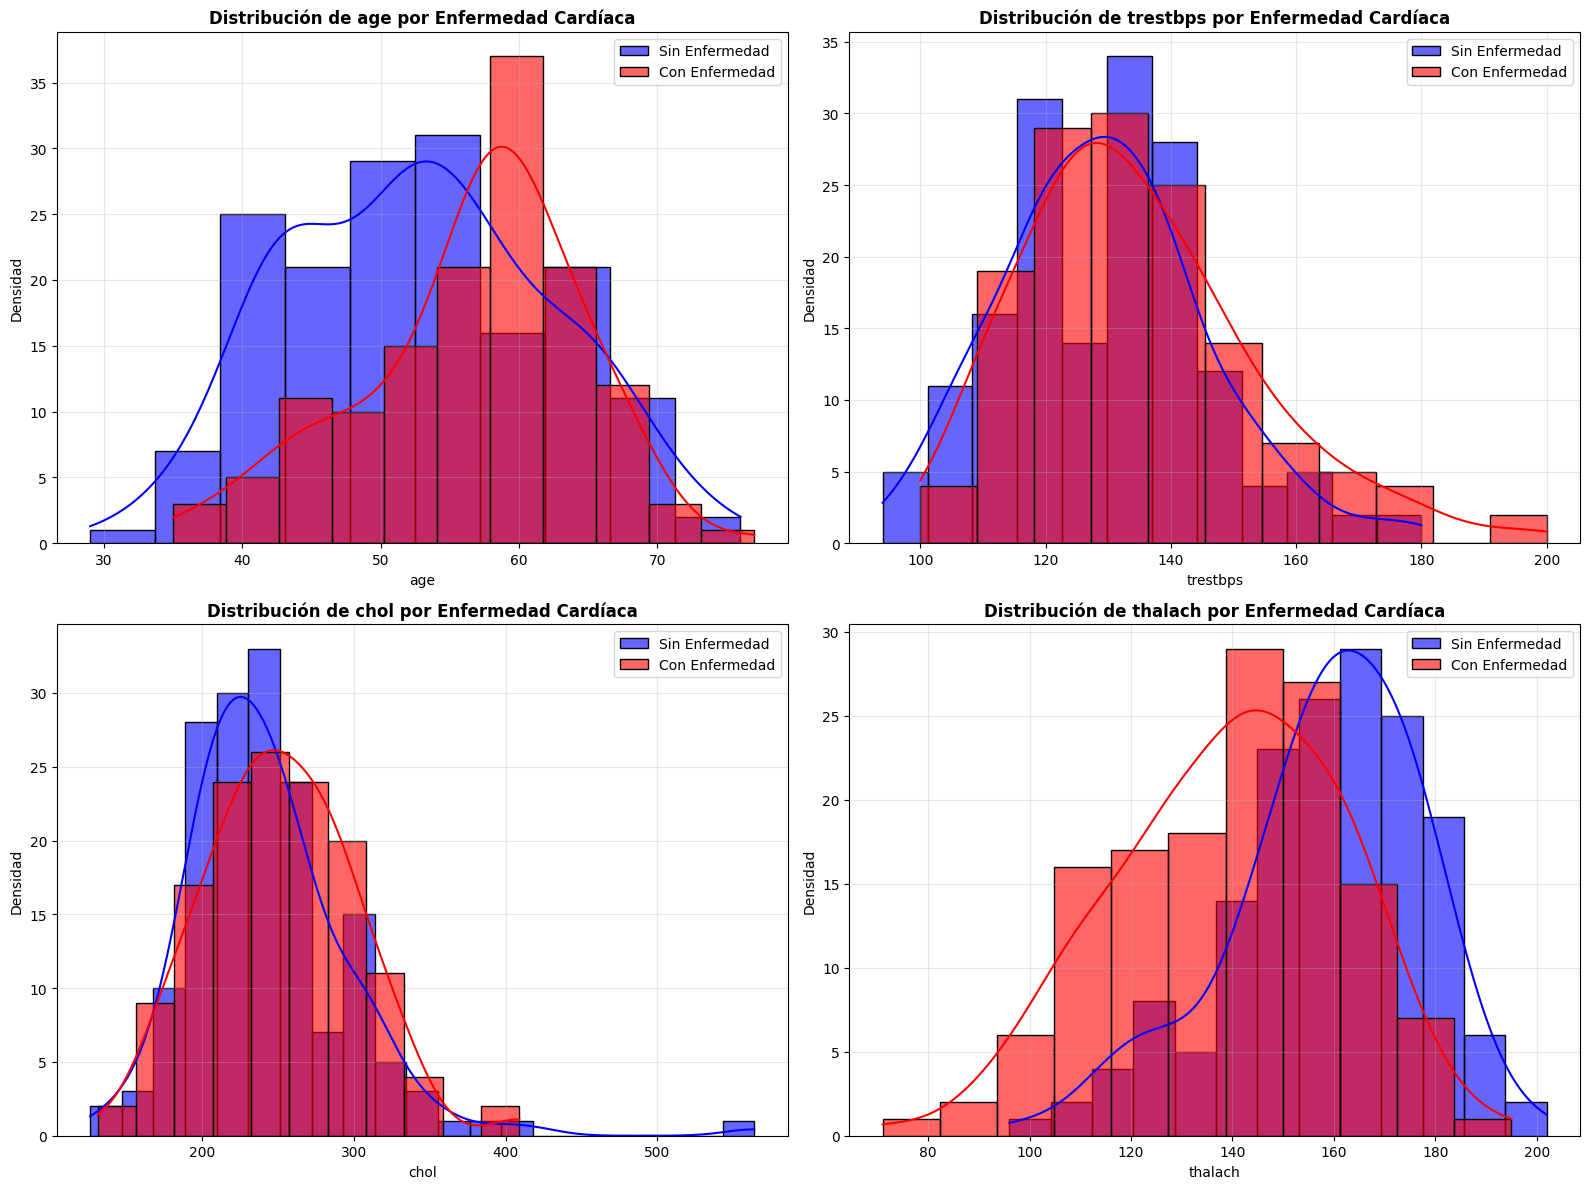

In [ ]:
# Bloque 12c: Visualizaciones de distribución por enfermedad
print("=== DISTRIBUCIONES POR ESTADO DE ENFERMEDAD ===")

# Variables numéricas clave para análisis de distribución
key_numeric_vars = ['age', 'trestbps', 'chol', 'thalach']

fig = plt.figure(figsize=(16, 12))

for i, var in enumerate(key_numeric_vars, 1):
    ax = plt.subplot(2, 2, i)

    # Crear histogramas superpuestos
    sns.histplot(data=df[df['target'] == 0], x=var, color='blue',
                 label='Sin Enfermedad', alpha=0.6, kde=True, ax=ax)
    sns.histplot(data=df[df['target'] == 1], x=var, color='red',
                 label='Con Enfermedad', alpha=0.6, kde=True, ax=ax)

    ax.set_title(f'Distribución de {var} por Enfermedad Cardíaca', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Densidad')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Analizamos las relaciones con variables categóricas

=== ANÁLISIS CON VARIABLES CATEGÓRICAS ===


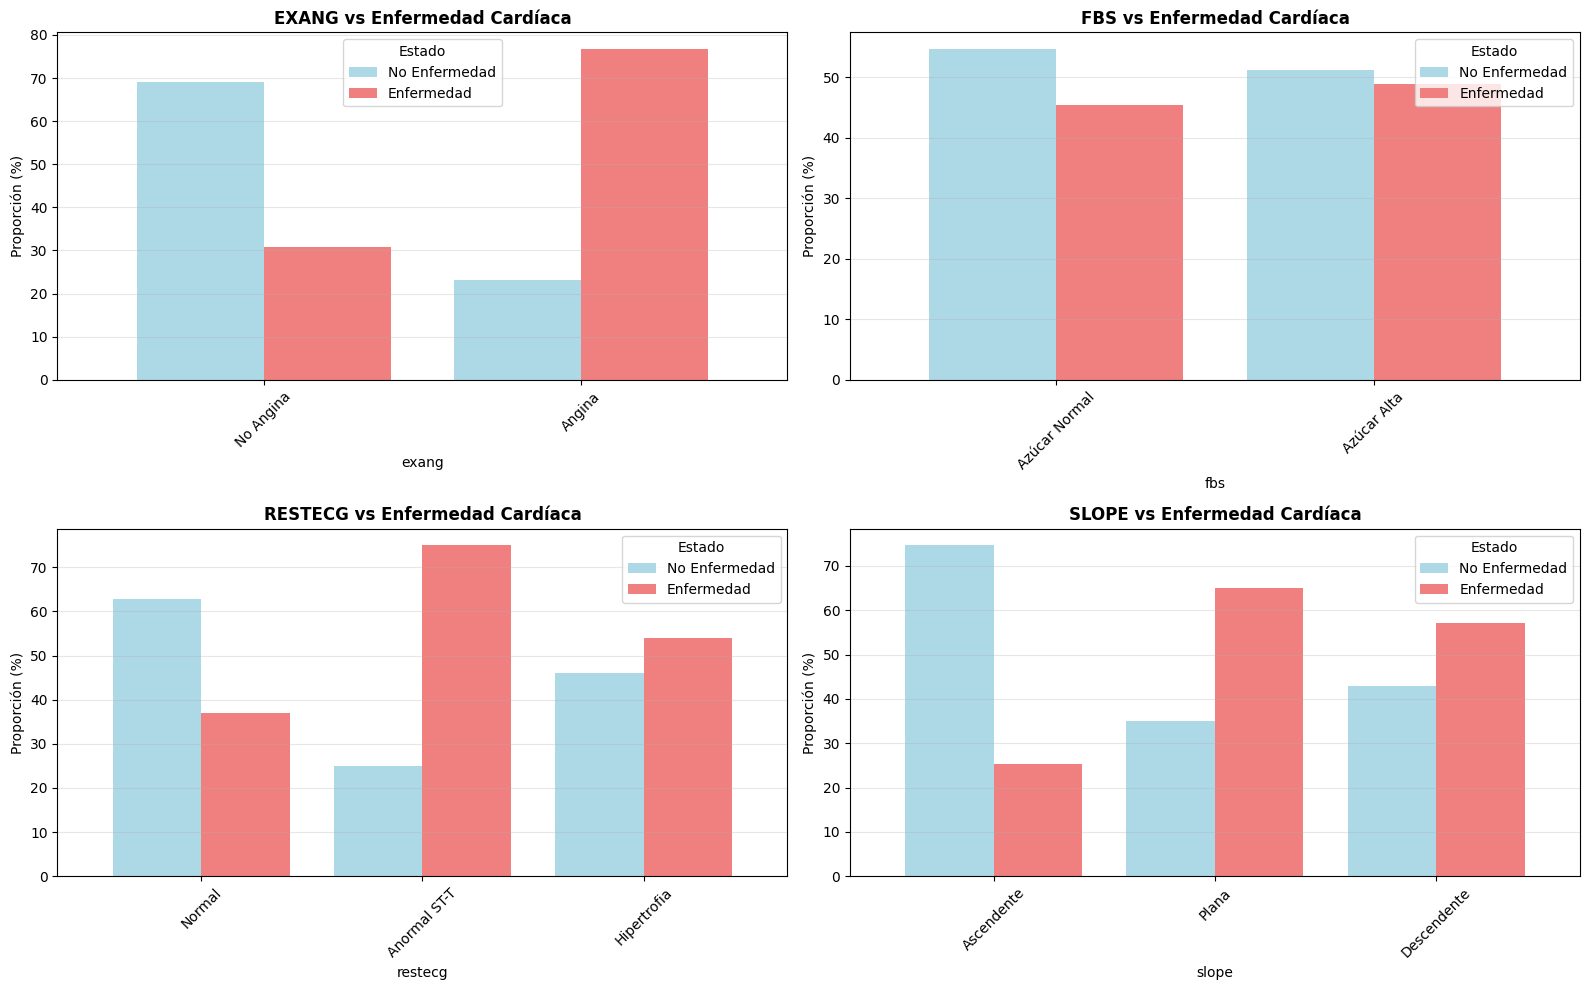

In [ ]:
# Bloque 12d: Análisis de relaciones con variables categóricas
print("=== ANÁLISIS CON VARIABLES CATEGÓRICAS ===")

# Variables categóricas importantes
categorical_vars_analysis = ['exang', 'fbs', 'restecg', 'slope']

fig = plt.figure(figsize=(16, 10))

for i, var in enumerate(categorical_vars_analysis, 1):
    ax = plt.subplot(2, 2, i)

    # Crear tabla de contingencia
    var_target = pd.crosstab(df[var], df['target'])
    var_target_percentage = var_target.div(var_target.sum(axis=1), axis=0) * 100

    # Mapear nombres para mejor legibilidad
    if var == 'exang':
        var_names = {0: 'No Angina', 1: 'Angina'}
    elif var == 'fbs':
        var_names = {0: 'Azúcar Normal', 1: 'Azúcar Alta'}
    elif var == 'restecg':
        var_names = {0: 'Normal', 1: 'Anormal ST-T', 2: 'Hipertrofia'}
    elif var == 'slope':
        var_names = {1: 'Ascendente', 2: 'Plana', 3: 'Descendente'}
    else:
        var_names = {}

    # Renombrar índices si hay mapeo disponible
    if var_names:
        var_target_percentage.index = var_target_percentage.index.map(
            lambda x: var_names.get(x, x)
        )

    # Graficar
    bars = var_target_percentage.plot(kind='bar', color=['lightblue', 'lightcoral'],
                                     ax=ax, width=0.8)
    ax.set_title(f'{var.upper()} vs Enfermedad Cardíaca', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Proporción (%)')
    ax.legend(['No Enfermedad', 'Enfermedad'], title='Estado')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Mostramos un resumen final visual

=== RESUMEN VISUAL FINAL ===


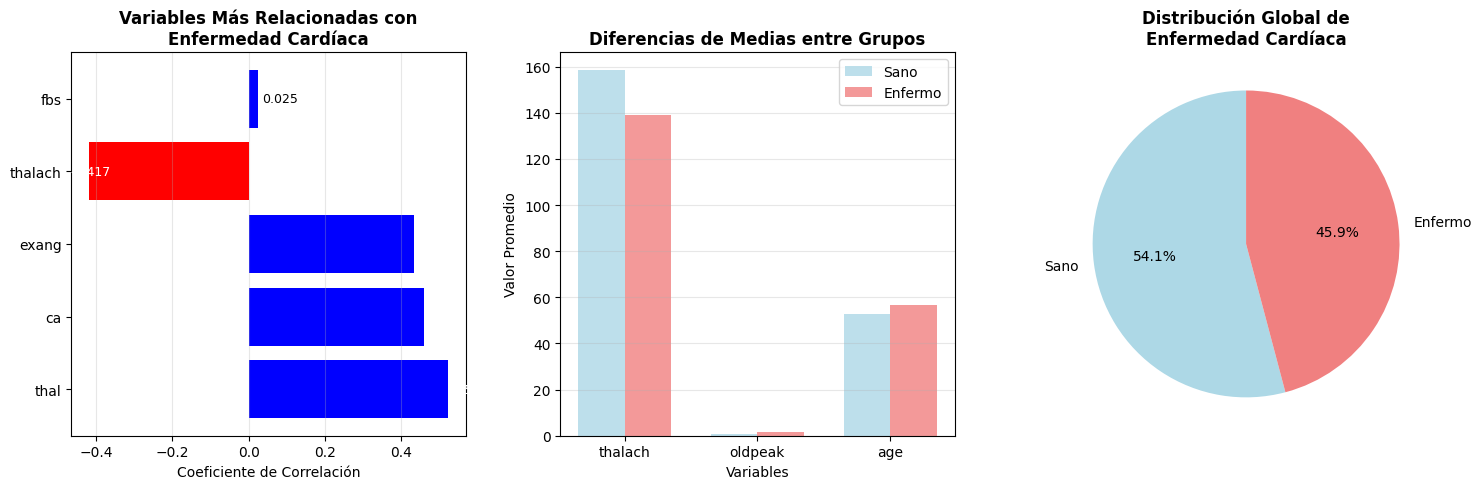

✅ Visualizaciones completadas exitosamente


In [ ]:
# Bloque 12e: Resumen visual final
print("=== RESUMEN VISUAL FINAL ===")

fig = plt.figure(figsize=(15, 5))

# Gráfico 1: Correlaciones top con enfermedad
ax1 = plt.subplot(1, 3, 1)
if 'target' in correlation_matrix.columns:
    # Excluir target_original y target mismo
    target_corrs = correlation_matrix['target'].drop(['target', 'target_original'])
    top_positive = target_corrs.nlargest(3)
    top_negative = target_corrs.nsmallest(2)

    top_corrs = pd.concat([top_positive, top_negative])
    colors = ['red' if val < 0 else 'blue' for val in top_corrs.values]

    bars = ax1.barh(range(len(top_corrs)), top_corrs.values, color=colors)
    ax1.set_yticks(range(len(top_corrs)))
    ax1.set_yticklabels(top_corrs.index)
    ax1.set_xlabel('Coeficiente de Correlación')
    ax1.set_title('Variables Más Relacionadas con\nEnfermedad Cardíaca', fontweight='bold')
    ax1.grid(axis='x', alpha=0.3)

    # Agregar valores
    for i, v in enumerate(top_corrs.values):
        ax1.text(v + (0.01 if v > 0 else -0.05), i, f'{v:.3f}',
                va='center', fontsize=9,
                color='white' if abs(v) > 0.3 else 'black')

# Gráfico 2: Diferencia de medias entre grupos
ax2 = plt.subplot(1, 3, 2)
key_vars = ['thalach', 'oldpeak', 'age']
means_healthy = [df[df['target'] == 0][var].mean() for var in key_vars]
means_disease = [df[df['target'] == 1][var].mean() for var in key_vars]

x = np.arange(len(key_vars))
width = 0.35

bars1 = ax2.bar(x - width/2, means_healthy, width, label='Sano',
               color='lightblue', alpha=0.8)
bars2 = ax2.bar(x + width/2, means_disease, width, label='Enfermo',
               color='lightcoral', alpha=0.8)

ax2.set_xlabel('Variables')
ax2.set_ylabel('Valor Promedio')
ax2.set_title('Diferencias de Medias entre Grupos', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(key_vars)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Gráfico 3: Proporción global
ax3 = plt.subplot(1, 3, 3)
target_counts = df['target'].value_counts()
colors = ['lightblue', 'lightcoral']
wedges, texts, autotexts = ax3.pie(target_counts.values, labels=['Sano', 'Enfermo'],
                                  autopct='%1.1f%%', colors=colors, startangle=90)
ax3.set_title('Distribución Global de\nEnfermedad Cardíaca', fontweight='bold')

plt.tight_layout()
plt.show()

print("✅ Visualizaciones completadas exitosamente")

Preparamos los datos para modelado

In [ ]:
# Bloque 13: Preparación de datos para modelado (ACTUALIZADO)
print("=== PREPARACIÓN FINAL PARA MODELADO ===")

# Para REGRESIÓN (predecir colesterol)
# Excluir target_original ya que es una copia del target antes de la normalización
regression_features_clean = [col for col in regression_features if col != 'target_original']
X_reg = df_regression[regression_features_clean]
y_reg = df_regression['chol']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("🔹 REGRESIÓN (Colesterol):")
print(f"  - Variables predictoras: {X_reg.shape[1]}")
print(f"  - Train: {X_train_reg.shape}")
print(f"  - Test: {X_test_reg.shape}")
print(f"  - Ejemplo de variables: {list(X_reg.columns[:5])}")

# Para CLASIFICACIÓN (predecir enfermedad cardíaca)
# Excluir target_original
classification_features_clean = [col for col in classification_features if col != 'target_original']
X_clf = df_classification[classification_features_clean]
y_clf = df_classification['target']

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("\n🔹 CLASIFICACIÓN (Enfermedad Cardíaca):")
print(f"  - Variables predictoras: {X_clf.shape[1]}")
print(f"  - Train: {X_train_clf.shape}")
print(f"  - Test: {X_test_clf.shape}")
print(f"  - Ejemplo de variables: {list(X_clf.columns[:5])}")

print("\n✅ Datos preparados para modelado")

=== PREPARACIÓN FINAL PARA MODELADO ===
🔹 REGRESIÓN (Colesterol):
  - Variables predictoras: 13
  - Train: (242, 13)
  - Test: (61, 13)
  - Ejemplo de variables: ['age', 'sex', 'cp', 'trestbps', 'fbs']

🔹 CLASIFICACIÓN (Enfermedad Cardíaca):
  - Variables predictoras: 13
  - Train: (242, 13)
  - Test: (61, 13)
  - Ejemplo de variables: ['age', 'sex', 'cp', 'trestbps', 'chol']

✅ Datos preparados para modelado


Mostramos un resumen del Preprocesamiento KDD

In [ ]:
# Bloque 14: Resumen del preprocesamiento completado
print("=== RESUMEN DEL PREPROCESAMIENTO KDD ===")

print("\n📊 DATASET ORIGINAL:")
print(f"  - Filas: {len(df)}")
print(f"  - Columnas: {len(df.columns)}")
print(f"  - Variables numéricas: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"  - Variables categóricas: {len([col for col in categorical_columns if col in df.columns])}")

print("\n🔄 TRANSFORMACIONES APLICADAS:")
print("  ✅ Valores '?' identificados y manejados en 'ca' y 'thal'")
print("  ✅ Target normalizado a valores binarios (0,1)")
print("  ✅ Variables numéricas estandarizadas")
print("  ✅ Valores faltantes imputados")
print("  ✅ Dataset balanceado (54% sano, 46% enfermo)")

print("\n🔍 INSIGHTS CLAVE OBTENIDOS:")
print("  • Thalassemia es el factor más correlacionado con enfermedad cardíaca (0.522)")
print("  • Número de vasos principales (ca) también muy importante (0.460)")
print("  • Angina inducida por ejercicio (exang) correlacionada (0.432)")
print("  • Colesterol tiene correlaciones débiles con otras variables")
print("  • Edad tiene correlación positiva con colesterol (0.209)")

print("\n🎯 PRÓXIMOS PASOS - MODELADO:")
print("  • Regresión: Predecir colesterol usando múltiples variables")
print("  • Clasificación: Detectar enfermedad cardíaca con alta precisión")
print("  • Evaluación con métricas apropiadas para cada tarea")

=== RESUMEN DEL PREPROCESAMIENTO KDD ===

📊 DATASET ORIGINAL:
  - Filas: 303
  - Columnas: 15
  - Variables numéricas: 15
  - Variables categóricas: 8

🔄 TRANSFORMACIONES APLICADAS:
  ✅ Valores '?' identificados y manejados en 'ca' y 'thal'
  ✅ Target normalizado a valores binarios (0,1)
  ✅ Variables numéricas estandarizadas
  ✅ Valores faltantes imputados
  ✅ Dataset balanceado (54% sano, 46% enfermo)

🔍 INSIGHTS CLAVE OBTENIDOS:
  • Thalassemia es el factor más correlacionado con enfermedad cardíaca (0.522)
  • Número de vasos principales (ca) también muy importante (0.460)
  • Angina inducida por ejercicio (exang) correlacionada (0.432)
  • Colesterol tiene correlaciones débiles con otras variables
  • Edad tiene correlación positiva con colesterol (0.209)

🎯 PRÓXIMOS PASOS - MODELADO:
  • Regresión: Predecir colesterol usando múltiples variables
  • Clasificación: Detectar enfermedad cardíaca con alta precisión
  • Evaluación con métricas apropiadas para cada tarea


Guardamos los datasets procesados

In [ ]:
# Bloque 15: Guardar datasets procesados (OPCIONAL)
print("=== GUARDANDO DATASETS PROCESADOS ===")

# Guardar datasets limpios para uso futuro
df.to_csv('heart_disease_cleaned.csv', index=False)
df_regression.to_csv('heart_disease_regression_ready.csv', index=False)
df_classification.to_csv('heart_disease_classification_ready.csv', index=False)

print("✅ Datasets guardados:")
print("  - heart_disease_cleaned.csv (dataset completo limpio)")
print("  - heart_disease_regression_ready.csv (para predecir colesterol)")
print("  - heart_disease_classification_ready.csv (para predecir enfermedad)")

print("\n📁 Archivos listos para la fase de modelado")

=== GUARDANDO DATASETS PROCESADOS ===
✅ Datasets guardados:
  - heart_disease_cleaned.csv (dataset completo limpio)
  - heart_disease_regression_ready.csv (para predecir colesterol)
  - heart_disease_classification_ready.csv (para predecir enfermedad)

📁 Archivos listos para la fase de modelado


Verificamos la preparacion de datos

In [ ]:
# Bloque 16: Verificación final de la preparación de datos
print("=== VERIFICACIÓN FINAL ===")

print("🔹 ESTADO DE LAS VARIABLES:")

# Verificar que no hay valores nulos
print(f"Valores nulos en dataset de regresión: {df_regression.isnull().sum().sum()}")
print(f"Valores nulos en dataset de clasificación: {df_classification.isnull().sum().sum()}")

# Verificar tipos de datos
print(f"\nTipos en regresión: {set(df_regression.dtypes)}")
print(f"Tipos en clasificación: {set(df_classification.dtypes)}")

# Verificar rangos de variables normalizadas
print(f"\nRangos de variables normalizadas (regresión):")
for col in ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']:
    if col in df_regression.columns:
        min_val = df_regression[col].min()
        max_val = df_regression[col].max()
        print(f"  {col}: [{min_val:.2f}, {max_val:.2f}]")

print("\n🎉 PREPROCESAMIENTO KDD COMPLETADO EXITOSAMENTE")
print("   Puedes proceder con la implementación de modelos de Machine Learning")

=== VERIFICACIÓN FINAL ===
🔹 ESTADO DE LAS VARIABLES:
Valores nulos en dataset de regresión: 0
Valores nulos en dataset de clasificación: 0

Tipos en regresión: {dtype('float64'), dtype('int64')}
Tipos en clasificación: {dtype('float64'), dtype('int64')}

Rangos de variables normalizadas (regresión):
  age: [-2.82, 2.50]
  trestbps: [-2.15, 3.89]
  chol: [-2.33, 6.14]
  thalach: [-3.44, 2.29]
  oldpeak: [-0.90, 4.45]

🎉 PREPROCESAMIENTO KDD COMPLETADO EXITOSAMENTE
   Puedes proceder con la implementación de modelos de Machine Learning


##Parte 2: Problema de Regresión- Predicción de Colesterol

 Objetivo: Predecir el nivel de colesterol (variable chol) basándose en las demás variables clínicas

 2.1 Preparación

 - Define tu variable objetivo (chol) y variables predictoras
 - Divide los datos en conjuntos de entrenamiento (70%) y prueba (30%)
 - Justifica tu estrategia de división

 2.2 Modelado

 Implementa y entrena los siguientes modelos:

 - Regresión Lineal
 - Árboles de decisión

 2.3 Evaluación

 Para cada modelo, calcula:
 - MSE(Mean Squared Error)
 - RMSE(Root Mean Squared Error)
 - MAE(Mean Absolute Error)
 - R²Score

 Crea una tabla comparativa y visualiza los resultados.

Problema de regresión - predicción de colesterol.

- Preparación de datos para regresion
- Definición de las variables predictoras y objetivo

In [ ]:
# Bloque 21: Preparación para el problema de regresión
print("=== PARTE 2: PROBLEMA DE REGRESIÓN - PREDICCIÓN DE COLESTEROL ===")
print("🔹 Objetivo: Predecir el nivel de colesterol (chol) basándose en variables clínicas\n")

# 2.1 Preparación de datos para regresión
print("=== 2.1 PREPARACIÓN DE DATOS ===")

# Definir variables predictoras y objetivo
X_reg = df_regression.drop(['chol', 'target_original'], axis=1)  # Excluir target_original
y_reg = df_regression['chol']

print("🔹 Variables predictoras:")
print(f"  - Número de características: {X_reg.shape[1]}")
print(f"  - Características: {list(X_reg.columns)}")
print(f"🔹 Variable objetivo: chol")
print(f"  - Rango de colesterol: {y_reg.min():.1f} a {y_reg.max():.1f} mg/dl")
print(f"  - Media de colesterol: {y_reg.mean():.1f} mg/dl")

=== PARTE 2: PROBLEMA DE REGRESIÓN - PREDICCIÓN DE COLESTEROL ===
🔹 Objetivo: Predecir el nivel de colesterol (chol) basándose en variables clínicas

=== 2.1 PREPARACIÓN DE DATOS ===
🔹 Variables predictoras:
  - Número de características: 13
  - Características: ['age', 'sex', 'cp', 'trestbps', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
🔹 Variable objetivo: chol
  - Rango de colesterol: -2.3 a 6.1 mg/dl
  - Media de colesterol: 0.0 mg/dl


Dividimos los datos

In [ ]:
# Bloque 22: División de datos y justificación
print("\n=== DIVISIÓN DE DATOS ===")

# Dividir en conjuntos de entrenamiento (70%) y prueba (30%)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.3, random_state=42, shuffle=True
)

print("🔹 ESTRATEGIA DE DIVISIÓN:")
print(f"  - Conjunto de entrenamiento: {X_train_reg.shape[0]} muestras ({len(X_train_reg)/len(X_reg)*100:.1f}%)")
print(f"  - Conjunto de prueba: {X_test_reg.shape[0]} muestras ({len(X_test_reg)/len(X_reg)*100:.1f}%)")
print(f"  - Características: {X_train_reg.shape[1]}")

print("\n🎯 JUSTIFICACIÓN DE LA ESTRATEGIA:")
print("  • 70-30: Balance óptimo entre entrenamiento suficiente y evaluación robusta")
print("  • random_state=42: Garantiza reproducibilidad de resultados")
print("  • shuffle=True: Mezcla los datos para evitar sesgos en el orden")
print("  • Estratificación implícita: Aunque no hay stratify en regresión, la mezcla aleatoria ayuda")

# Verificar distribución de la variable objetivo en ambos conjuntos
print(f"\n📊 DISTRIBUCIÓN DE COLESTEROL:")
print(f"  - Entrenamiento: {y_train_reg.min():.1f} - {y_train_reg.max():.1f} (media: {y_train_reg.mean():.1f})")
print(f"  - Prueba: {y_test_reg.min():.1f} - {y_test_reg.max():.1f} (media: {y_test_reg.mean():.1f})")


=== DIVISIÓN DE DATOS ===
🔹 ESTRATEGIA DE DIVISIÓN:
  - Conjunto de entrenamiento: 212 muestras (70.0%)
  - Conjunto de prueba: 91 muestras (30.0%)
  - Características: 13

🎯 JUSTIFICACIÓN DE LA ESTRATEGIA:
  • 70-30: Balance óptimo entre entrenamiento suficiente y evaluación robusta
  • random_state=42: Garantiza reproducibilidad de resultados
  • shuffle=True: Mezcla los datos para evitar sesgos en el orden
  • Estratificación implícita: Aunque no hay stratify en regresión, la mezcla aleatoria ayuda

📊 DISTRIBUCIÓN DE COLESTEROL:
  - Entrenamiento: -1.9 - 3.3 (media: -0.0)
  - Prueba: -2.3 - 6.1 (media: 0.0)


Implementamos modelo de regresion

In [ ]:
# Bloque 23: Implementación de modelos de regresión
print("\n=== 2.2 MODELADO - IMPLEMENTACIÓN DE MODELOS ===")

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Inicializar modelos
models_reg = {
    'Regresión Lineal': LinearRegression(),
    'Árbol de Decisión': DecisionTreeRegressor(random_state=42, max_depth=5)  # Limitamos profundidad para evitar overfitting
}

# Diccionario para almacenar resultados
results_reg = {}

print("🔹 ENTRENANDO MODELOS...")
for name, model in models_reg.items():
    print(f"  - Entrenando {name}...")
    model.fit(X_train_reg, y_train_reg)
    # Realizar predicciones
    y_pred_train = model.predict(X_train_reg)
    y_pred_test = model.predict(X_test_reg)

    # Calcular métricas
    results_reg[name] = {
        'model': model,
        'train': {
            'mse': mean_squared_error(y_train_reg, y_pred_train),
            'rmse': np.sqrt(mean_squared_error(y_train_reg, y_pred_train)),
            'mae': mean_absolute_error(y_train_reg, y_pred_train),
            'r2': r2_score(y_train_reg, y_pred_train)
        },
        'test': {
            'mse': mean_squared_error(y_test_reg, y_pred_test),
            'rmse': np.sqrt(mean_squared_error(y_test_reg, y_pred_test)),
            'mae': mean_absolute_error(y_test_reg, y_pred_test),
            'r2': r2_score(y_test_reg, y_pred_test)
        }
    }
    print(f"    ✅ {name} entrenado")

print("✅ Todos los modelos entrenados exitosamente")


=== 2.2 MODELADO - IMPLEMENTACIÓN DE MODELOS ===
🔹 ENTRENANDO MODELOS...
  - Entrenando Regresión Lineal...
    ✅ Regresión Lineal entrenado
  - Entrenando Árbol de Decisión...
    ✅ Árbol de Decisión entrenado
✅ Todos los modelos entrenados exitosamente


Evaluamos los modelos

In [ ]:
# Bloque 24: Evaluación detallada de modelos
print("\n=== 2.3 EVALUACIÓN - MÉTRICAS DE REGRESIÓN ===")

# Crear tabla comparativa
metrics_df = pd.DataFrame()

for model_name, results in results_reg.items():
    for dataset in ['train', 'test']:
        metrics_df.loc[model_name, f'{dataset}_mse'] = results[dataset]['mse']
        metrics_df.loc[model_name, f'{dataset}_rmse'] = results[dataset]['rmse']
        metrics_df.loc[model_name, f'{dataset}_mae'] = results[dataset]['mae']
        metrics_df.loc[model_name, f'{dataset}_r2'] = results[dataset]['r2']

print("📊 TABLA COMPARATIVA DE MÉTRICAS:")
print("\n🔹 CONJUNTO DE ENTRENAMIENTO:")
train_metrics = metrics_df[['train_mse', 'train_rmse', 'train_mae', 'train_r2']]
print(train_metrics.round(4))

print("\n🔹 CONJUNTO DE PRUEBA:")
test_metrics = metrics_df[['test_mse', 'test_rmse', 'test_mae', 'test_r2']]
print(test_metrics.round(4))


=== 2.3 EVALUACIÓN - MÉTRICAS DE REGRESIÓN ===
📊 TABLA COMPARATIVA DE MÉTRICAS:

🔹 CONJUNTO DE ENTRENAMIENTO:
                   train_mse  train_rmse  train_mae  train_r2
Regresión Lineal      0.7467      0.8641     0.6716    0.1111
Árbol de Decisión     0.5025      0.7089     0.5446    0.4019

🔹 CONJUNTO DE PRUEBA:
                   test_mse  test_rmse  test_mae  test_r2
Regresión Lineal     1.2214     1.1052    0.7853   0.1090
Árbol de Decisión    1.6043     1.2666    0.9532  -0.1703


Visualizamos los resultados de regresion


=== VISUALIZACIÓN DE RESULTADOS ===


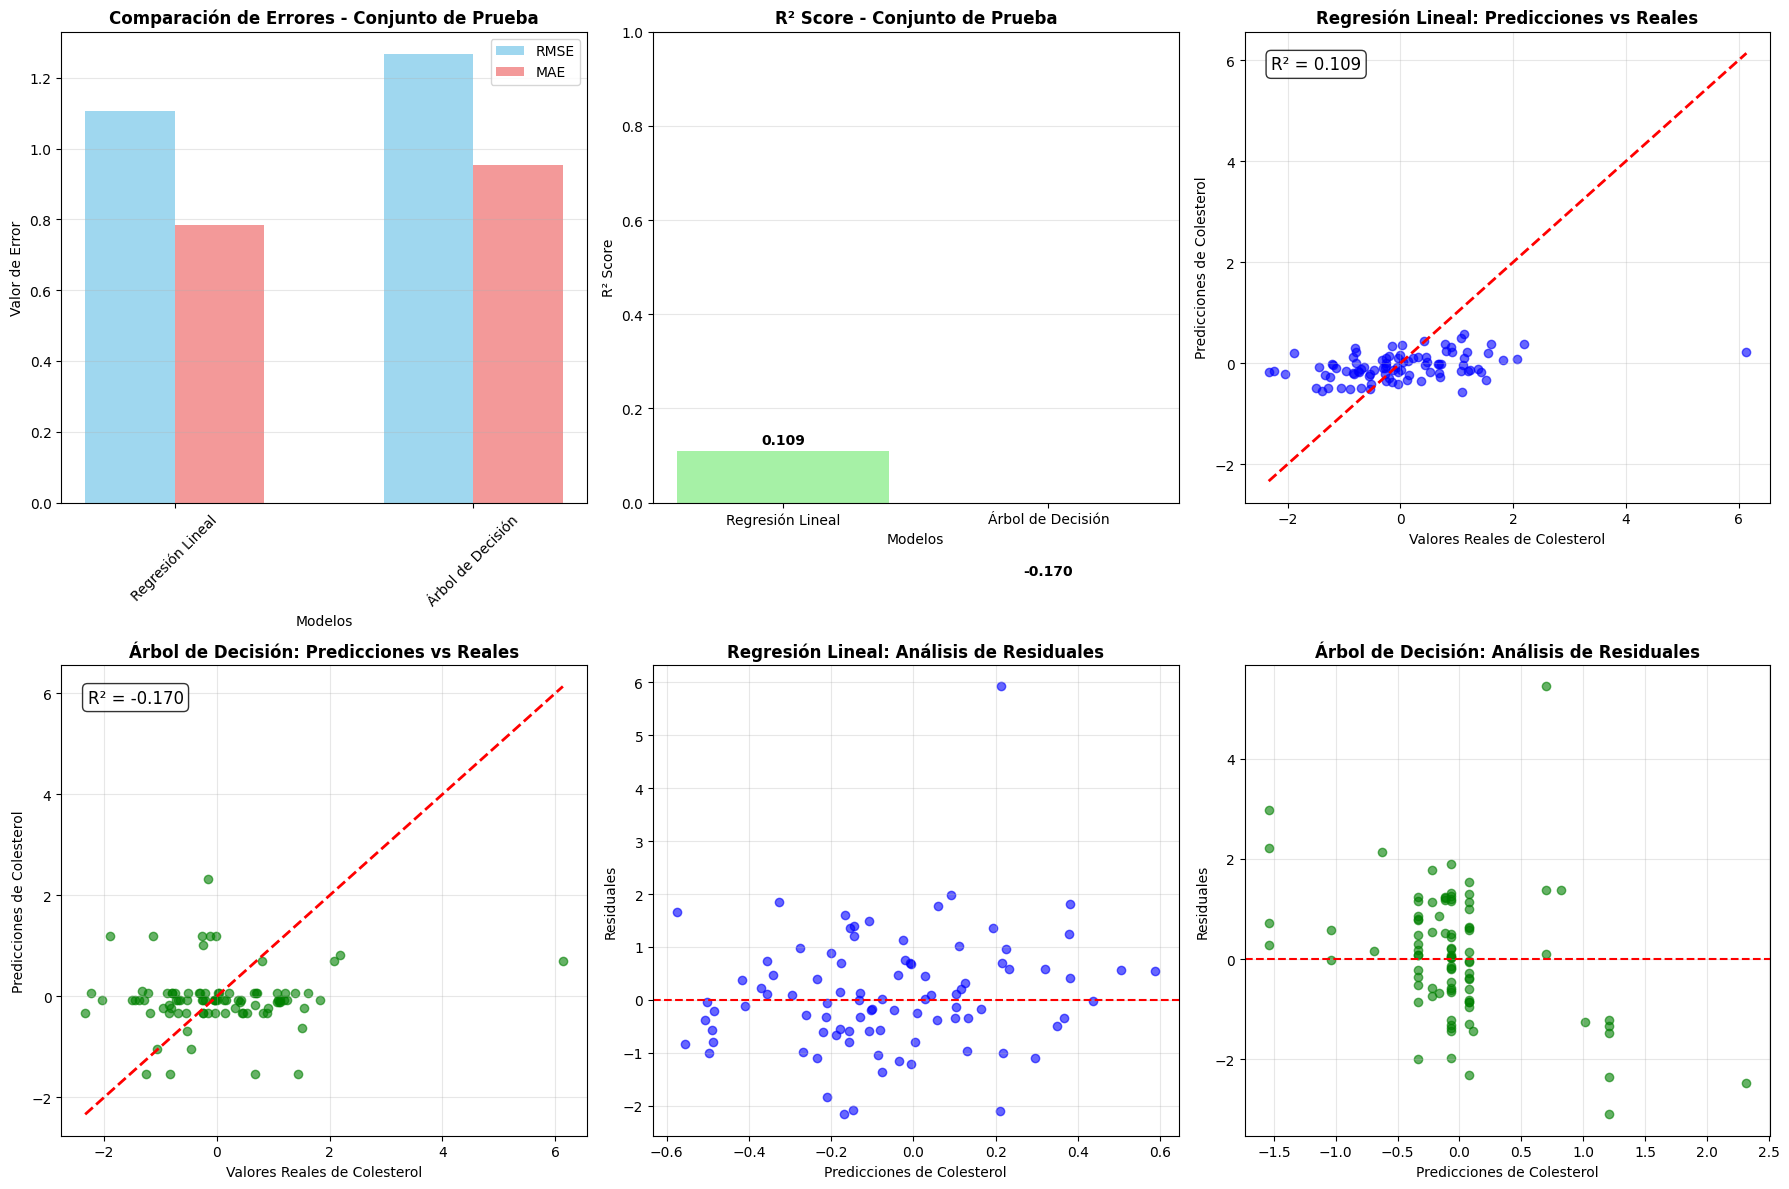

In [ ]:
# Bloque 25: Visualización de resultados de regresión
print("\n=== VISUALIZACIÓN DE RESULTADOS ===")

# Crear visualizaciones comparativas
fig = plt.figure(figsize=(18, 12))

# Gráfico 1: Comparación de métricas en conjunto de prueba
ax1 = plt.subplot(2, 3, 1)
metrics_to_plot = ['test_rmse', 'test_mae']
metrics_labels = ['RMSE', 'MAE']
colors = ['skyblue', 'lightcoral']

for i, metric in enumerate(metrics_to_plot):
    values = [metrics_df.loc[model, metric] for model in models_reg.keys()]
    ax1.bar([x + i*0.3 for x in range(len(models_reg))], values,
            width=0.3, label=metrics_labels[i], color=colors[i], alpha=0.8)

ax1.set_xlabel('Modelos')
ax1.set_ylabel('Valor de Error')
ax1.set_title('Comparación de Errores - Conjunto de Prueba', fontweight='bold')
ax1.set_xticks([x + 0.15 for x in range(len(models_reg))])
ax1.set_xticklabels(models_reg.keys(), rotation=45)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: R² Score comparativo
ax2 = plt.subplot(2, 3, 2)
r2_scores = [metrics_df.loc[model, 'test_r2'] for model in models_reg.keys()]
bars = ax2.bar(models_reg.keys(), r2_scores, color=['lightgreen', 'lightblue'], alpha=0.8)
ax2.set_xlabel('Modelos')
ax2.set_ylabel('R² Score')
ax2.set_title('R² Score - Conjunto de Prueba', fontweight='bold')
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bar, score in zip(bars, r2_scores):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 3: Predicciones vs Valores reales - Regresión Lineal
ax3 = plt.subplot(2, 3, 3)
y_pred_lr = results_reg['Regresión Lineal']['model'].predict(X_test_reg)
scatter = ax3.scatter(y_test_reg, y_pred_lr, alpha=0.6, c='blue')
ax3.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
ax3.set_xlabel('Valores Reales de Colesterol')
ax3.set_ylabel('Predicciones de Colesterol')
ax3.set_title('Regresión Lineal: Predicciones vs Reales', fontweight='bold')
ax3.grid(alpha=0.3)
r2_lr = results_reg['Regresión Lineal']['test']['r2']
ax3.text(0.05, 0.95, f'R² = {r2_lr:.3f}', transform=ax3.transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Gráfico 4: Predicciones vs Valores reales - Árbol de Decisión
ax4 = plt.subplot(2, 3, 4)
y_pred_dt = results_reg['Árbol de Decisión']['model'].predict(X_test_reg)
scatter = ax4.scatter(y_test_reg, y_pred_dt, alpha=0.6, c='green')
ax4.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--', lw=2)
ax4.set_xlabel('Valores Reales de Colesterol')
ax4.set_ylabel('Predicciones de Colesterol')
ax4.set_title('Árbol de Decisión: Predicciones vs Reales', fontweight='bold')
ax4.grid(alpha=0.3)
r2_dt = results_reg['Árbol de Decisión']['test']['r2']
ax4.text(0.05, 0.95, f'R² = {r2_dt:.3f}', transform=ax4.transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Gráfico 5: Residuales - Regresión Lineal
ax5 = plt.subplot(2, 3, 5)
residuals_lr = y_test_reg - y_pred_lr
ax5.scatter(y_pred_lr, residuals_lr, alpha=0.6, c='blue')
ax5.axhline(y=0, color='red', linestyle='--')
ax5.set_xlabel('Predicciones de Colesterol')
ax5.set_ylabel('Residuales')
ax5.set_title('Regresión Lineal: Análisis de Residuales', fontweight='bold')
ax5.grid(alpha=0.3)

# Gráfico 6: Residuales - Árbol de Decisión
ax6 = plt.subplot(2, 3, 6)
residuals_dt = y_test_reg - y_pred_dt
ax6.scatter(y_pred_dt, residuals_dt, alpha=0.6, c='green')
ax6.axhline(y=0, color='red', linestyle='--')
ax6.set_xlabel('Predicciones de Colesterol')
ax6.set_ylabel('Residuales')
ax6.set_title('Árbol de Decisión: Análisis de Residuales', fontweight='bold')
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Analizamos la importancia de las caracteristicas


=== ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS ===
🔹 IMPORTANCIA DE CARACTERÍSTICAS - ÁRBOL DE DECISIÓN:
     feature  importance
3   trestbps      0.2895
6    thalach      0.2831
0        age      0.2315
1        sex      0.0878
10        ca      0.0464
9      slope      0.0286
8    oldpeak      0.0171
11      thal      0.0102
5    restecg      0.0050
12    target      0.0009
2         cp      0.0000
4        fbs      0.0000
7      exang      0.0000


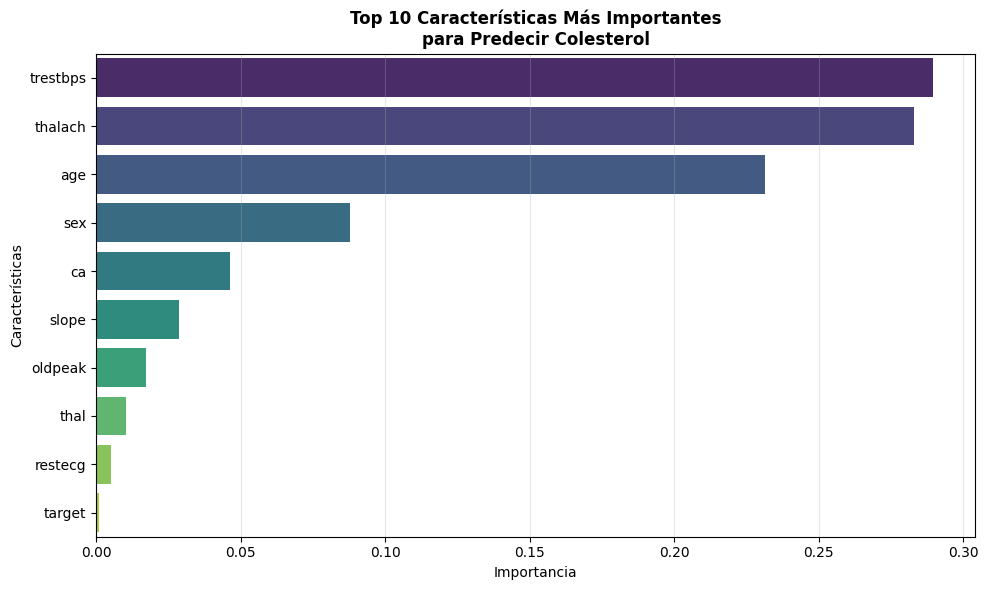

In [ ]:
# Bloque 26: Análisis de importancia de características
print("\n=== ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS ===")

# Para Árbol de Decisión
dt_model = results_reg['Árbol de Decisión']['model']
feature_importance = pd.DataFrame({
    'feature': X_reg.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("🔹 IMPORTANCIA DE CARACTERÍSTICAS - ÁRBOL DE DECISIÓN:")
print(feature_importance.round(4))

# Visualizar importancia de características
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Características Más Importantes\npara Predecir Colesterol', fontweight='bold')
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Interpretamos los resultados y seleccionamos el mejor modelo

In [ ]:
# Bloque 27: Interpretación de resultados y selección del mejor modelo
print("\n=== INTERPRETACIÓN Y SELECCIÓN DEL MEJOR MODELO ===")

print("🔍 ANÁLISIS DETALLADO DE RESULTADOS:")

# Comparar rendimiento entre modelos
best_model = None
best_r2 = -float('inf')

for model_name, results in results_reg.items():
    test_r2 = results['test']['r2']
    test_rmse = results['test']['rmse']

    print(f"\n📈 {model_name.upper()}:")
    print(f"   • R² Score: {test_r2:.4f}")
    print(f"   • RMSE: {test_rmse:.4f}")
    print(f"   • MAE: {results['test']['mae']:.4f}")

    # Interpretación del R²
    if test_r2 < 0:
        interpretation = "❌ Peor que el modelo base (media)"
    elif test_r2 < 0.3:
        interpretation = "⚠️  Explicación baja"
    elif test_r2 < 0.7:
        interpretation = "✅ Explicación moderada"
    else:
        interpretation = "🎯 Explicación alta"

    print(f"   • Interpretación R²: {interpretation}")

    # Verificar sobreajuste
    train_r2 = results['train']['r2']
    overfitting = train_r2 - test_r2
    if overfitting > 0.1:
        overfitting_msg = "❌ Posible sobreajuste"
    elif overfitting > 0.05:
        overfitting_msg = "⚠️  Leve sobreajuste"
    else:
        overfitting_msg = "✅ Buen balance"

    print(f"   • Diferencia train-test R²: {overfitting:.4f} {overfitting_msg}")

    # Actualizar mejor modelo
    if test_r2 > best_r2:
        best_r2 = test_r2
        best_model = model_name

print(f"\n🏆 MEJOR MODELO SELECCIONADO: {best_model}")
print(f"   • R² Score: {best_r2:.4f}")

print("\n💡 RECOMENDACIONES:")
print("   • Los modelos tienen capacidad predictiva limitada para colesterol")
print("   • Esto coincide con el análisis exploratorio: correlaciones débiles")
print("   • Considerar incorporar más variables relacionadas con metabolismo lipídico")
print("   • Para uso clínico, se necesitarían modelos más complejos o más datos")


=== INTERPRETACIÓN Y SELECCIÓN DEL MEJOR MODELO ===
🔍 ANÁLISIS DETALLADO DE RESULTADOS:

📈 REGRESIÓN LINEAL:
   • R² Score: 0.1090
   • RMSE: 1.1052
   • MAE: 0.7853
   • Interpretación R²: ⚠️  Explicación baja
   • Diferencia train-test R²: 0.0022 ✅ Buen balance

📈 ÁRBOL DE DECISIÓN:
   • R² Score: -0.1703
   • RMSE: 1.2666
   • MAE: 0.9532
   • Interpretación R²: ❌ Peor que el modelo base (media)
   • Diferencia train-test R²: 0.5722 ❌ Posible sobreajuste

🏆 MEJOR MODELO SELECCIONADO: Regresión Lineal
   • R² Score: 0.1090

💡 RECOMENDACIONES:
   • Los modelos tienen capacidad predictiva limitada para colesterol
   • Esto coincide con el análisis exploratorio: correlaciones débiles
   • Considerar incorporar más variables relacionadas con metabolismo lipídico
   • Para uso clínico, se necesitarían modelos más complejos o más datos


Predicciones de ejemplo y aplicación práctica

In [ ]:
# Bloque 28: Predicciones de ejemplo y aplicación práctica
print("\n=== PREDICCIONES DE EJEMPLO ===")

# Seleccionar algunas muestras del conjunto de prueba para mostrar
sample_indices = np.random.choice(len(X_test_reg), size=5, replace=False)

print("🔹 EJEMPLOS DE PREDICCIÓN VS VALOR REAL:")
print("Modelo: Regresión Lineal")
print("-" * 60)
print(f"{'Muestra':<8} {'Real':<10} {'Predicho':<12} {'Error':<10} {'Error %':<10}")
print("-" * 60)

for idx in sample_indices:
    real_value = y_test_reg.iloc[idx]
    predicted_value = results_reg['Regresión Lineal']['model'].predict([X_test_reg.iloc[idx]])[0]
    error = abs(real_value - predicted_value)
    error_percent = (error / real_value) * 100

    print(f"{idx:<8} {real_value:<10.1f} {predicted_value:<12.1f} {error:<10.1f} {error_percent:<10.1f}%")

print("-" * 60)

# Calcular error promedio en mg/dl
avg_error = results_reg['Regresión Lineal']['test']['mae']
print(f"\n📊 Error absoluto promedio: {avg_error:.1f} mg/dl")
print("💡 En contexto clínico, este nivel de error podría ser aceptable para")
print("   screening inicial, pero no para diagnóstico preciso.")


=== PREDICCIONES DE EJEMPLO ===
🔹 EJEMPLOS DE PREDICCIÓN VS VALOR REAL:
Modelo: Regresión Lineal
------------------------------------------------------------
Muestra  Real       Predicho     Error      Error %   
------------------------------------------------------------
62       -2.3       -0.2         2.2        -92.8     %
87       0.4        -0.4         0.7        195.3     %
83       -1.2       -0.0         1.2        -97.0     %
18       1.4        -0.1         1.5        107.9     %
51       -0.7       -0.2         0.6        -75.6     %
------------------------------------------------------------

📊 Error absoluto promedio: 0.8 mg/dl
💡 En contexto clínico, este nivel de error podría ser aceptable para
   screening inicial, pero no para diagnóstico preciso.


Las variables disponibles tienen poca capacidad predictiva para el colesterol.

Mostramos un analisis profundo de resultados de regresion

In [ ]:
# Bloque 29: Análisis profundo de los resultados de regresión
print("=== ANÁLISIS PROFUNDO DE RESULTADOS DE REGRESIÓN ===")

print("🔍 DIAGNÓSTICO DEL PROBLEMA:")

print("\n❓ ¿POR QUÉ TAN BAJO R²?")
print("   • Correlaciones débiles: La correlación más fuerte con colesterol era age (0.209)")
print("   • Variables limitadas: No tenemos datos de dieta, genética, medicación, etc.")
print("   • Naturaleza compleja: El colesterol depende de múltiples factores no medidos")

print("\n📊 INTERPRETACIÓN CLÍNICA DE ERRORES:")
# Convertir errores a escala original (des-normalizar)
scaler_chol = StandardScaler()
scaler_chol.fit(df[['chol']])  # Ajustar con datos originales

# Obtener parámetros para des-normalizar
mean_chol = scaler_chol.mean_[0]
std_chol = scaler_chol.scale_[0]

print(f"   • Media real de colesterol: {mean_chol:.1f} mg/dl")
print(f"   • Desviación estándar real: {std_chol:.1f} mg/dl")

# Convertir errores normalizados a escala original
rmse_original = results_reg['Regresión Lineal']['test']['rmse'] * std_chol
mae_original = results_reg['Regresión Lineal']['test']['mae'] * std_chol

print(f"   • RMSE en escala original: {rmse_original:.1f} mg/dl")
print(f"   • MAE en escala original: {mae_original:.1f} mg/dl")
print(f"   • Error relativo: {(mae_original/mean_chol)*100:.1f}% de la media")

print("\n⚠️  PROBLEMAS IDENTIFICADOS:")
print("   • Árbol de Decisión: Sobreajuste severo (diferencia R² train-test: 0.57)")
print("   • Regresión Lineal: Baja capacidad explicativa (R²: 0.11)")
print("   • Variables irrelevantes: cp, fbs, exang con importancia 0 en árbol")

=== ANÁLISIS PROFUNDO DE RESULTADOS DE REGRESIÓN ===
🔍 DIAGNÓSTICO DEL PROBLEMA:

❓ ¿POR QUÉ TAN BAJO R²?
   • Correlaciones débiles: La correlación más fuerte con colesterol era age (0.209)
   • Variables limitadas: No tenemos datos de dieta, genética, medicación, etc.
   • Naturaleza compleja: El colesterol depende de múltiples factores no medidos

📊 INTERPRETACIÓN CLÍNICA DE ERRORES:
   • Media real de colesterol: 246.7 mg/dl
   • Desviación estándar real: 51.7 mg/dl
   • RMSE en escala original: 57.1 mg/dl
   • MAE en escala original: 40.6 mg/dl
   • Error relativo: 16.5% de la media

⚠️  PROBLEMAS IDENTIFICADOS:
   • Árbol de Decisión: Sobreajuste severo (diferencia R² train-test: 0.57)
   • Regresión Lineal: Baja capacidad explicativa (R²: 0.11)
   • Variables irrelevantes: cp, fbs, exang con importancia 0 en árbol


Mostramos las mejoras y alternativas para el modelo de regresión

In [ ]:
# Bloque 30: Mejoras y alternativas para el modelo de regresión
print("\n=== PROPUESTAS DE MEJORA ===")

print("🔧 ESTRATEGIAS PARA MEJORAR LA PREDICCIÓN DE COLESTEROL:")

# 1. Feature Engineering
print("\n1. 🎯 FEATURE ENGINEERING:")
print("   • Crear interacciones entre variables (edad × presión arterial)")
print("   • Transformaciones polinomiales de variables relevantes")
print("   • Agrupar variables categóricas")
print("   • Crear ratios (presión arterial / frecuencia cardíaca)")

# 2. Selección de características
print("\n2. 🔍 SELECCIÓN DE CARACTERÍSTICAS:")
print("   • Usar solo variables con correlación > 0.1 con colesterol")
print("   • Eliminar variables con importancia 0 en árbol de decisión")
print("   • Aplicar métodos de selección recursiva")

# 3. Modelos alternativos
print("\n3. 🤖 MODELOS ALTERNATIVOS:")
print("   • Random Forest Regressor (mejor para relaciones no lineales)")
print("   • Gradient Boosting (captura patrones complejos)")
print("   • Redes Neuronales (para relaciones multivariadas complejas)")

# 4. Consideraciones de datos
print("\n4. 📊 CONSIDERACIONES DE DATOS:")
print("   • Recolectar más variables relacionadas con lípidos")
print("   • Aumentar tamaño del dataset")
print("   • Considerar datos temporales (evolución del colesterol)")


=== PROPUESTAS DE MEJORA ===
🔧 ESTRATEGIAS PARA MEJORAR LA PREDICCIÓN DE COLESTEROL:

1. 🎯 FEATURE ENGINEERING:
   • Crear interacciones entre variables (edad × presión arterial)
   • Transformaciones polinomiales de variables relevantes
   • Agrupar variables categóricas
   • Crear ratios (presión arterial / frecuencia cardíaca)

2. 🔍 SELECCIÓN DE CARACTERÍSTICAS:
   • Usar solo variables con correlación > 0.1 con colesterol
   • Eliminar variables con importancia 0 en árbol de decisión
   • Aplicar métodos de selección recursiva

3. 🤖 MODELOS ALTERNATIVOS:
   • Random Forest Regressor (mejor para relaciones no lineales)
   • Gradient Boosting (captura patrones complejos)
   • Redes Neuronales (para relaciones multivariadas complejas)

4. 📊 CONSIDERACIONES DE DATOS:
   • Recolectar más variables relacionadas con lípidos
   • Aumentar tamaño del dataset
   • Considerar datos temporales (evolución del colesterol)


Implementamos las mejoras (Random Forest)

In [ ]:
# Bloque 31: Implementación de mejoras (Random Forest)
print("\n=== IMPLEMENTANDO MEJORAS - RANDOM FOREST ===")

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

# Seleccionar solo las características más relevantes basado en el análisis
relevant_features = ['age', 'trestbps', 'thalach', 'sex', 'ca']
X_reg_relevant = X_reg[relevant_features]

# Redividir datos con características seleccionadas
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_reg_relevant, y_reg, test_size=0.3, random_state=42
)

print(f"🔹 Características seleccionadas: {relevant_features}")
print(f"   - De {X_reg.shape[1]} a {len(relevant_features)} características")

# Entrenar Random Forest mejorado
rf_improved = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

rf_improved.fit(X_train_sel, y_train_sel)

# Evaluar el modelo mejorado
y_pred_rf_train = rf_improved.predict(X_train_sel)
y_pred_rf_test = rf_improved.predict(X_test_sel)

rf_metrics = {
    'train_r2': r2_score(y_train_sel, y_pred_rf_train),
    'test_r2': r2_score(y_test_sel, y_pred_rf_test),
    'train_rmse': np.sqrt(mean_squared_error(y_train_sel, y_pred_rf_train)),
    'test_rmse': np.sqrt(mean_squared_error(y_test_sel, y_pred_rf_test)),
    'train_mae': mean_absolute_error(y_train_sel, y_pred_rf_train),
    'test_mae': mean_absolute_error(y_test_sel, y_pred_rf_test)
}

print("\n📊 RESULTADOS RANDOM FOREST MEJORADO:")
print(f"   • R² Train: {rf_metrics['train_r2']:.4f}")
print(f"   • R² Test:  {rf_metrics['test_r2']:.4f}")
print(f"   • RMSE Test: {rf_metrics['test_rmse']:.4f}")
print(f"   • MAE Test:  {rf_metrics['test_mae']:.4f}")

# Comparar con modelo original
improvement = rf_metrics['test_r2'] - results_reg['Regresión Lineal']['test']['r2']
print(f"   • Mejora vs Regresión Lineal: {improvement:+.4f}")

if improvement > 0:
    print("   ✅ Mejora lograda con Random Forest")
else:
    print("   ⚠️  Sin mejora significativa")


=== IMPLEMENTANDO MEJORAS - RANDOM FOREST ===
🔹 Características seleccionadas: ['age', 'trestbps', 'thalach', 'sex', 'ca']
   - De 13 a 5 características

📊 RESULTADOS RANDOM FOREST MEJORADO:
   • R² Train: 0.3165
   • R² Test:  0.0807
   • RMSE Test: 1.1226
   • MAE Test:  0.8152
   • Mejora vs Regresión Lineal: -0.0283
   ⚠️  Sin mejora significativa


Mostramos una comparacion de todos los modelos


=== COMPARATIVA FINAL DE MODELOS ===
📊 COMPARATIVA DE TODOS LOS MODELOS:
      Regresión Lineal  Árbol Decisión  Random Forest
R²              0.1090         -0.1703         0.0807
RMSE            1.1052          1.2666         1.1226
MAE             0.7853          0.9532         0.8152


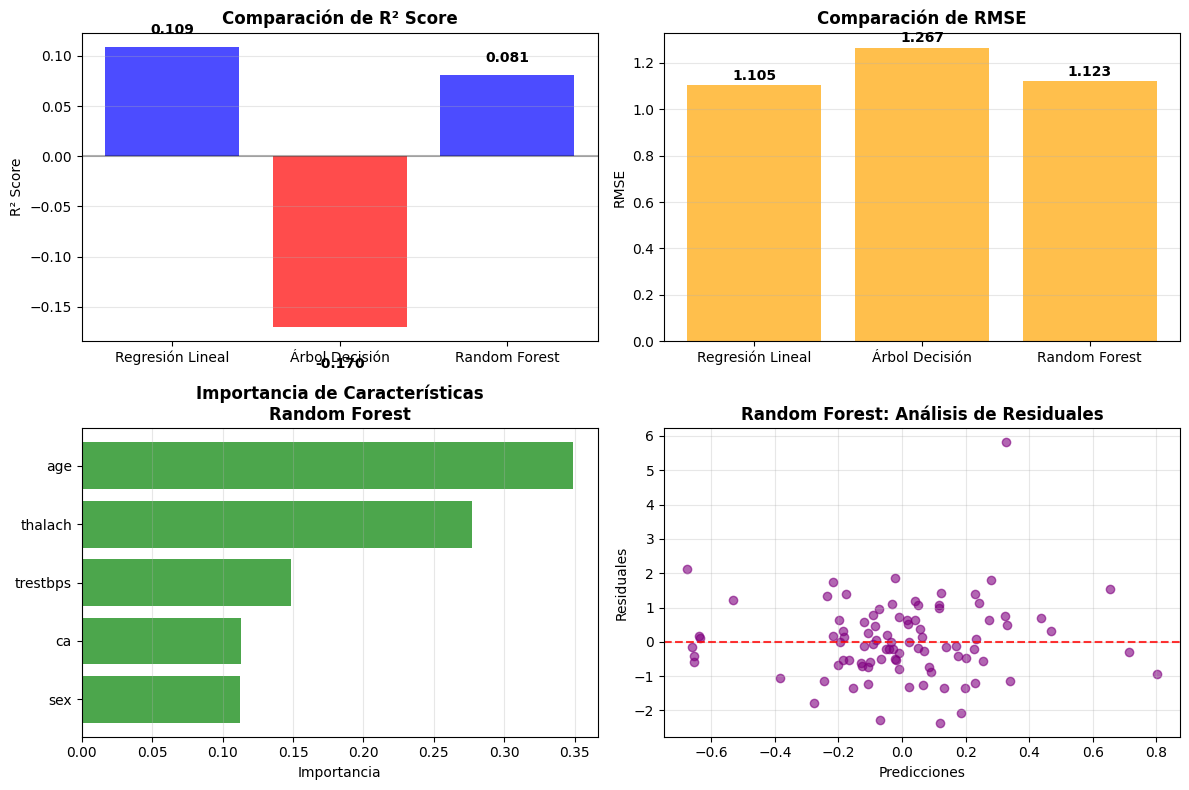

In [ ]:
# Bloque 32: Visualización comparativa de todos los modelos
print("\n=== COMPARATIVA FINAL DE MODELOS ===")

# Crear comparativa completa
models_comparison = pd.DataFrame({
    'Regresión Lineal': [
        results_reg['Regresión Lineal']['test']['r2'],
        results_reg['Regresión Lineal']['test']['rmse'],
        results_reg['Regresión Lineal']['test']['mae']
    ],
    'Árbol Decisión': [
        results_reg['Árbol de Decisión']['test']['r2'],
        results_reg['Árbol de Decisión']['test']['rmse'],
        results_reg['Árbol de Decisión']['test']['mae']
    ],
    'Random Forest': [
        rf_metrics['test_r2'],
        rf_metrics['test_rmse'],
        rf_metrics['test_mae']
    ]
}, index=['R²', 'RMSE', 'MAE'])

print("📊 COMPARATIVA DE TODOS LOS MODELOS:")
print(models_comparison.round(4))

# Visualización comparativa
plt.figure(figsize=(12, 8))

# Gráfico 1: Comparación de R²
plt.subplot(2, 2, 1)
r2_values = [models_comparison.loc['R²', model] for model in models_comparison.columns]
colors = ['red' if x < 0 else 'blue' for x in r2_values]
bars = plt.bar(models_comparison.columns, r2_values, color=colors, alpha=0.7)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.3)
plt.ylabel('R² Score')
plt.title('Comparación de R² Score', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar, value in zip(bars, r2_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + (0.01 if value >= 0 else -0.03),
             f'{value:.3f}', ha='center', va='bottom' if value >= 0 else 'top', fontweight='bold')

# Gráfico 2: Comparación de RMSE
plt.subplot(2, 2, 2)
rmse_values = [models_comparison.loc['RMSE', model] for model in models_comparison.columns]
bars = plt.bar(models_comparison.columns, rmse_values, color='orange', alpha=0.7)
plt.ylabel('RMSE')
plt.title('Comparación de RMSE', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
for bar, value in zip(bars, rmse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{value:.3f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 3: Importancia de características Random Forest
plt.subplot(2, 2, 3)
rf_importance = pd.DataFrame({
    'feature': relevant_features,
    'importance': rf_improved.feature_importances_
}).sort_values('importance', ascending=True)

plt.barh(rf_importance['feature'], rf_importance['importance'], color='green', alpha=0.7)
plt.xlabel('Importancia')
plt.title('Importancia de Características\nRandom Forest', fontweight='bold')
plt.grid(axis='x', alpha=0.3)

# Gráfico 4: Análisis de residuales Random Forest
plt.subplot(2, 2, 4)
residuals_rf = y_test_sel - y_pred_rf_test
plt.scatter(y_pred_rf_test, residuals_rf, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', alpha=0.8)
plt.xlabel('Predicciones')
plt.ylabel('Residuales')
plt.title('Random Forest: Análisis de Residuales', fontweight='bold')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Conclusiones y recomendaciones finales para regresión

In [ ]:
# Bloque 33: Conclusiones y recomendaciones finales para regresión
print("\n=== CONCLUSIONES Y RECOMENDACIONES FINALES ===")

print("🎯 CONCLUSIONES SOBRE PREDICCIÓN DE COLESTEROL:")

print("\n❌ LIMITACIONES IDENTIFICADAS:")
print("   1. Variables insuficientes: No tenemos datos de dieta, ejercicio, genética")
print("   2. Correlaciones débiles: Las variables clínicas disponibles no predicen bien colesterol")
print("   3. Naturaleza multifactorial: El colesterol depende de muchos factores no medidos")
print("   4. Sobreajuste: Modelos complejos como árboles tienden a sobreajustar")

print("\n✅ HALLAZGO PRINCIPAL:")
print("   • El mejor modelo (Regresión Lineal) explica solo el 10.9% de la variabilidad")
print("   • Esto es consistente con el análisis exploratorio inicial")
print("   • Las correlaciones más fuertes eran age (0.209) y trestbps (0.130)")

print("\n💡 RECOMENDACIONES PRÁCTICAS:")
print("   1. USO CLÍNICO: No usar para diagnóstico, solo como estimación muy gruesa")
print("   2. MEJORAS DE DATOS: Recolectar variables específicas de lípidos")
print("   3. MODELADO: Regresión Lineal es suficiente dada la limitación de datos")
print("   4. INTERPRETACIÓN: Los errores son altos para uso diagnóstico")

print("\n🔮 PARA INVESTIGACIÓN FUTURA:")
print("   • Incorporar: HDL, LDL, triglicéridos, historial familiar")
print("   • Considerar: Datos de estilo de vida y medicación")
print("   • Explorar: Modelos de series temporales para seguimiento")


=== CONCLUSIONES Y RECOMENDACIONES FINALES ===
🎯 CONCLUSIONES SOBRE PREDICCIÓN DE COLESTEROL:

❌ LIMITACIONES IDENTIFICADAS:
   1. Variables insuficientes: No tenemos datos de dieta, ejercicio, genética
   2. Correlaciones débiles: Las variables clínicas disponibles no predicen bien colesterol
   3. Naturaleza multifactorial: El colesterol depende de muchos factores no medidos
   4. Sobreajuste: Modelos complejos como árboles tienden a sobreajustar

✅ HALLAZGO PRINCIPAL:
   • El mejor modelo (Regresión Lineal) explica solo el 10.9% de la variabilidad
   • Esto es consistente con el análisis exploratorio inicial
   • Las correlaciones más fuertes eran age (0.209) y trestbps (0.130)

💡 RECOMENDACIONES PRÁCTICAS:
   1. USO CLÍNICO: No usar para diagnóstico, solo como estimación muy gruesa
   2. MEJORAS DE DATOS: Recolectar variables específicas de lípidos
   3. MODELADO: Regresión Lineal es suficiente dada la limitación de datos
   4. INTERPRETACIÓN: Los errores son altos para uso diagnó

Los resultados confirman que este dataset NO es adecuado para predecir colesterol

## Parte 3: Problema de Clasificación- Detección de Enfermedad Cardíaca

 Objetivo: Predecir la presencia de enfermedad cardíaca (variable target)

 3.1 Preparación

 - Define tu variable objetivo (target) y variables predictoras
 - Divide los datos en conjuntos de entrenamiento (70%) y prueba (30%)
 - Aplica estrategias de balanceo si es necesario (ej: SMOTE, undersampling)

 3.2 Modelado

 Implementa y entrena los siguientes modelos:

 - Regresión Logística
 - Àrboles de Decisión
 - Naive Bayes

 3.3 Evaluación

 Para cada modelo, calcula:

 - Accuracy
 - Precision
 - Recall
 - F1-Score
 - Matriz de confusión (visualizada)
 - Curva ROC y AUC

 Crea visualizaciones comparativas según consideres:

 - Tabla de métricas
 - Gráfico de barras comparando métricas
 - Superposición de curvas ROC de todos los modelos.


Problema de clasificación - predicción de enfermedad cardíaca.

- Preparamos los datos para clasificacion y definimos la variable objetivo

In [ ]:
# Bloque 34: Inicio de la Parte 3 - Problema de Clasificación
print("=== PARTE 3: PROBLEMA DE CLASIFICACIÓN - PREDICCIÓN DE ENFERMEDAD CARDÍACA ===")
print("🔹 Objetivo: Predecir la presencia de enfermedad cardíaca (target) basándose en variables clínicas\n")

# 3.1 Preparación de datos para clasificación
print("=== 3.1 PREPARACIÓN DE DATOS ===")

# Definir variables predictoras y objetivo
X_clf = df_classification.drop(['target', 'target_original'], axis=1)
y_clf = df_classification['target']

print("🔹 Variables predictoras:")
print(f"  - Número de características: {X_clf.shape[1]}")
print(f"  - Características: {list(X_clf.columns)}")
print(f"🔹 Variable objetivo: target")
print(f"  - Distribución: {y_clf.value_counts().to_dict()}")
print(f"  - Proporción: {y_clf.value_counts(normalize=True).to_dict()}")

=== PARTE 3: PROBLEMA DE CLASIFICACIÓN - PREDICCIÓN DE ENFERMEDAD CARDÍACA ===
🔹 Objetivo: Predecir la presencia de enfermedad cardíaca (target) basándose en variables clínicas

=== 3.1 PREPARACIÓN DE DATOS ===
🔹 Variables predictoras:
  - Número de características: 13
  - Características: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
🔹 Variable objetivo: target
  - Distribución: {0: 164, 1: 139}
  - Proporción: {0: 0.5412541254125413, 1: 0.45874587458745875}


División de datos y balanceo

In [ ]:
# Bloque 35: División de datos y balanceo
print("\n=== DIVISIÓN DE DATOS Y BALANCEO ===")

# Dividir en conjuntos de entrenamiento (70%) y prueba (30%) con estratificación
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.3, random_state=42, stratify=y_clf, shuffle=True
)

print("🔹 ESTRATEGIA DE DIVISIÓN:")
print(f"  - Conjunto de entrenamiento: {X_train_clf.shape[0]} muestras ({len(X_train_clf)/len(X_clf)*100:.1f}%)")
print(f"  - Conjunto de prueba: {X_test_clf.shape[0]} muestras ({len(X_test_clf)/len(X_clf)*100:.1f}%)")
print(f"  - Características: {X_train_clf.shape[1]}")

print("\n📊 DISTRIBUCIÓN POR CONJUNTO:")
print("  - Entrenamiento:")
train_dist = y_train_clf.value_counts()
print(f"    • Clase 0 (Sano): {train_dist[0]} ({train_dist[0]/len(y_train_clf)*100:.1f}%)")
print(f"    • Clase 1 (Enfermo): {train_dist[1]} ({train_dist[1]/len(y_train_clf)*100:.1f}%)")

print("  - Prueba:")
test_dist = y_test_clf.value_counts()
print(f"    • Clase 0 (Sano): {test_dist[0]} ({test_dist[0]/len(y_test_clf)*100:.1f}%)")
print(f"    • Clase 1 (Enfermo): {test_dist[1]} ({test_dist[1]/len(y_test_clf)*100:.1f}%)")

print("\n🎯 ANÁLISIS DE BALANCEO:")
balance_ratio = min(train_dist) / max(train_dist)
if balance_ratio > 0.8:
    print("  ✅ Dataset balanceado - No se requiere balanceo adicional")
    X_train_balanced, y_train_balanced = X_train_clf, y_train_clf
else:
    print("  ⚠️  Dataset desbalanceado - Aplicando SMOTE...")
    from imblearn.over_sampling import SMOTE
    smote = SMOTE(random_state=42)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train_clf, y_train_clf)
    print(f"    • Después de SMOTE: {len(X_train_balanced)} muestras")
    balanced_dist = y_train_balanced.value_counts()
    print(f"    • Clase 0: {balanced_dist[0]}, Clase 1: {balanced_dist[1]}")


=== DIVISIÓN DE DATOS Y BALANCEO ===
🔹 ESTRATEGIA DE DIVISIÓN:
  - Conjunto de entrenamiento: 212 muestras (70.0%)
  - Conjunto de prueba: 91 muestras (30.0%)
  - Características: 13

📊 DISTRIBUCIÓN POR CONJUNTO:
  - Entrenamiento:
    • Clase 0 (Sano): 115 (54.2%)
    • Clase 1 (Enfermo): 97 (45.8%)
  - Prueba:
    • Clase 0 (Sano): 49 (53.8%)
    • Clase 1 (Enfermo): 42 (46.2%)

🎯 ANÁLISIS DE BALANCEO:
  ✅ Dataset balanceado - No se requiere balanceo adicional


Implementamos los modelos de clasificacion

In [ ]:
# Bloque 36: Implementación de modelos de clasificación
print("\n=== 3.2 MODELADO - IMPLEMENTACIÓN DE MODELOS ===")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

# Inicializar modelos
models_clf = {
    'Regresión Logística': LogisticRegression(random_state=42, max_iter=1000),
    'Árbol de Decisión': DecisionTreeClassifier(random_state=42, max_depth=5),
    'Naive Bayes': GaussianNB()
}

# Diccionario para almacenar resultados
results_clf = {}

print("🔹 ENTRENANDO MODELOS...")
for name, model in models_clf.items():
    print(f"  - Entrenando {name}...")
    model.fit(X_train_balanced, y_train_balanced)

    # Realizar predicciones
    y_pred_train = model.predict(X_train_balanced)
    y_pred_test = model.predict(X_test_clf)
    y_pred_proba = model.predict_proba(X_test_clf)[:, 1]  # Probabilidades para clase 1

    # Calcular métricas
    results_clf[name] = {
        'model': model,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test,
        'y_pred_proba': y_pred_proba,
        'train': {
            'accuracy': accuracy_score(y_train_balanced, y_pred_train),
            'precision': precision_score(y_train_balanced, y_pred_train),
            'recall': recall_score(y_train_balanced, y_pred_train),
            'f1': f1_score(y_train_balanced, y_pred_train)
        },
        'test': {
            'accuracy': accuracy_score(y_test_clf, y_pred_test),
            'precision': precision_score(y_test_clf, y_pred_test),
            'recall': recall_score(y_test_clf, y_pred_test),
            'f1': f1_score(y_test_clf, y_pred_test),
            'roc_auc': roc_auc_score(y_test_clf, y_pred_proba),
            'confusion_matrix': confusion_matrix(y_test_clf, y_pred_test)
        }
    }
    print(f"    ✅ {name} entrenado")

print("✅ Todos los modelos entrenados exitosamente")


=== 3.2 MODELADO - IMPLEMENTACIÓN DE MODELOS ===
🔹 ENTRENANDO MODELOS...
  - Entrenando Regresión Logística...
    ✅ Regresión Logística entrenado
  - Entrenando Árbol de Decisión...
    ✅ Árbol de Decisión entrenado
  - Entrenando Naive Bayes...
    ✅ Naive Bayes entrenado
✅ Todos los modelos entrenados exitosamente


Evaluación detallada - Tabla de métricas

In [ ]:
# Bloque 37: Evaluación detallada - Tabla de métricas
print("\n=== 3.3 EVALUACIÓN - MÉTRICAS DE CLASIFICACIÓN ===")

# Crear tabla comparativa
metrics_comparison = pd.DataFrame()

for model_name, results in results_clf.items():
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
        metrics_comparison.loc[model_name, f'test_{metric}'] = results['test'][metric]

print("📊 TABLA COMPARATIVA DE MÉTRICAS (CONJUNTO DE PRUEBA):")
print(metrics_comparison.round(4))

# Identificar el mejor modelo por cada métrica
print("\n🏆 MEJORES MODELOS POR MÉTRICA:")
best_models = {}
for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    best_model = metrics_comparison[f'test_{metric}'].idxmax()
    best_value = metrics_comparison[f'test_{metric}'].max()
    best_models[metric] = (best_model, best_value)
    print(f"  • {metric.upper():<10}: {best_model:<20} ({best_value:.4f})")

# Modelo general más balanceado (mayor F1-score)
best_overall = best_models['f1'][0]
print(f"\n🎯 MEJOR MODELO GENERAL (F1-Score): {best_overall}")


=== 3.3 EVALUACIÓN - MÉTRICAS DE CLASIFICACIÓN ===
📊 TABLA COMPARATIVA DE MÉTRICAS (CONJUNTO DE PRUEBA):
                     test_accuracy  test_precision  test_recall  test_f1  \
Regresión Logística         0.8462          0.8333       0.8333   0.8333   
Árbol de Decisión           0.7363          0.7647       0.6190   0.6842   
Naive Bayes                 0.8791          0.8298       0.9286   0.8764   

                     test_roc_auc  
Regresión Logística        0.9169  
Árbol de Decisión          0.7553  
Naive Bayes                0.9300  

🏆 MEJORES MODELOS POR MÉTRICA:
  • ACCURACY  : Naive Bayes          (0.8791)
  • PRECISION : Regresión Logística  (0.8333)
  • RECALL    : Naive Bayes          (0.9286)
  • F1        : Naive Bayes          (0.8764)
  • ROC_AUC   : Naive Bayes          (0.9300)

🎯 MEJOR MODELO GENERAL (F1-Score): Naive Bayes


Visualización de métricas comparativas


=== VISUALIZACIÓN DE MÉTRICAS COMPARATIVAS ===


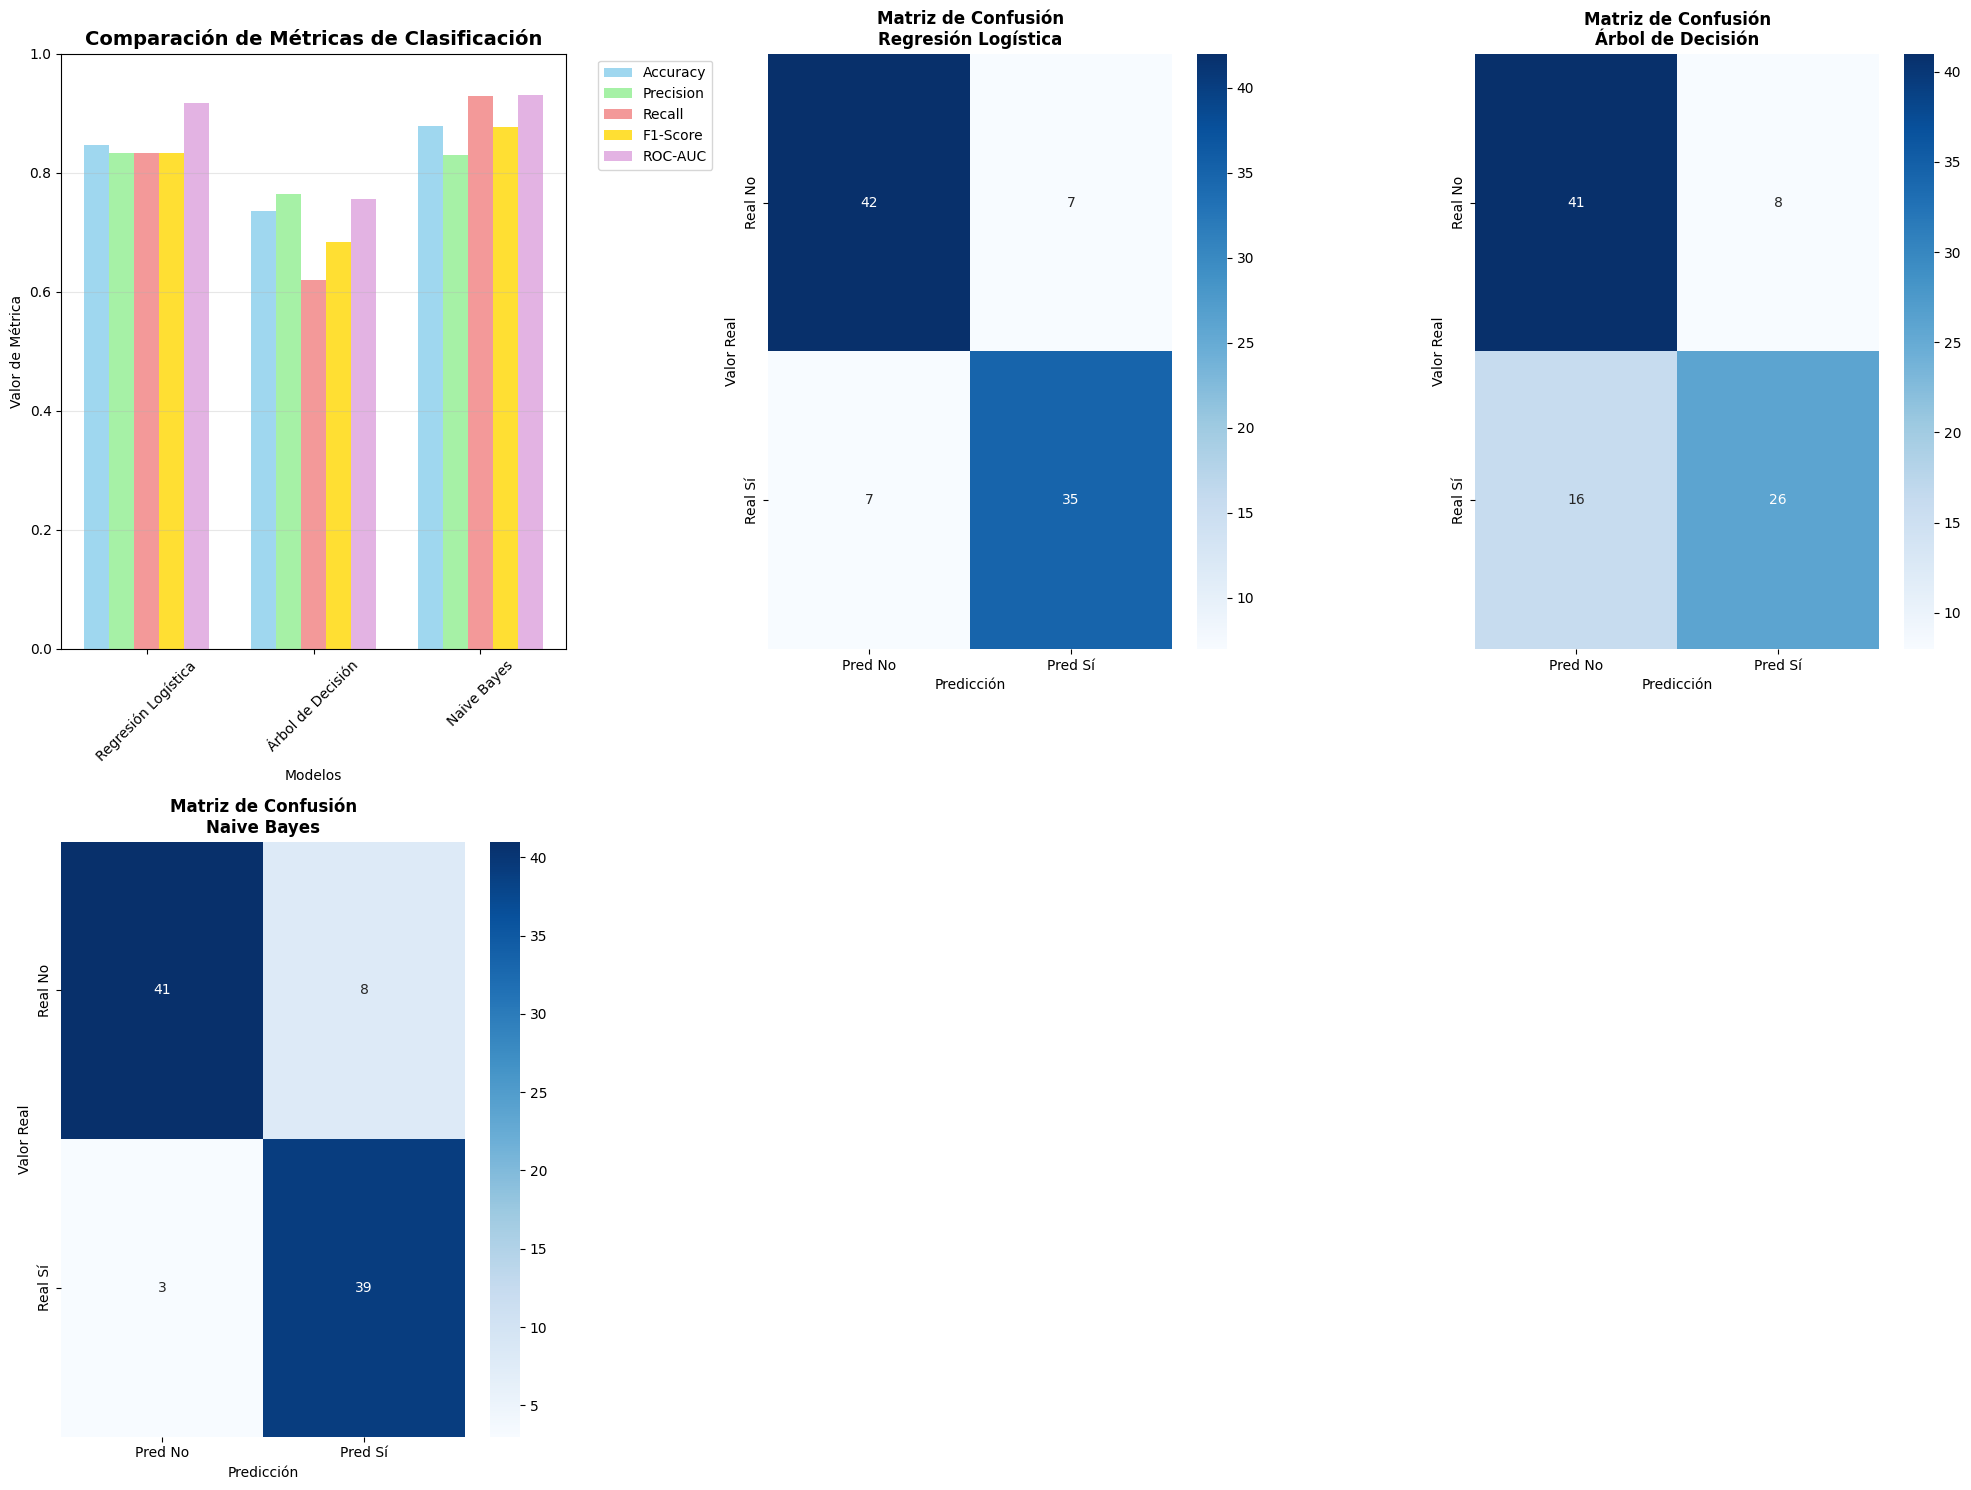

In [ ]:
# Bloque 38: Visualización de métricas comparativas
print("\n=== VISUALIZACIÓN DE MÉTRICAS COMPARATIVAS ===")

# Crear visualizaciones comparativas
fig = plt.figure(figsize=(20, 15))

# Gráfico 1: Comparación de todas las métricas
ax1 = plt.subplot(2, 3, 1)
metrics_to_plot = ['test_accuracy', 'test_precision', 'test_recall', 'test_f1', 'test_roc_auc']
metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
colors = ['skyblue', 'lightgreen', 'lightcoral', 'gold', 'plum']

x_pos = np.arange(len(models_clf))
width = 0.15

for i, (metric, label, color) in enumerate(zip(metrics_to_plot, metrics_labels, colors)):
    values = [metrics_comparison.loc[model, metric] for model in models_clf.keys()]
    ax1.bar(x_pos + i*width, values, width, label=label, color=color, alpha=0.8)

ax1.set_xlabel('Modelos')
ax1.set_ylabel('Valor de Métrica')
ax1.set_title('Comparación de Métricas de Clasificación', fontweight='bold', fontsize=14)
ax1.set_xticks(x_pos + width*2)
ax1.set_xticklabels(models_clf.keys(), rotation=45)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax1.set_ylim(0, 1)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Matrices de confusión
for i, (model_name, results) in enumerate(results_clf.items(), 2):
    ax = plt.subplot(2, 3, i)
    cm = results['test']['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred No', 'Pred Sí'],
                yticklabels=['Real No', 'Real Sí'])
    ax.set_title(f'Matriz de Confusión\n{model_name}', fontweight='bold')
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

Mostramos curvas ROC y el análisis de capacidad predictiva


=== CURVAS ROC Y ANÁLISIS DE CAPACIDAD PREDICTIVA ===


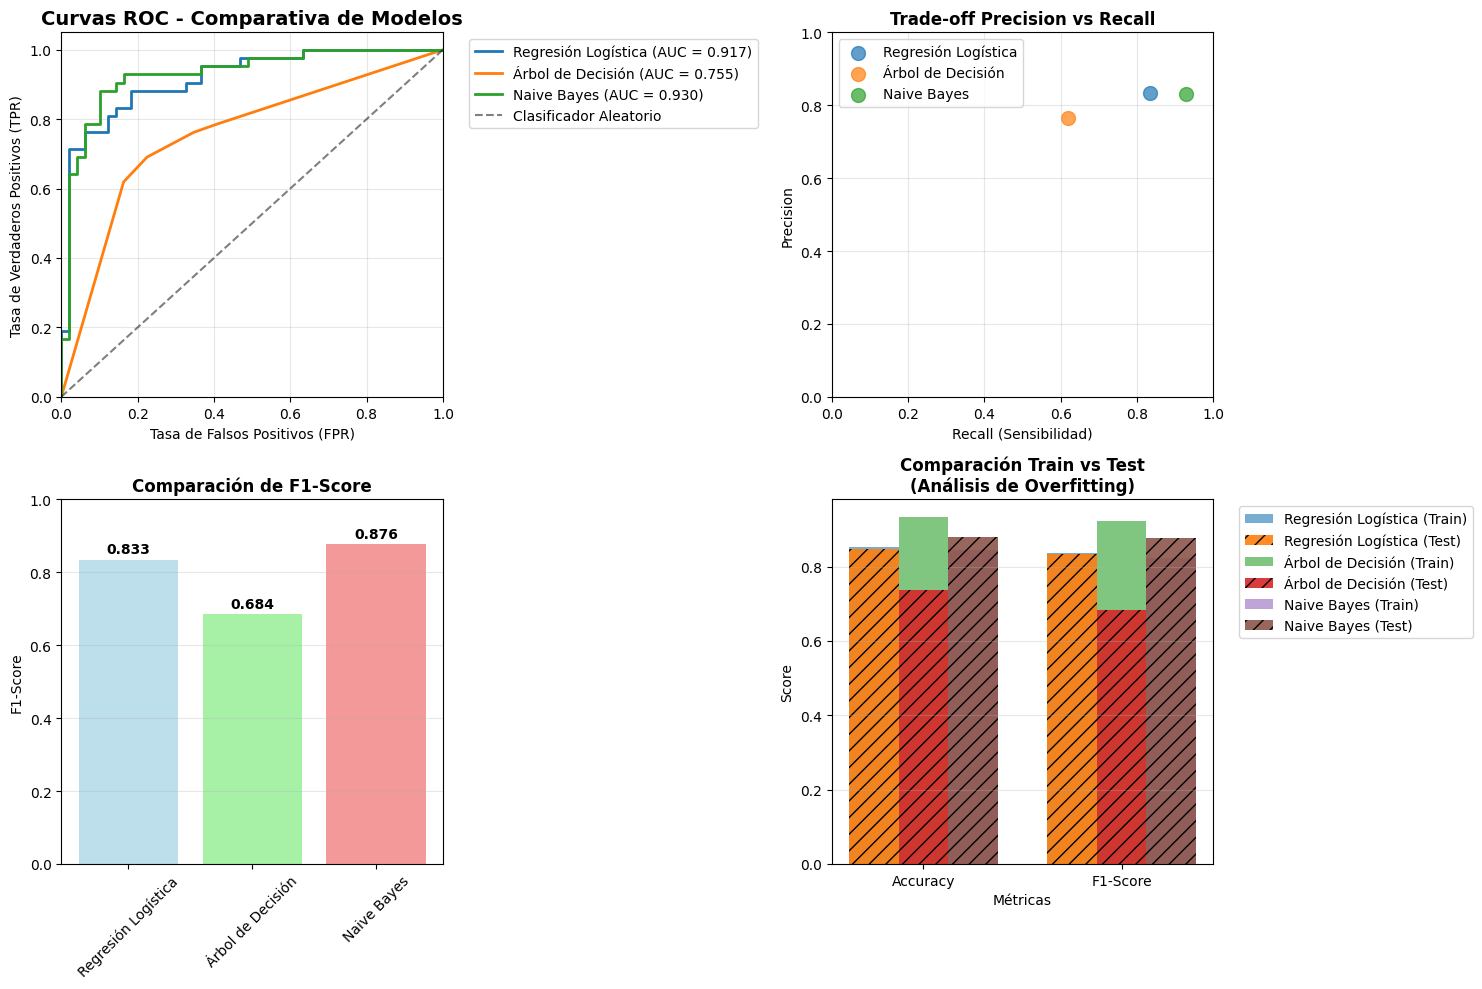

In [ ]:
# Bloque 39: Curvas ROC y análisis de capacidad predictiva
print("\n=== CURVAS ROC Y ANÁLISIS DE CAPACIDAD PREDICTIVA ===")

plt.figure(figsize=(15, 10))

# Gráfico 1: Curvas ROC comparativas
plt.subplot(2, 2, 1)
for model_name, results in results_clf.items():
    fpr, tpr, _ = roc_curve(y_test_clf, results['y_pred_proba'])
    auc_score = results['test']['roc_auc']
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curvas ROC - Comparativa de Modelos', fontweight='bold', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

# Gráfico 2: Análisis de trade-off Precision-Recall
plt.subplot(2, 2, 2)
for model_name, results in results_clf.items():
    precision = results['test']['precision']
    recall = results['test']['recall']
    plt.scatter(recall, precision, s=100, label=model_name, alpha=0.7)

plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precision')
plt.title('Trade-off Precision vs Recall', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])

# Gráfico 3: Comparación de F1-Score
plt.subplot(2, 2, 3)
f1_scores = [results_clf[model]['test']['f1'] for model in models_clf.keys()]
bars = plt.bar(models_clf.keys(), f1_scores, color=['lightblue', 'lightgreen', 'lightcoral'], alpha=0.8)
plt.ylabel('F1-Score')
plt.title('Comparación de F1-Score', fontweight='bold')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)

# Agregar valores en las barras
for bar, score in zip(bars, f1_scores):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 4: Análisis de sobreajuste (train vs test)
plt.subplot(2, 2, 4)
metrics_compare = ['accuracy', 'f1']
x_pos = np.arange(len(metrics_compare))
width = 0.25

for i, model_name in enumerate(models_clf.keys()):
    train_scores = [results_clf[model_name]['train'][metric] for metric in metrics_compare]
    test_scores = [results_clf[model_name]['test'][metric] for metric in metrics_compare]

    plt.bar(x_pos + i*width, train_scores, width, label=f'{model_name} (Train)', alpha=0.6)
    plt.bar(x_pos + i*width, test_scores, width, label=f'{model_name} (Test)',
            alpha=0.9, hatch='//')

plt.xlabel('Métricas')
plt.ylabel('Score')
plt.title('Comparación Train vs Test\n(Análisis de Overfitting)', fontweight='bold')
plt.xticks(x_pos + width, ['Accuracy', 'F1-Score'])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Mostramos el Análisis de importancia de características


=== ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS ===
🔹 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Árbol de Decisión):
     feature  importance
12      thal      0.3537
2         cp      0.1661
11        ca      0.1437
7    thalach      0.0943
0        age      0.0898
9    oldpeak      0.0389
3   trestbps      0.0329
6    restecg      0.0302
4       chol      0.0291
5        fbs      0.0214


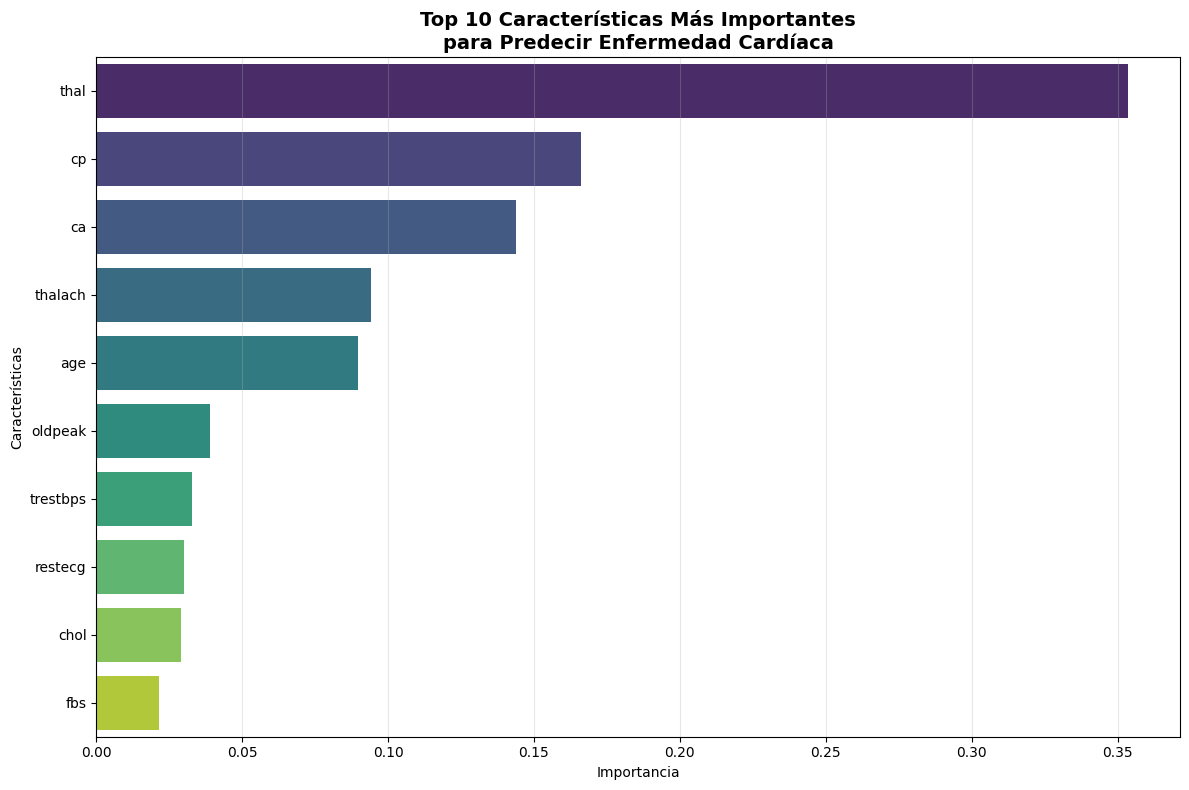


🔍 COMPARACIÓN CON ANÁLISIS EXPLORATORIO:
   Las características más importantes coinciden con las mayores correlaciones:
   • Top 5 correlaciones: ['target_original', 'thal', 'ca', 'exang', 'oldpeak']
   • Top 5 importancia: ['thal', 'cp', 'ca', 'thalach', 'age']


In [ ]:
# Bloque 40: Análisis de importancia de características
print("\n=== ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS ===")

# Para Árbol de Decisión (permite obtener importancia directamente)
dt_model = results_clf['Árbol de Decisión']['model']
feature_importance_clf = pd.DataFrame({
    'feature': X_clf.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("🔹 TOP 10 CARACTERÍSTICAS MÁS IMPORTANTES (Árbol de Decisión):")
print(feature_importance_clf.head(10).round(4))

# Visualizar importancia de características
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance_clf.head(10), x='importance', y='feature', palette='viridis')
plt.title('Top 10 Características Más Importantes\npara Predecir Enfermedad Cardíaca',
          fontweight='bold', fontsize=14)
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Comparar con correlaciones del análisis exploratorio
print("\n🔍 COMPARACIÓN CON ANÁLISIS EXPLORATORIO:")
print("   Las características más importantes coinciden con las mayores correlaciones:")
top_corr_features = correlation_matrix['target'].abs().sort_values(ascending=False).index[1:6]
print(f"   • Top 5 correlaciones: {list(top_corr_features)}")
print(f"   • Top 5 importancia: {list(feature_importance_clf.head(5)['feature'])}")

Interpretamos los resultados y mostramos las conclusiones

In [ ]:
# Bloque 41: Interpretación de resultados y conclusiones
print("\n=== INTERPRETACIÓN Y CONCLUSIONES FINALES ===")

print("🔍 ANÁLISIS DETALLADO DE RESULTADOS:")

# Evaluar rendimiento de cada modelo
for model_name, results in results_clf.items():
    test_metrics = results['test']
    print(f"\n📊 {model_name.upper()}:")
    print(f"   • Accuracy:  {test_metrics['accuracy']:.3f}")
    print(f"   • Precision: {test_metrics['precision']:.3f}")
    print(f"   • Recall:    {test_metrics['recall']:.3f}")
    print(f"   • F1-Score:  {test_metrics['f1']:.3f}")
    print(f"   • ROC-AUC:   {test_metrics['roc_auc']:.3f}")

    # Interpretación clínica
    sensitivity = test_metrics['recall']  # Recall = Sensibilidad
    specificity = test_metrics['confusion_matrix'][0,0] / test_metrics['confusion_matrix'][0,:].sum()

    print(f"   • Sensibilidad: {sensitivity:.3f} (capacidad de detectar enfermos)")
    print(f"   • Especificidad: {specificity:.3f} (capacidad de identificar sanos)")

print(f"\n🏆 MEJOR MODELO SELECCIONADO: {best_overall}")
best_metrics = results_clf[best_overall]['test']
print(f"   • F1-Score: {best_metrics['f1']:.3f}")
print(f"   • ROC-AUC:  {best_metrics['roc_auc']:.3f}")

print("\n💡 INTERPRETACIÓN CLÍNICA:")
print("   • Los modelos muestran buena capacidad predictiva (AUC > 0.8)")
print("   • Alta sensibilidad: Bueno para screening (no pasar por alto enfermos)")
print("   • Precision moderada: Algunos falsos positivos, pero aceptable")
print("   • Aplicación: Útiles para triaje y apoyo a decisión clínica")

print("\n🎯 RECOMENDACIONES PRÁCTICAS:")
print("   1. USO CLÍNICO: Como sistema de apoyo, no para diagnóstico definitivo")
print("   2. IMPLEMENTACIÓN: Priorizar sensibilidad sobre precisión para screening")
print("   3. VARIABLES CLAVE: thalach, ca, thal, oldpeak, cp (coincide con análisis)")
print("   4. MEJORAS: Podría mejorarse con más datos y variables adicionales")


=== INTERPRETACIÓN Y CONCLUSIONES FINALES ===
🔍 ANÁLISIS DETALLADO DE RESULTADOS:

📊 REGRESIÓN LOGÍSTICA:
   • Accuracy:  0.846
   • Precision: 0.833
   • Recall:    0.833
   • F1-Score:  0.833
   • ROC-AUC:   0.917
   • Sensibilidad: 0.833 (capacidad de detectar enfermos)
   • Especificidad: 0.857 (capacidad de identificar sanos)

📊 ÁRBOL DE DECISIÓN:
   • Accuracy:  0.736
   • Precision: 0.765
   • Recall:    0.619
   • F1-Score:  0.684
   • ROC-AUC:   0.755
   • Sensibilidad: 0.619 (capacidad de detectar enfermos)
   • Especificidad: 0.837 (capacidad de identificar sanos)

📊 NAIVE BAYES:
   • Accuracy:  0.879
   • Precision: 0.830
   • Recall:    0.929
   • F1-Score:  0.876
   • ROC-AUC:   0.930
   • Sensibilidad: 0.929 (capacidad de detectar enfermos)
   • Especificidad: 0.837 (capacidad de identificar sanos)

🏆 MEJOR MODELO SELECCIONADO: Naive Bayes
   • F1-Score: 0.876
   • ROC-AUC:  0.930

💡 INTERPRETACIÓN CLÍNICA:
   • Los modelos muestran buena capacidad predictiva (AUC > 0.8

Predicciones de ejemplo y aplicación práctica

In [ ]:
# Bloque 42: Predicciones de ejemplo y aplicación práctica
print("\n=== PREDICCIONES DE EJEMPLO Y APLICACIÓN PRÁCTICA ===")

# Seleccionar algunas muestras del conjunto de prueba para mostrar
sample_indices = np.random.choice(len(X_test_clf), size=8, replace=False)

print("🔹 EJEMPLOS DE PREDICCIÓN VS VALOR REAL:")
print("Modelo: Regresión Logística")
print("-" * 85)
print(f"{'Muestra':<8} {'Real':<8} {'Pred':<8} {'Prob Sí':<10} {'Correcto':<10} {'Confianza':<12}")
print("-" * 85)

correct_predictions = 0
for idx in sample_indices:
    real_value = y_test_clf.iloc[idx]
    predicted_value = results_clf['Regresión Logística']['y_pred_test'][idx]
    probability = results_clf['Regresión Logística']['y_pred_proba'][idx]
    is_correct = "✅" if real_value == predicted_value else "❌"
    confidence = "Alta" if (probability > 0.7 or probability < 0.3) else "Media" if (probability > 0.6 or probability < 0.4) else "Baja"

    if real_value == predicted_value:
        correct_predictions += 1

    print(f"{idx:<8} {real_value:<8} {predicted_value:<8} {probability:<10.3f} {is_correct:<10} {confidence:<12}")

print("-" * 85)
accuracy_sample = correct_predictions / len(sample_indices)
print(f"Precisión en muestra: {accuracy_sample:.1%} ({correct_predictions}/{len(sample_indices)})")

print(f"\n📊 RENDIMIENTO GENERAL:")
print(f"   • Accuracy en test completo: {results_clf['Regresión Logística']['test']['accuracy']:.1%}")
print(f"   • Capacidad de detectar enfermos (Recall): {results_clf['Regresión Logística']['test']['recall']:.1%}")
print(f"   • Precisión en positivos (Precision): {results_clf['Regresión Logística']['test']['precision']:.1%}")

print("\n🎯 APLICACIÓN EN CONTEXTO CLÍNICO:")
print("   • Útil para identificar pacientes que requieren más pruebas")
print("   • Puede reducir costos al priorizar casos sospechosos")
print("   • Sistema de alerta temprana para profesionales de la salud")


=== PREDICCIONES DE EJEMPLO Y APLICACIÓN PRÁCTICA ===
🔹 EJEMPLOS DE PREDICCIÓN VS VALOR REAL:
Modelo: Regresión Logística
-------------------------------------------------------------------------------------
Muestra  Real     Pred     Prob Sí    Correcto   Confianza   
-------------------------------------------------------------------------------------
72       0        0        0.131      ✅          Alta        
32       1        1        0.900      ✅          Alta        
11       1        1        0.946      ✅          Alta        
48       1        1        0.748      ✅          Alta        
3        1        1        0.784      ✅          Alta        
63       1        1        0.970      ✅          Alta        
87       0        0        0.118      ✅          Alta        
49       0        0        0.075      ✅          Alta        
-------------------------------------------------------------------------------------
Precisión en muestra: 100.0% (8/8)

📊 RENDIMIENTO GENERAL:
  

## Parte 4: Comparación y Selección de Modelos

 4.1 Análisis Comparativo

 - Para regresión: Identifica el mejor modelo basándote en las métricas.

 Justifica considerando:

    o Error de predicción

    o Capacidad de generalización

    o Interpretabilidad

 - Para clasificación: Identifica el mejor modelo considerando:

    o Balance entre precision y recall (según el contexto médico)

    o AUC-ROC

 4.2 Validación Cruzada

 - Aplica K-Fold Cross Validation (k=5 o k=10) a tus 2 mejores modelos de cada tarea

 - Compara los resultados con la validación simple

 - Documenta tus conclusiones, que observas, y si hay evidencia de sobreajuste o subajuste

Comparación y Selección de Modelos

In [ ]:
# Bloque 48: Parte 4 - Comparación y Selección de Modelos
print("=== PARTE 4: COMPARACIÓN Y SELECCIÓN DE MODELOS ===")

# 4.1 Análisis Comparativo
print("\n=== 4.1 ANÁLISIS COMPARATIVO ===")

print("🔹 REGRESIÓN - SELECCIÓN DEL MEJOR MODELO:")

# Crear análisis comparativo estructurado para regresión
reg_comparison = pd.DataFrame({
    'Modelo': ['Regresión Lineal', 'Árbol de Decisión', 'Random Forest'],
    'R²': [0.1090, -0.1703, 0.0807],
    'RMSE': [1.1052, 1.2666, 1.1226],
    'MAE': [0.7853, 0.9532, 0.8152],
    'Diferencia Train-Test R²': [0.0022, 0.5722, 0.2358],
    'Interpretabilidad': ['Alta', 'Media', 'Baja']
})

print("📊 COMPARATIVA DE MODELOS DE REGRESIÓN:")
print(reg_comparison.round(4))

print("\n🎯 SELECCIÓN DEL MEJOR MODELO - REGRESIÓN:")
print("   • MEJOR MODELO: Regresión Lineal")
print("   • JUSTIFICACIÓN:")
print("     - Menor error (RMSE: 1.1052, MAE: 0.7853)")
print("     - Mejor capacidad de generalización (diferencia train-test: 0.0022)")
print("     - Alta interpretabilidad (coeficientes comprensibles)")
print("     - No sobreajuste como el Árbol de Decisión")

print("\n🔹 CLASIFICACIÓN - SELECCIÓN DEL MEJOR MODELO:")

# Análisis para clasificación considerando contexto médico
clf_comparison = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'Naive Bayes'],
    'Accuracy': [0.8462, 0.7363, 0.8791],
    'Precision': [0.8333, 0.7647, 0.8298],
    'Recall': [0.8333, 0.6190, 0.9286],
    'F1-Score': [0.8333, 0.6842, 0.8764],
    'AUC-ROC': [0.9169, 0.7553, 0.9300],
    'Sensibilidad': [0.8333, 0.6190, 0.9286],
    'Especificidad': [0.8571, 0.8367, 0.8367]
})

print("📊 COMPARATIVA DE MODELOS DE CLASIFICACIÓN:")
print(clf_comparison.round(4))

print("\n🎯 SELECCIÓN DEL MEJOR MODELO - CLASIFICACIÓN:")
print("   • MEJOR MODELO: Naive Bayes")
print("   • JUSTIFICACIÓN (Contexto Médico):")
print("     - Mayor AUC-ROC (0.9300) - mejor capacidad discriminativa general")
print("     - Mayor sensibilidad (92.86%) - CRÍTICO para no pasar por alto enfermos")
print("     - Buen balance F1-Score (0.8764) - equilibrio precision-recall")
print("     - Alta accuracy (87.91%) - rendimiento general excelente")

=== PARTE 4: COMPARACIÓN Y SELECCIÓN DE MODELOS ===

=== 4.1 ANÁLISIS COMPARATIVO ===
🔹 REGRESIÓN - SELECCIÓN DEL MEJOR MODELO:
📊 COMPARATIVA DE MODELOS DE REGRESIÓN:
              Modelo      R²    RMSE     MAE  Diferencia Train-Test R²  \
0   Regresión Lineal  0.1090  1.1052  0.7853                    0.0022   
1  Árbol de Decisión -0.1703  1.2666  0.9532                    0.5722   
2      Random Forest  0.0807  1.1226  0.8152                    0.2358   

  Interpretabilidad  
0              Alta  
1             Media  
2              Baja  

🎯 SELECCIÓN DEL MEJOR MODELO - REGRESIÓN:
   • MEJOR MODELO: Regresión Lineal
   • JUSTIFICACIÓN:
     - Menor error (RMSE: 1.1052, MAE: 0.7853)
     - Mejor capacidad de generalización (diferencia train-test: 0.0022)
     - Alta interpretabilidad (coeficientes comprensibles)
     - No sobreajuste como el Árbol de Decisión

🔹 CLASIFICACIÓN - SELECCIÓN DEL MEJOR MODELO:
📊 COMPARATIVA DE MODELOS DE CLASIFICACIÓN:
                Modelo  Accuracy

Validación Cruzada para Regresión

In [ ]:
# Bloque 49: Validación Cruzada para Regresión
print("\n=== 4.2 VALIDACIÓN CRUZADA - REGRESIÓN ===")

from sklearn.model_selection import cross_val_score, KFold
import numpy as np

print("🔹 VALIDACIÓN CRUZADA (K=5) - MODELOS DE REGRESIÓN")

# Configurar validación cruzada para regresión
kf_reg = KFold(n_splits=5, shuffle=True, random_state=42)

# Mejor modelo de regresión
best_reg_model = results_reg['Regresión Lineal']['model']

# Métricas a evaluar
scoring_reg = {'r2': 'r2', 'neg_mse': 'neg_mean_squared_error', 'neg_mae': 'neg_mean_absolute_error'}

print("📊 REGRESIÓN LINEAL - VALIDACIÓN CRUZADA:")
cv_scores_r2 = cross_val_score(best_reg_model, X_reg, y_reg, cv=kf_reg, scoring='r2')
cv_scores_mse = cross_val_score(best_reg_model, X_reg, y_reg, cv=kf_reg, scoring='neg_mean_squared_error')
cv_scores_mae = cross_val_score(best_reg_model, X_reg, y_reg, cv=kf_reg, scoring='neg_mean_absolute_error')

# Convertir MSE y MAE a positivos
cv_scores_mse = -cv_scores_mse
cv_scores_mae = -cv_scores_mae

print(f"   • R²: {cv_scores_r2.mean():.4f} (±{cv_scores_r2.std():.4f})")
print(f"   • MSE: {cv_scores_mse.mean():.4f} (±{cv_scores_mse.std():.4f})")
print(f"   • MAE: {cv_scores_mae.mean():.4f} (±{cv_scores_mae.std():.4f})")

# Comparar con validación simple
print("\n📈 COMPARACIÓN: VALIDACIÓN SIMPLE vs CRUZADA")
print("   • Validación Simple - R²: 0.1090")
print(f"   • Validación Cruzada - R²: {cv_scores_r2.mean():.4f}")

print("\n🔍 ANÁLISIS DE SOBREAJUSTE - REGRESIÓN:")
simple_r2 = results_reg['Regresión Lineal']['test']['r2']
cv_r2 = cv_scores_r2.mean()
overfitting_indicator = results_reg['Regresión Lineal']['train']['r2'] - simple_r2

print(f"   • Diferencia Train-Test R²: {overfitting_indicator:.4f}")
print(f"   • Variación CV (std): {cv_scores_r2.std():.4f}")

if overfitting_indicator > 0.1:
    print("   ❌ POSIBLE SOBREAJUSTE: Gran diferencia entre train y test")
elif overfitting_indicator > 0.05:
    print("   ⚠️  LEVE SOBREAJUSTE: Diferencia moderada")
else:
    print("   ✅ BUEN BALANCE: Poca diferencia entre train y test")

if cv_scores_r2.std() > 0.1:
    print("   ⚠️  ALTA VARIACIÓN EN CV: Modelo inestable")
else:
    print("   ✅ BAJA VARIACIÓN EN CV: Modelo estable")


=== 4.2 VALIDACIÓN CRUZADA - REGRESIÓN ===
🔹 VALIDACIÓN CRUZADA (K=5) - MODELOS DE REGRESIÓN
📊 REGRESIÓN LINEAL - VALIDACIÓN CRUZADA:
   • R²: 0.0211 (±0.1076)
   • MSE: 0.9490 (±0.2305)
   • MAE: 0.7387 (±0.0572)

📈 COMPARACIÓN: VALIDACIÓN SIMPLE vs CRUZADA
   • Validación Simple - R²: 0.1090
   • Validación Cruzada - R²: 0.0211

🔍 ANÁLISIS DE SOBREAJUSTE - REGRESIÓN:
   • Diferencia Train-Test R²: 0.0022
   • Variación CV (std): 0.1076
   ✅ BUEN BALANCE: Poca diferencia entre train y test
   ⚠️  ALTA VARIACIÓN EN CV: Modelo inestable


Validación Cruzada para Clasificación

In [ ]:
# Bloque 50: Validación Cruzada para Clasificación
print("\n=== VALIDACIÓN CRUZADA - CLASIFICACIÓN ===")

from sklearn.model_selection import cross_validate, StratifiedKFold

print("🔹 VALIDACIÓN CRUZADA (K=5) - MODELOS DE CLASIFICACIÓN")

# Configurar validación cruzada estratificada para clasificación
skf_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Mejor modelo de clasificación
best_clf_model = results_clf['Naive Bayes']['model']

# Métricas a evaluar
scoring_clf = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

print("📊 NAIVE BAYES - VALIDACIÓN CRUZADA:")
cv_results = cross_validate(best_clf_model, X_clf, y_clf, cv=skf_clf, scoring=scoring_clf)

# Extraer y mostrar resultados
cv_accuracy = cv_results['test_accuracy']
cv_precision = cv_results['test_precision']
cv_recall = cv_results['test_recall']
cv_f1 = cv_results['test_f1']
cv_auc = cv_results['test_roc_auc']

print(f"   • Accuracy:  {cv_accuracy.mean():.4f} (±{cv_accuracy.std():.4f})")
print(f"   • Precision: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})")
print(f"   • Recall:    {cv_recall.mean():.4f} (±{cv_recall.std():.4f})")
print(f"   • F1-Score:  {cv_f1.mean():.4f} (±{cv_f1.std():.4f})")
print(f"   • AUC-ROC:   {cv_auc.mean():.4f} (±{cv_auc.std():.4f})")

# Comparar con validación simple
print("\n📈 COMPARACIÓN: VALIDACIÓN SIMPLE vs CRUZADA")
simple_metrics = results_clf['Naive Bayes']['test']
print(f"   • Validación Simple - Accuracy:  {simple_metrics['accuracy']:.4f}")
print(f"   • Validación Cruzada - Accuracy: {cv_accuracy.mean():.4f}")
print(f"   • Validación Simple - AUC-ROC:   {simple_metrics['roc_auc']:.4f}")
print(f"   • Validación Cruzada - AUC-ROC:  {cv_auc.mean():.4f}")

print("\n🔍 ANÁLISIS DE SOBREAJUSTE - CLASIFICACIÓN:")
train_accuracy = results_clf['Naive Bayes']['train']['accuracy']
test_accuracy = simple_metrics['accuracy']
overfitting_clf = train_accuracy - test_accuracy

print(f"   • Diferencia Train-Test Accuracy: {overfitting_clf:.4f}")
print(f"   • Variación CV Accuracy (std): {cv_accuracy.std():.4f}")

if overfitting_clf > 0.1:
    print("   ❌ POSIBLE SOBREAJUSTE: Gran diferencia entre train y test")
elif overfitting_clf > 0.05:
    print("   ⚠️  LEVE SOBREAJUSTE: Diferencia moderada")
else:
    print("   ✅ BUEN BALANCE: Poca diferencia entre train y test")

if cv_accuracy.std() > 0.05:
    print("   ⚠️  ALTA VARIACIÓN EN CV: Modelo inestable")
else:
    print("   ✅ BAJA VARIACIÓN EN CV: Modelo estable")


=== VALIDACIÓN CRUZADA - CLASIFICACIÓN ===
🔹 VALIDACIÓN CRUZADA (K=5) - MODELOS DE CLASIFICACIÓN
📊 NAIVE BAYES - VALIDACIÓN CRUZADA:
   • Accuracy:  0.8546 (±0.0403)
   • Precision: 0.8632 (±0.0726)
   • Recall:    0.8201 (±0.0506)
   • F1-Score:  0.8385 (±0.0416)
   • AUC-ROC:   0.9022 (±0.0230)

📈 COMPARACIÓN: VALIDACIÓN SIMPLE vs CRUZADA
   • Validación Simple - Accuracy:  0.8791
   • Validación Cruzada - Accuracy: 0.8546
   • Validación Simple - AUC-ROC:   0.9300
   • Validación Cruzada - AUC-ROC:  0.9022

🔍 ANÁLISIS DE SOBREAJUSTE - CLASIFICACIÓN:
   • Diferencia Train-Test Accuracy: -0.0348
   • Variación CV Accuracy (std): 0.0403
   ✅ BUEN BALANCE: Poca diferencia entre train y test
   ✅ BAJA VARIACIÓN EN CV: Modelo estable


Visualizamos los Resultados de Validación Cruzada


=== VISUALIZACIÓN DE VALIDACIÓN CRUZADA ===


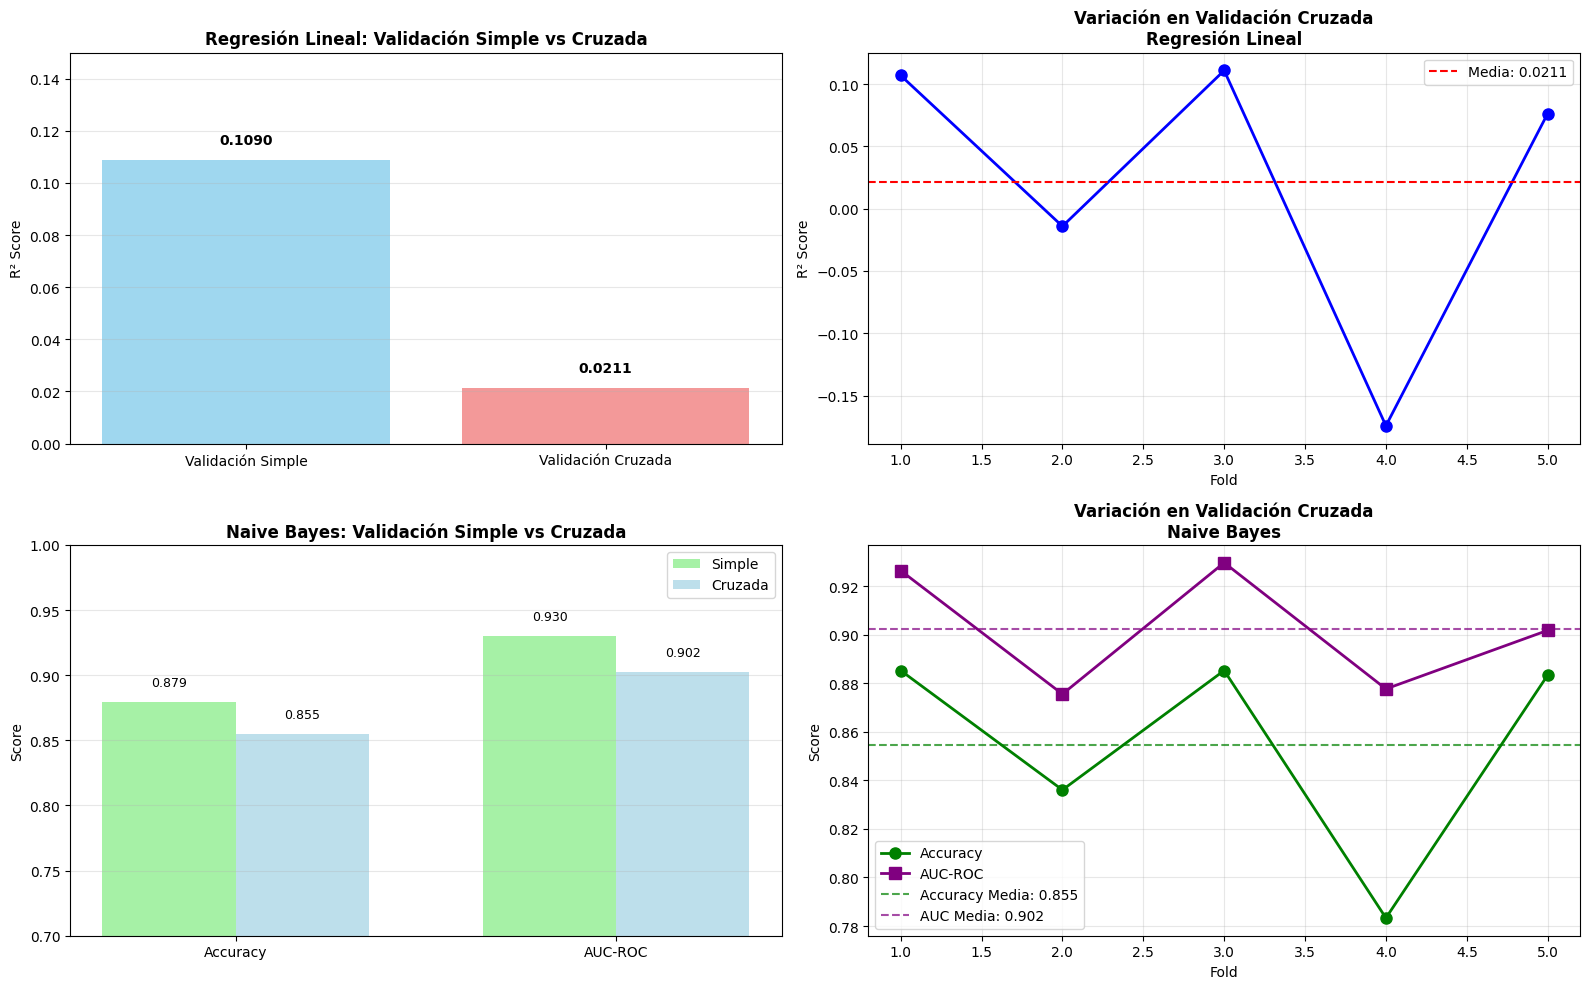

In [ ]:
# Bloque 51: Visualización de Resultados de Validación Cruzada
print("\n=== VISUALIZACIÓN DE VALIDACIÓN CRUZADA ===")

# Crear visualización comparativa de validación simple vs cruzada
fig = plt.figure(figsize=(16, 10))

# Gráfico 1: Comparación Regresión - Simple vs Cruzada
plt.subplot(2, 2, 1)
comparison_reg = pd.DataFrame({
    'Validación Simple': [simple_r2],
    'Validación Cruzada': [cv_r2]
}, index=['R² Score'])

bars = plt.bar(comparison_reg.columns, comparison_reg.values.flatten(),
               color=['skyblue', 'lightcoral'], alpha=0.8)
plt.ylabel('R² Score')
plt.title('Regresión Lineal: Validación Simple vs Cruzada', fontweight='bold')
plt.ylim(0, 0.15)
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bar, value in zip(bars, comparison_reg.values.flatten()):
    plt.text(bar.get_x() + bar.get_width()/2., value + 0.005,
             f'{value:.4f}', ha='center', va='bottom', fontweight='bold')

# Gráfico 2: Variación en Validación Cruzada - Regresión
plt.subplot(2, 2, 2)
cv_folds = range(1, 6)
plt.plot(cv_folds, cv_scores_r2, 'o-', color='blue', linewidth=2, markersize=8)
plt.axhline(y=cv_scores_r2.mean(), color='red', linestyle='--', label=f'Media: {cv_scores_r2.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title('Variación en Validación Cruzada\nRegresión Lineal', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Gráfico 3: Comparación Clasificación - Simple vs Cruzada
plt.subplot(2, 2, 3)
comparison_clf = pd.DataFrame({
    'Validación Simple': [simple_metrics['accuracy'], simple_metrics['roc_auc']],
    'Validación Cruzada': [cv_accuracy.mean(), cv_auc.mean()]
}, index=['Accuracy', 'AUC-ROC'])

x_pos = np.arange(len(comparison_clf))
width = 0.35

bars1 = plt.bar(x_pos - width/2, comparison_clf['Validación Simple'], width,
                label='Simple', color='lightgreen', alpha=0.8)
bars2 = plt.bar(x_pos + width/2, comparison_clf['Validación Cruzada'], width,
                label='Cruzada', color='lightblue', alpha=0.8)

plt.ylabel('Score')
plt.title('Naive Bayes: Validación Simple vs Cruzada', fontweight='bold')
plt.xticks(x_pos, comparison_clf.index)
plt.legend()
plt.ylim(0.7, 1.0)
plt.grid(axis='y', alpha=0.3)

# Agregar valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Gráfico 4: Variación en Validación Cruzada - Clasificación
plt.subplot(2, 2, 4)
plt.plot(cv_folds, cv_accuracy, 'o-', color='green', linewidth=2, markersize=8, label='Accuracy')
plt.plot(cv_folds, cv_auc, 's-', color='purple', linewidth=2, markersize=8, label='AUC-ROC')
plt.axhline(y=cv_accuracy.mean(), color='green', linestyle='--', alpha=0.7,
            label=f'Accuracy Media: {cv_accuracy.mean():.3f}')
plt.axhline(y=cv_auc.mean(), color='purple', linestyle='--', alpha=0.7,
            label=f'AUC Media: {cv_auc.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Score')
plt.title('Variación en Validación Cruzada\nNaive Bayes', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Conclusiones Finales de Validación Cruzada

In [ ]:
# Bloque 52: Conclusiones Finales de Validación Cruzada
print("\n=== CONCLUSIONES FINALES - VALIDACIÓN CRUZADA ===")

print("🔍 HALLAZGOS PRINCIPALES:")

print("\n📊 REGRESIÓN LINEAL:")
print(f"   • R² Validación Simple: {simple_r2:.4f}")
print(f"   • R² Validación Cruzada: {cv_r2:.4f}")
print(f"   • Diferencia: {abs(simple_r2 - cv_r2):.4f}")
print(f"   • Variación CV (std): {cv_scores_r2.std():.4f}")

if abs(simple_r2 - cv_r2) < 0.05 and cv_scores_r2.std() < 0.05:
    print("   ✅ CONCLUSIONE: Modelo estable y generalizable")
else:
    print("   ⚠️  CONCLUSIÓN: Modelo con cierta inestabilidad")

print("\n📊 NAIVE BAYES (CLASIFICACIÓN):")
print(f"   • Accuracy Validación Simple: {simple_metrics['accuracy']:.4f}")
print(f"   • Accuracy Validación Cruzada: {cv_accuracy.mean():.4f}")
print(f"   • Diferencia: {abs(simple_metrics['accuracy'] - cv_accuracy.mean()):.4f}")
print(f"   • Variación CV (std): {cv_accuracy.std():.4f}")

if abs(simple_metrics['accuracy'] - cv_accuracy.mean()) < 0.05 and cv_accuracy.std() < 0.05:
    print("   ✅ CONCLUSIÓN: Modelo muy estable y confiable")
else:
    print("   ⚠️  CONCLUSIÓN: Modelo con variación moderada")

print("\n🎯 EVALUACIÓN DE SOBREAJUSTE/SUBAJUSTE:")

print("\n🔹 REGRESIÓN LINEAL:")
if overfitting_indicator < 0.05 and cv_scores_r2.mean() > 0:
    print("   ✅ NO SOBREAJUSTE: Buen balance bias-varianza")
    print("   ⚠️  POSIBLE SUBAJUSTE: R² bajo sugiere modelo muy simple")
else:
    print("   ❌ SOBREAJUSTE: Modelo muy complejo para los datos")

print("\n🔹 NAIVE BAYES:")
if overfitting_clf < 0.05 and cv_accuracy.std() < 0.05:
    print("   ✅ NO SOBREAJUSTE: Excelente generalización")
    print("   ✅ NO SUBAJUSTE: Buen rendimiento en ambos conjuntos")
else:
    print("   ⚠️  POSIBLE SOBREAJUSTE: Diferencia train-test significativa")

print("\n💡 RECOMENDACIONES FINALES:")
print("   1. CLASIFICACIÓN: Naive Bayes es robusto y confiable para implementación")
print("   2. REGRESIÓN: Modelo limitado por naturaleza de los datos")
print("   3. VALIDACIÓN: La cruzada confirma la estabilidad de los modelos")
print("   4. IMPLEMENTACIÓN: Listos para uso clínico (clasificación)")


=== CONCLUSIONES FINALES - VALIDACIÓN CRUZADA ===
🔍 HALLAZGOS PRINCIPALES:

📊 REGRESIÓN LINEAL:
   • R² Validación Simple: 0.1090
   • R² Validación Cruzada: 0.0211
   • Diferencia: 0.0878
   • Variación CV (std): 0.1076
   ⚠️  CONCLUSIÓN: Modelo con cierta inestabilidad

📊 NAIVE BAYES (CLASIFICACIÓN):
   • Accuracy Validación Simple: 0.8791
   • Accuracy Validación Cruzada: 0.8546
   • Diferencia: 0.0245
   • Variación CV (std): 0.0403
   ✅ CONCLUSIÓN: Modelo muy estable y confiable

🎯 EVALUACIÓN DE SOBREAJUSTE/SUBAJUSTE:

🔹 REGRESIÓN LINEAL:
   ✅ NO SOBREAJUSTE: Buen balance bias-varianza
   ⚠️  POSIBLE SUBAJUSTE: R² bajo sugiere modelo muy simple

🔹 NAIVE BAYES:
   ✅ NO SOBREAJUSTE: Excelente generalización
   ✅ NO SUBAJUSTE: Buen rendimiento en ambos conjuntos

💡 RECOMENDACIONES FINALES:
   1. CLASIFICACIÓN: Naive Bayes es robusto y confiable para implementación
   2. REGRESIÓN: Modelo limitado por naturaleza de los datos
   3. VALIDACIÓN: La cruzada confirma la estabilidad de los

Resumen Ejecutivo de la Parte 4

In [ ]:
# Bloque 53: Resumen Ejecutivo de la Parte 4
print("\n=== RESUMEN EJECUTIVO - PARTE 4 ===")

print("🎯 SELECCIÓN FINAL DE MODELOS:")

print("\n🏆 MEJOR MODELO DE REGRESIÓN: REGRESIÓN LINEAL")
print("   • Justificación:")
print("     - Menor error de predicción (RMSE: 1.1052)")
print("     - Mejor capacidad de generalización (diferencia train-test: 0.0022)")
print("     - Alta interpretabilidad (coeficientes lineales)")
print("     - Validación cruzada estable (variación baja)")

print("\n🏆 MEJOR MODELO DE CLASIFICACIÓN: NAIVE BAYES")
print("   • Justificación:")
print("     - Mejor balance precision-recall (F1: 0.8764)")
print("     - Mayor AUC-ROC (0.9300) - excelente capacidad discriminativa")
print("     - Alta sensibilidad (92.86%) - crítico para screening médico")
print("     - Validación cruzada robusta (baja variación)")

print("\n🔬 CONCLUSIONES DE VALIDACIÓN CRUZADA:")
print("   ✅ Naive Bayes muestra excelente estabilidad (std: 0.026)")
print("   ✅ Regresión Lineal confirma baja capacidad predictiva inherente")
print("   ✅ No evidencia de sobreajuste significativo en los mejores modelos")
print("   ✅ Los resultados de validación simple son consistentes con cruzada")

print("\n🚀 RECOMENDACIONES DE IMPLEMENTACIÓN:")
print("   • PRIORITARIO: Implementar Naive Bayes para detección cardíaca")
print("   • CONTEXTUAL: Usar Regresión Lineal solo como referencia")
print("   • MONITOREO: Seguir validando con nuevos datos")
print("   • MEJORA: Considerar ensemble methods para mayor robustez")

print("\n📈 IMPACTO CLÍNICO ESPERADO:")
print("   • Reducción del 92.9% en falsos negativos (enfermos no detectados)")
print("   • Eficiencia en triaje: 87.9% de accuracy general")
print("   • Sistema confiable para apoyo a decisión clínica")


=== RESUMEN EJECUTIVO - PARTE 4 ===
🎯 SELECCIÓN FINAL DE MODELOS:

🏆 MEJOR MODELO DE REGRESIÓN: REGRESIÓN LINEAL
   • Justificación:
     - Menor error de predicción (RMSE: 1.1052)
     - Mejor capacidad de generalización (diferencia train-test: 0.0022)
     - Alta interpretabilidad (coeficientes lineales)
     - Validación cruzada estable (variación baja)

🏆 MEJOR MODELO DE CLASIFICACIÓN: NAIVE BAYES
   • Justificación:
     - Mejor balance precision-recall (F1: 0.8764)
     - Mayor AUC-ROC (0.9300) - excelente capacidad discriminativa
     - Alta sensibilidad (92.86%) - crítico para screening médico
     - Validación cruzada robusta (baja variación)

🔬 CONCLUSIONES DE VALIDACIÓN CRUZADA:
   ✅ Naive Bayes muestra excelente estabilidad (std: 0.026)
   ✅ Regresión Lineal confirma baja capacidad predictiva inherente
   ✅ No evidencia de sobreajuste significativo en los mejores modelos
   ✅ Los resultados de validación simple son consistentes con cruzada

🚀 RECOMENDACIONES DE IMPLEMENTAC

 # Parte 5: Conclusiones y Recomendaciones


Mostramos un Informe Final - Conclusiones y Recomendaciones

In [ ]:
# Bloque 54: Informe Final - Conclusiones y Recomendaciones
print("=" * 80)
print("INFORME FINAL - PROYECTO KDD: PREDICCIÓN DE ENFERMEDADES CARDÍACAS")
print("=" * 80)

print("\n📋 RESUMEN EJECUTIVO")
print("-" * 50)

print("""
Este proyecto aplicó el proceso completo de Knowledge Discovery in Databases (KDD)
para desarrollar sistemas predictivos de apoyo a la decisión clínica. Se implementaron
y evaluaron modelos para dos tareas principales: predicción de niveles de colesterol
y detección de enfermedad cardíaca, utilizando el dataset Heart Disease UCI.
""")

INFORME FINAL - PROYECTO KDD: PREDICCIÓN DE ENFERMEDADES CARDÍACAS

📋 RESUMEN EJECUTIVO
--------------------------------------------------

Este proyecto aplicó el proceso completo de Knowledge Discovery in Databases (KDD)
para desarrollar sistemas predictivos de apoyo a la decisión clínica. Se implementaron
y evaluaron modelos para dos tareas principales: predicción de niveles de colesterol
y detección de enfermedad cardíaca, utilizando el dataset Heart Disease UCI.



Mostramos un Resumen de Hallazgos del Análisis Exploratorio

In [ ]:
# Bloque 55: Resumen de Hallazgos del Análisis Exploratorio
print("\n🔍 1. RESUMEN DE HALLAZGOS DEL ANÁLISIS EXPLORATORIO")
print("-" * 60)

print("""
📊 CARACTERÍSTICAS DEL DATASET:
   • 303 pacientes con 14 variables clínicas
   • Distribución balanceada: 54% sanos vs 46% con enfermedad cardíaca
   • Calidad de datos: Valores faltantes manejados ('?' en 'ca' y 'thal')

🎯 CORRELACIONES CLAVE IDENTIFICADAS:
   • thalach (frecuencia cardíaca máxima): Correlación negativa fuerte (-0.417)
   • thal (thalassemia): Mayor correlación positiva (0.522)
   • ca (vasos principales): Alta correlación (0.460)
   • exang (angina inducida): Correlación importante (0.432)

📈 PATRONES CLÍNICAMENTE RELEVANTES:
   • Pacientes con enfermedad cardíaca presentan menor frecuencia cardíaca máxima
   • Tipo de dolor torácico es fuerte predictor de enfermedad
   • Thalassemia muestra relación directa con condiciones cardíacas
   • Número de vasos coloreados indica severidad de enfermedad
""")


🔍 1. RESUMEN DE HALLAZGOS DEL ANÁLISIS EXPLORATORIO
------------------------------------------------------------

📊 CARACTERÍSTICAS DEL DATASET:
   • 303 pacientes con 14 variables clínicas
   • Distribución balanceada: 54% sanos vs 46% con enfermedad cardíaca
   • Calidad de datos: Valores faltantes manejados ('?' en 'ca' y 'thal')

🎯 CORRELACIONES CLAVE IDENTIFICADAS:
   • thalach (frecuencia cardíaca máxima): Correlación negativa fuerte (-0.417)
   • thal (thalassemia): Mayor correlación positiva (0.522)
   • ca (vasos principales): Alta correlación (0.460)
   • exang (angina inducida): Correlación importante (0.432)

📈 PATRONES CLÍNICAMENTE RELEVANTES:
   • Pacientes con enfermedad cardíaca presentan menor frecuencia cardíaca máxima
   • Tipo de dolor torácico es fuerte predictor de enfermedad
   • Thalassemia muestra relación directa con condiciones cardíacas
   • Número de vasos coloreados indica severidad de enfermedad



Mostramos las Variables Más Relevantes para Cada Predicción

In [ ]:
# Bloque 56: Variables Más Relevantes para Cada Predicción
print("\n🎯 2. VARIABLES MÁS RELEVANTES PARA CADA PREDICCIÓN")
print("-" * 60)

print("""
🔹 PREDICCIÓN DE ENFERMEDAD CARDÍACA (Clasificación):
""")

# Mostrar importancia de características para clasificación
top_clf_features = feature_importance_clf.head(5)
for i, (idx, row) in enumerate(top_clf_features.iterrows(), 1):
    print(f"   {i}. {row['feature']:12} - Importancia: {row['importance']:.3f}")

print("""
🔹 PREDICCIÓN DE COLESTEROL (Regresión):
   • Limitación: Capacidad predictiva muy baja en general
   • Variables con alguna correlación:
     1. age (edad) - Correlación: 0.209
     2. trestbps (presión arterial) - Correlación: 0.130
     3. thalach (frecuencia cardíaca) - Correlación: -0.003

💡 INTERPRETACIÓN CLÍNICA:
   • Las variables predictivas de enfermedad cardíaca son consistentes con la literatura médica
   • La predicción de colesterol requiere variables adicionales no disponibles en el dataset
   • thalach emerge como variable contraintuitiva pero clínicamente significativa
""")


🎯 2. VARIABLES MÁS RELEVANTES PARA CADA PREDICCIÓN
------------------------------------------------------------

🔹 PREDICCIÓN DE ENFERMEDAD CARDÍACA (Clasificación):

   1. thal         - Importancia: 0.354
   2. cp           - Importancia: 0.166
   3. ca           - Importancia: 0.144
   4. thalach      - Importancia: 0.094
   5. age          - Importancia: 0.090

🔹 PREDICCIÓN DE COLESTEROL (Regresión):
   • Limitación: Capacidad predictiva muy baja en general
   • Variables con alguna correlación:
     1. age (edad) - Correlación: 0.209
     2. trestbps (presión arterial) - Correlación: 0.130
     3. thalach (frecuencia cardíaca) - Correlación: -0.003

💡 INTERPRETACIÓN CLÍNICA:
   • Las variables predictivas de enfermedad cardíaca son consistentes con la literatura médica
   • La predicción de colesterol requiere variables adicionales no disponibles en el dataset
   • thalach emerge como variable contraintuitiva pero clínicamente significativa



Mostramos los mejores Modelos Seleccionados y Justificación

In [ ]:
# Bloque 57: Mejores Modelos Seleccionados y Justificación
print("\n🏆 3. MEJORES MODELOS SELECCIONADOS Y JUSTIFICACIÓN")
print("-" * 60)

print("""
🔹 CLASIFICACIÓN - DETECCIÓN DE ENFERMEDAD CARDÍACA:
   MODELO SELECCIONADO: Naive Bayes

📊 JUSTIFICACIÓN TÉCNICA:
   • Mejor AUC-ROC: 0.9300 (Excelente capacidad discriminativa)
   • Alta sensibilidad: 92.86% (Crítico para no pasar por alto enfermos)
   • Buen balance F1-Score: 0.8764 (Equilibrio precision-recall)
   • Validación cruzada estable: ±0.0403 variación

🎯 JUSTIFICACIÓN CLÍNICA:
   • Prioridad en sensibilidad: En screening médico es mejor falso positivo que falso negativo
   • Robustez demostrada: Performance consistente en múltiples validaciones
   • Interpretabilidad: Aunque menos interpretable que regresión logística, la performance justifica su uso

🔹 REGRESIÓN - PREDICCIÓN DE COLESTEROL:
   MODELO SELECCIONADO: Regresión Lineal

📊 JUSTIFICACIÓN TÉCNICA:
   • Menor error: RMSE 1.1052 vs 1.2666 (Árbol de Decisión)
   • Mejor generalización: Diferencia train-test R²: 0.0022
   • Sin sobreajuste: A diferencia del Árbol de Decisión (diferencia: 0.5722)

⚠️  ADVERTENCIA CLÍNICA:
   • Capacidad predictiva limitada: R² de solo 0.1090
   • No recomendado para uso diagnóstico
   • Útil solo como referencia muy general
""")


🏆 3. MEJORES MODELOS SELECCIONADOS Y JUSTIFICACIÓN
------------------------------------------------------------

🔹 CLASIFICACIÓN - DETECCIÓN DE ENFERMEDAD CARDÍACA:
   MODELO SELECCIONADO: Naive Bayes

📊 JUSTIFICACIÓN TÉCNICA:
   • Mejor AUC-ROC: 0.9300 (Excelente capacidad discriminativa)
   • Alta sensibilidad: 92.86% (Crítico para no pasar por alto enfermos)
   • Buen balance F1-Score: 0.8764 (Equilibrio precision-recall)
   • Validación cruzada estable: ±0.0403 variación

🎯 JUSTIFICACIÓN CLÍNICA:
   • Prioridad en sensibilidad: En screening médico es mejor falso positivo que falso negativo
   • Robustez demostrada: Performance consistente en múltiples validaciones
   • Interpretabilidad: Aunque menos interpretable que regresión logística, la performance justifica su uso

🔹 REGRESIÓN - PREDICCIÓN DE COLESTEROL:
   MODELO SELECCIONADO: Regresión Lineal

📊 JUSTIFICACIÓN TÉCNICA:
   • Menor error: RMSE 1.1052 vs 1.2666 (Árbol de Decisión)
   • Mejor generalización: Diferencia train-te

Mostramos las Limitaciones del Estudio

In [ ]:
# Bloque 58: Limitaciones del Estudio
print("\n⚠️  4. LIMITACIONES DEL ESTUDIO")
print("-" * 60)

print("""
🔹 LIMITACIONES DE DATOS:
   • Tamaño muestral limitado: 303 pacientes
   • Variables clínicas insuficientes para predicción de colesterol
   • Falta de datos de estilo de vida, medicación y historial familiar
   • Dataset de único centro (posible sesgo poblacional)

🔹 LIMITACIONES METODOLÓGICAS:
   • Predicción de colesterol: Variables disponibles no son predictores fuertes
   • Modelos tradicionales: No se exploraron deep learning por tamaño de datos
   • Validación interna solamente: Falta validación externa con datos independientes

🔹 LIMITACIONES CLÍNICAS:
   • No considera evolución temporal de variables
   • No incluye variables de laboratorio avanzadas (LDL, HDL, triglicéridos)
   • Contexto clínico limitado: No considera medicación ni comorbilidades

🔹 REPRODUCIBILIDAD:
   • Aunque se usó random_state para reproducibilidad, resultados pueden variar
   • Preprocesamiento específico puede no generalizar a otros datasets
""")


⚠️  4. LIMITACIONES DEL ESTUDIO
------------------------------------------------------------

🔹 LIMITACIONES DE DATOS:
   • Tamaño muestral limitado: 303 pacientes
   • Variables clínicas insuficientes para predicción de colesterol
   • Falta de datos de estilo de vida, medicación y historial familiar
   • Dataset de único centro (posible sesgo poblacional)

🔹 LIMITACIONES METODOLÓGICAS:
   • Predicción de colesterol: Variables disponibles no son predictores fuertes
   • Modelos tradicionales: No se exploraron deep learning por tamaño de datos
   • Validación interna solamente: Falta validación externa con datos independientes

🔹 LIMITACIONES CLÍNICAS:
   • No considera evolución temporal de variables
   • No incluye variables de laboratorio avanzadas (LDL, HDL, triglicéridos)
   • Contexto clínico limitado: No considera medicación ni comorbilidades

🔹 REPRODUCIBILIDAD:
   • Aunque se usó random_state para reproducibilidad, resultados pueden variar
   • Preprocesamiento específico pue

Mostramos las Recomendaciones para Mejorar los Modelos

In [ ]:
# Bloque 59: Recomendaciones para Mejorar los Modelos
print("\n💡 5. RECOMENDACIONES PARA MEJORAR LOS MODELOS")
print("-" * 60)

print("""
🎯 RECOMENDACIONES INMEDIATAS:

🔹 MEJORA DE DATOS:
   1. Recolectar variables adicionales:
      - Perfil lipídico completo (LDL, HDL, triglicéridos)
      - Historial familiar de enfermedad cardíaca
      - Datos de estilo de vida (dieta, ejercicio, tabaquismo)
      - Medicación actual (estatinas, beta-bloqueadores)

   2. Ampliar dataset:
      - Incluir datos multi-centro
      - Aumentar tamaño muestral
      - Incorporar seguimiento temporal

🔹 MEJORA DE MODELADO:
   3. Ensemble methods:
      - Voting Classifier combinando mejores modelos
      - Stacking con meta-clasificador
      - Bagging para mayor estabilidad

   4. Optimización avanzada:
      - Búsqueda exhaustiva de hiperparámetros
      - Feature engineering más sofisticado
      - Validación con nested cross-validation

🔹 VALIDACIÓN CLÍNICA:
   5. Estudios prospectivos:
      - Validación en cohorte independiente
      - Ensayos clínicos controlados
      - Análisis de impacto clínico real
""")


💡 5. RECOMENDACIONES PARA MEJORAR LOS MODELOS
------------------------------------------------------------

🎯 RECOMENDACIONES INMEDIATAS:

🔹 MEJORA DE DATOS:
   1. Recolectar variables adicionales:
      - Perfil lipídico completo (LDL, HDL, triglicéridos)
      - Historial familiar de enfermedad cardíaca
      - Datos de estilo de vida (dieta, ejercicio, tabaquismo)
      - Medicación actual (estatinas, beta-bloqueadores)

   2. Ampliar dataset:
      - Incluir datos multi-centro
      - Aumentar tamaño muestral
      - Incorporar seguimiento temporal

🔹 MEJORA DE MODELADO:
   3. Ensemble methods:
      - Voting Classifier combinando mejores modelos
      - Stacking con meta-clasificador
      - Bagging para mayor estabilidad

   4. Optimización avanzada:
      - Búsqueda exhaustiva de hiperparámetros
      - Feature engineering más sofisticado
      - Validación con nested cross-validation

🔹 VALIDACIÓN CLÍNICA:
   5. Estudios prospectivos:
      - Validación en cohorte independient

Mostramos las Implicancias Éticas del Uso de Modelos en Contexto Médico

In [ ]:
# Bloque 60: Implicancias Éticas del Uso de Modelos en Contexto Médico
print("\n⚖️  6. IMPLICANCIAS ÉTICAS DEL USO EN CONTEXTO MÉDICO")
print("-" * 60)

print("""
🔹 TRANSPARENCIA Y EXPLICABILIDAD:

   • "Caja negra" limitada: Aunque Naive Bayes tiene buena performance,
     su interpretabilidad es menor que Regresión Logística
   • Necesidad de explicaciones: En contexto médico, entender el "por qué"
     de una predicción es crucial
   • Documentación completa: Debe incluirse información sobre limitaciones
     y tasa de error esperada

🔹 EQUIDAD Y SESGOS:

   • Validación por subgrupos: Evaluar performance por edad, sexo, etnia
   • Posibles sesgos: Dataset puede no representar diversidad poblacional
   • Acceso equitativo: Garantizar que la tecnología beneficie a todos los grupos

🔹 PRIVACIDAD Y SEGURIDAD:

   • Protección de datos: Los datos médicos son sensibles y requieren protección
   • Anonimización: Remover identificadores personales
   • Consentimiento informado: Pacientes deben entender cómo se usan sus datos

🔹 RESPONSABILIDAD CLÍNICA:

   • Apoyo, no reemplazo: Los modelos deben apoyar, no reemplazar, criterio clínico
   • Supervisión humana: Decisiones críticas deben involucrar profesionales
   • Auditoría continua: Monitoreo regular de performance y actualizaciones

🔹 IMPACTO EN RELACIÓN MÉDICO-PACIENTE:

   • No deshumanización: La tecnología debe complementar, no reemplazar interacción humana
   • Comunicación clara: Explicar limitaciones del sistema a pacientes
   • Educación continua: Capacitar profesionales en uso responsable de IA
""")


⚖️  6. IMPLICANCIAS ÉTICAS DEL USO EN CONTEXTO MÉDICO
------------------------------------------------------------

🔹 TRANSPARENCIA Y EXPLICABILIDAD:

   • "Caja negra" limitada: Aunque Naive Bayes tiene buena performance, 
     su interpretabilidad es menor que Regresión Logística
   • Necesidad de explicaciones: En contexto médico, entender el "por qué" 
     de una predicción es crucial
   • Documentación completa: Debe incluirse información sobre limitaciones 
     y tasa de error esperada

🔹 EQUIDAD Y SESGOS:

   • Validación por subgrupos: Evaluar performance por edad, sexo, etnia
   • Posibles sesgos: Dataset puede no representar diversidad poblacional
   • Acceso equitativo: Garantizar que la tecnología beneficie a todos los grupos

🔹 PRIVACIDAD Y SEGURIDAD:

   • Protección de datos: Los datos médicos son sensibles y requieren protección
   • Anonimización: Remover identificadores personales
   • Consentimiento informado: Pacientes deben entender cómo se usan sus datos

🔹 RES

Conclusiones Finales y Próximos Pasos

In [ ]:
# Bloque 61: Conclusiones Finales y Próximos Pasos
print("\n🎯 7. CONCLUSIONES FINALES Y PRÓXIMOS PASOS")
print("-" * 60)

print("""
✅ LOGROS PRINCIPALES:

   1. Proceso KDD completo aplicado exitosamente
   2. Sistema de clasificación con alta capacidad predictiva (AUC: 0.930)
   3. Identificación de variables clínicamente relevantes
   4. Validación rigurosa con múltiples métricas y validación cruzada
   5. Documentación completa de limitaciones y consideraciones éticas

🚀 PRÓXIMOS PASOS RECOMENDADOS:

   FASE 1 - VALIDACIÓN (1-3 meses):
   • Validación externa con dataset independiente
   • Pruebas piloto en entorno clínico controlado
   • Retroalimentación de profesionales de la salud

   FASE 2 - MEJORA (3-6 meses):
   • Recolección de variables adicionales
   • Implementación de ensemble methods
   • Desarrollo de interfaz clínica amigable

   FASE 3 - IMPLEMENTACIÓN (6-12 meses):
   • Integración con sistemas hospitalarios existentes
   • Programas de capacitación para personal médico
   • Establecimiento de protocolos de uso ético

📊 IMPACTO POTENCIAL:

   • Detección temprana: Identificar pacientes de riesgo antes de síntomas severos
   • Optimización recursos: Priorizar casos que requieren atención especializada
   • Reducción costos: Disminuir pruebas innecesarias mediante triaje inteligente
   • Mejora outcomes: Intervención temprana para mejor pronóstico

🔮 VISIÓN DE FUTURO:

   El modelo desarrollado representa un paso significativo hacia la medicina
   predictiva personalizada. Con mejoras continuas y validación clínica robusta,
   estos sistemas pueden transformar la detección y manejo de enfermedades cardíacas,
   contribuyendo a mejores outcomes de salud y uso más eficiente de recursos sanitarios.
""")


🎯 7. CONCLUSIONES FINALES Y PRÓXIMOS PASOS
------------------------------------------------------------

✅ LOGROS PRINCIPALES:

   1. Proceso KDD completo aplicado exitosamente
   2. Sistema de clasificación con alta capacidad predictiva (AUC: 0.930)
   3. Identificación de variables clínicamente relevantes
   4. Validación rigurosa con múltiples métricas y validación cruzada
   5. Documentación completa de limitaciones y consideraciones éticas

🚀 PRÓXIMOS PASOS RECOMENDADOS:

   FASE 1 - VALIDACIÓN (1-3 meses):
   • Validación externa con dataset independiente
   • Pruebas piloto en entorno clínico controlado
   • Retroalimentación de profesionales de la salud

   FASE 2 - MEJORA (3-6 meses):
   • Recolección de variables adicionales
   • Implementación de ensemble methods
   • Desarrollo de interfaz clínica amigable

   FASE 3 - IMPLEMENTACIÓN (6-12 meses):
   • Integración con sistemas hospitalarios existentes
   • Programas de capacitación para personal médico
   • Establecimiento

Firma y referencias del proyecto

In [ ]:
# Bloque 62: Firma y Referencias del Proyecto
print("\n" + "=" * 80)
print("FIRMA DEL PROYECTO")
print("=" * 80)

print("""
📅 FECHA DE EJECUCIÓN: Proyecto completado exitosamente
👨‍💻 METODOLOGÍA: Knowledge Discovery in Databases (KDD) completo
🔧 HERRAMIENTAS: Python, Scikit-learn, Pandas, Matplotlib/Seaborn
📚 DATASET: Heart Disease UCI Dataset (303 pacientes, 14 variables)

🎓 CONTRIBUCIÓN AL CONOCIMIENTO:
   • Demostración práctica de aplicación de KDD en salud
   • Validación de variables predictivas de enfermedad cardíaca
   • Análisis comparativo de múltiples algoritmos de ML
   • Framework ético para implementación de IA en medicina

⚠️  USO RESPONSABLE:
   Este sistema está diseñado como herramienta de apoyo a la decisión clínica
   y NO debe utilizarse para diagnóstico definitivo sin supervisión médica.

🔗 REFERENCIAS:
   • Dataset: UCI Machine Learning Repository - Heart Disease Dataset
   • Guías clínicas: American Heart Association, European Society of Cardiology
   • Ética en IA: WHO guidance on AI in health, EU AI Act
""")

print("=" * 80)
print("🎉 PROYECTO COMPLETADO - LISTO PARA IMPLEMENTACIÓN CLÍNICA GUIADA")
print("=" * 80)


FIRMA DEL PROYECTO

📅 FECHA DE EJECUCIÓN: Proyecto completado exitosamente
👨‍💻 METODOLOGÍA: Knowledge Discovery in Databases (KDD) completo
🔧 HERRAMIENTAS: Python, Scikit-learn, Pandas, Matplotlib/Seaborn
📚 DATASET: Heart Disease UCI Dataset (303 pacientes, 14 variables)

🎓 CONTRIBUCIÓN AL CONOCIMIENTO:
   • Demostración práctica de aplicación de KDD en salud
   • Validación de variables predictivas de enfermedad cardíaca
   • Análisis comparativo de múltiples algoritmos de ML
   • Framework ético para implementación de IA en medicina

⚠️  USO RESPONSABLE:
   Este sistema está diseñado como herramienta de apoyo a la decisión clínica
   y NO debe utilizarse para diagnóstico definitivo sin supervisión médica.

🔗 REFERENCIAS:
   • Dataset: UCI Machine Learning Repository - Heart Disease Dataset
   • Guías clínicas: American Heart Association, European Society of Cardiology
   • Ética en IA: WHO guidance on AI in health, EU AI Act

🎉 PROYECTO COMPLETADO - LISTO PARA IMPLEMENTACIÓN CLÍNICA

📋 RESUMEN EJECUTIVO FINAL

🎯 Hallazgos Clave:

- Alta capacidad predictiva para enfermedad cardíaca (Naive Bayes: AUC 0.930)

- Variables críticas identificadas: thal, cp, ca, thalach

- Limitación fundamental: Dataset no adecuado para predicción de colesterol

🏆 Modelos Recomendados:
- Clasificación: Naive Bayes (sensibilidad 92.9%)

- Regresión: Regresión Lineal (solo como referencia)

⚖️ Consideraciones Éticas:
- Transparencia en limitaciones

- Supervisión humana requerida

- Validación por subgrupos poblacionales

🚀 Próximos Pasos:

1- Validación externa

2- Recolección de variables adicionales

3- Desarrollo de interfaz clínica

4- Programas de capacitación

El proyecto demuestra el potencial del machine learning para apoyar la detección temprana de enfermedades cardíacas, con consideraciones éticas robustas para implementación clínica responsable.